In [24]:
import pandas as pd
import pysam
import os
from Bio.Seq import Seq
import collections
from tqdm import tqdm
import collections

In [25]:
def add_feature(existing_features, new_feature):
    return existing_features + (new_feature,)

In [28]:
phylogeneticOrder=()
phylDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/HPRC_HGSVC3_sample_annotations_20March2025.txt",sep='\t')
for row in phylDF.index:
    if '/' in phylDF.at[row,'sample']:
        for sample in phylDF.at[row,'sample'].split("/"):
             phylogeneticOrder = add_feature(phylogeneticOrder, sample)
    else:
        phylogeneticOrder = add_feature(phylogeneticOrder, phylDF.at[row,'sample'])

haplogroups={}
for row in phylDF.index:
    if '/' in phylDF.at[row,'sample']:
        for sample in phylDF.at[row,'sample'].split("/"):
            haplogroups[sample]=phylDF.at[row,'haplogroup_ISOGG_v15.73']
    else:
        haplogroups[phylDF.at[row,'sample']]=phylDF.at[row,'haplogroup_ISOGG_v15.73']

haplogroups['NA12877']='R1b1a1b1a1a2e2'
haplogroups['NA12882']='R1b1a1b1a1a2e2'
haplogroups['NA12883']='R1b1a1b1a1a2e2'
haplogroups['NA12884']='R1b1a1b1a1a2e2'
haplogroups['NA12886']='R1b1a1b1a1a2e2'
haplogroups['200080']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200084']='R1b1a1b1a1a1c2b2b1a'
haplogroups['200085']='R1b1a1b1a1a1c2b2b1a'

In [29]:
def generate_kmers(sequence, kmer_length):
    kmers = [sequence[i:i+kmer_length] for i in range(0, len(sequence) - kmer_length + 1)]
    return kmers

In [30]:
colorDF = pd.read_csv("/LeeLab/HPRC/chromosomeY/GRCh38-Y_regions_repeat-details_19Apr25.bed.txt", sep='\t')
colorList={x.strip():{} for x in colorDF['seqclass']}
for row in colorDF.index:
    if str(colorDF.at[row,'seqclass']).strip() in colorList:
        colorList[colorDF.at[row,'seqclass'].strip()]['Start']=int(colorDF.at[row,'start'])
        colorList[colorDF.at[row,'seqclass'].strip()]['End']=int(colorDF.at[row,'end'])
    else:
        continue

In [31]:
Colorkmers={}
for color in tqdm(colorList.keys()):
    sequence = str(pysam.faidx('/LeeLab/referenceSequences/GRCh38_chrY.fasta', 'chrY:'+str(colorList[color]['Start'])+"-"+str(colorList[color]['End'])).split()[1:][0]).upper()
    colorkmers = generate_kmers(sequence, 100)

    forwardSet = set(x for x in collections.Counter(colorkmers))
    sequence = pysam.faidx('/LeeLab/referenceSequences/GRCh38_chrY.fasta', 'chrY:'+str(colorList[color]['Start'])+"-"+str(colorList[color]['End'])).split()[1:][0]
    revSeq = str(Seq(sequence).reverse_complement()).upper()
    colorkmersRev = generate_kmers(revSeq, 100)

    revSet = set(x for x in collections.Counter(colorkmersRev))

    combined = forwardSet.union(revSet)
    for kmer in combined:
        if kmer in Colorkmers:
            Colorkmers[kmer]=Colorkmers[kmer]+"_"+color
        else:
            Colorkmers[kmer]=color

100%|█████████████████████████████████████████████████████████████████████████| 29/29 [00:04<00:00,  6.25it/s]


In [32]:
Colorkmers['NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN']='NGAP1'

In [33]:
len(Colorkmers)

3685905

In [34]:
def assign_regions(chrom_seq, kmer_dict, k, chrom_name):
    assignments = []
    for i in range(len(chrom_seq) - k + 1):
        kmer = chrom_seq[i:i+k]
        region = kmer_dict.get(kmer)
        if region:
            assignments.append((i, i+k, region))
    return assignments

In [35]:
def merge_regions(assignments):    
    if not assignments:
        return []

    merged = [assignments[0]]
    for start, end, region in assignments[1:]:
        last_start, last_end, last_region = merged[-1]
        if start <= (last_end) and region == last_region:
            merged[-1] = (last_start, max(last_end, end), region)
        else:
            merged.append((start, end, region))
    return merged

In [36]:
import numpy as np

def count_density(assignments, chrom_len, window_size=10000, step_size=1000):
    hit_positions = [start for start, _, _ in assignments]
    hit_array = np.zeros(chrom_len, dtype=int)
    for pos in hit_positions:
        if pos < chrom_len:
            hit_array[pos] = 1

    density = []
    for start in range(0, chrom_len - window_size + 1, step_size):
        end = start + window_size
        count = hit_array[start:end].sum()
        density.append((start, end, count))

    return density

In [37]:
def find_high_density_regions(assignments, chrom_len, window_size=10000, step_size=1000, threshold=8000):
    hit_positions = [start for start, _, _ in assignments]
    hit_array = np.zeros(chrom_len, dtype=int)
    for pos in hit_positions:
        if pos < chrom_len:
            hit_array[pos] = 1

    # Step 1: Count hits in windows
    density_windows = []
    for start in range(0, chrom_len - window_size + 1, step_size):
        end = start + window_size
        count = hit_array[start:end].sum()
        density_windows.append((start, end, count))

    # Step 2: Find continuous high-density regions
    high_regions = []
    current_region = None

    for start, end, count in density_windows:
        if count >= threshold:
            if current_region is None:
                current_region = [start, end]
            else:
                current_region[1] = end
        else:
            if current_region:
                high_regions.append(tuple(current_region))
                current_region = None

    if current_region:
        high_regions.append(tuple(current_region))

    return high_regions


In [38]:
import matplotlib.pyplot as plt

def plot_HighlightedBlocks(inputDictionary, inputDF, sample, hap, density_windows, high_regions, chrom_len):
    colorHighlights=[]
    for row in inputDF.index:
        if 'spacer' in inputDF.at[row,'Pipeline_Annotation']:
            colorHighlights.append('white')
    
        elif 'plus' in inputDF.at[row,'Pipeline_Annotation']:
            colorHighlights.append(FinalSampleColorRegionDF.at[row,'Pipeline_Annotation'].split("-")[0][:-1])
    
        elif 'bIR1' in inputDF.at[row,'Pipeline_Annotation'] or 'gIR1' in inputDF.at[row,'Pipeline_Annotation']:
            colorHighlights.append(inputDF.at[row,'Pipeline_Annotation'].split("-")[0][:-1])
    
        elif 'NONE' in inputDF.at[row,'Pipeline_Annotation']:
            colorHighlights.append('pink')
            
        else:
            colorHighlights.append(inputDF.at[row,'Pipeline_Annotation'][:-1])

    inputDF['ColorHighlight']=colorHighlights
    
    x = [start for start, _, _ in density_windows]
    y = [count for _, _, count in density_windows]

    plt.figure(figsize=(15, 4))
    plt.plot(x, y, label='k-mer hits per window', color='black')

    for row in inputDF.index:
        plt.axvspan(int(inputDF.at[row,'StartCoordinate']), int(inputDF.at[row,'EndCoordinate']), color=inputDF.at[row,'ColorHighlight'], alpha=.5)

    plt.title("k-mer Density Across Chromosome")
    plt.xlabel("Chromosome position (bp)")
    plt.ylabel("k-mer hits per window")
    plt.legend()
    plt.tight_layout()
    plt.savefig("/LeeLab/HPRC/chromosomeY/Figures/ColorRegionsHighlighted/"+str(sample)+"_"+str(hap)+"_"+str(inputDictionary[sample])+"_plot.pdf", format='pdf')

    #return inputDF

In [39]:
def merge_close_intervals(intervals, max_distance=100000):
    intervals = sorted(intervals, key=lambda x: x[0])
    
    merged = []
    current_start, current_end = intervals[0]

    for start, end in intervals[1:]:
        if start - current_end <= max_distance:
            current_end = max(current_end, end)
        else:
            merged.append((current_start, current_end))
            current_start, current_end = start, end

    merged.append((current_start, current_end))
    return merged

 15%|██████████▍                                                             | 78/536 [04:56<40:43,  5.33s/it]/var/folders/xz/zh_wvx4s1xq705hg124_s53jqzy1bl/T/ipykernel_4262/229942180.py:26: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(15, 4))
100%|███████████████████████████████████████████████████████████████████████| 536/536 [36:47<00:00,  4.12s/it]


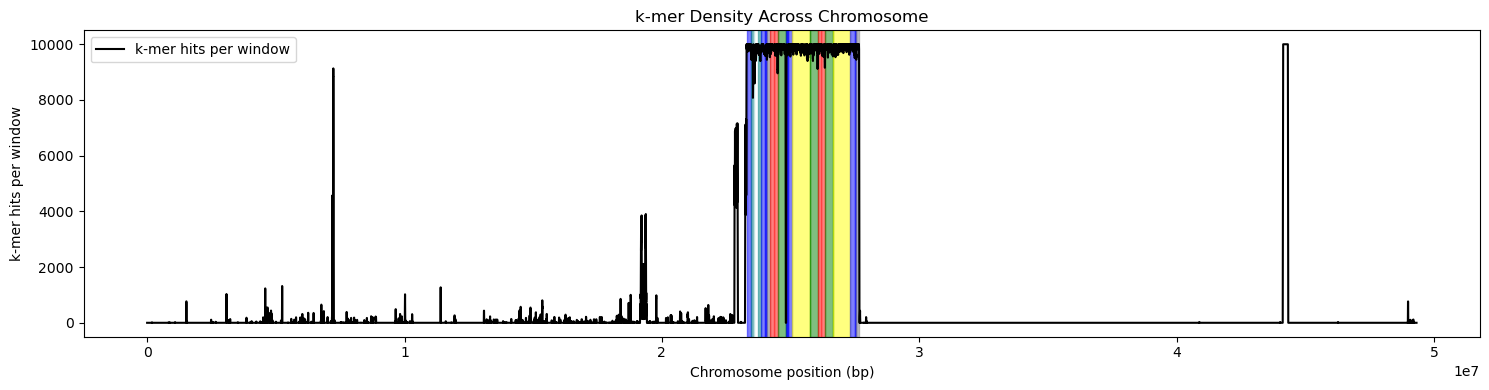

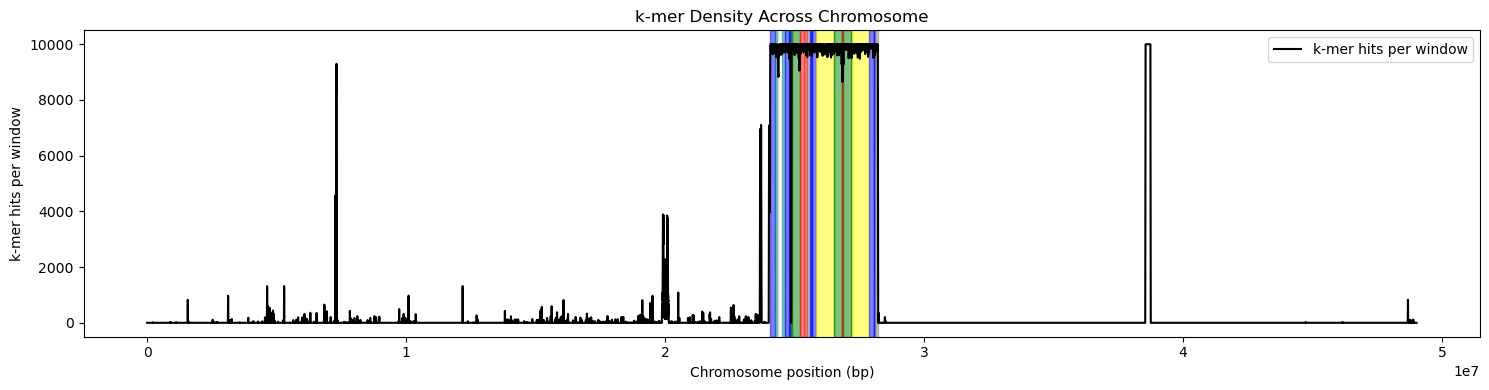

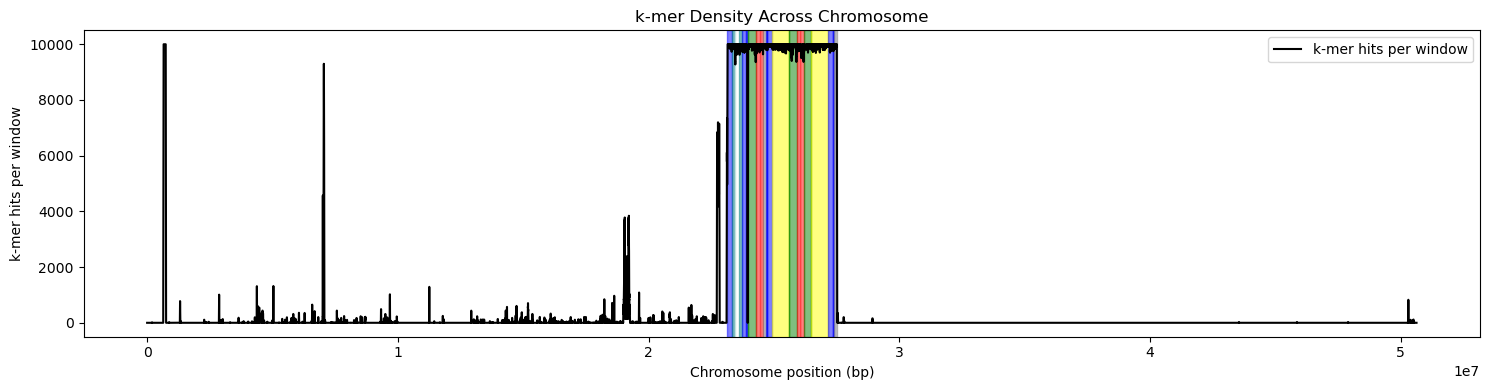

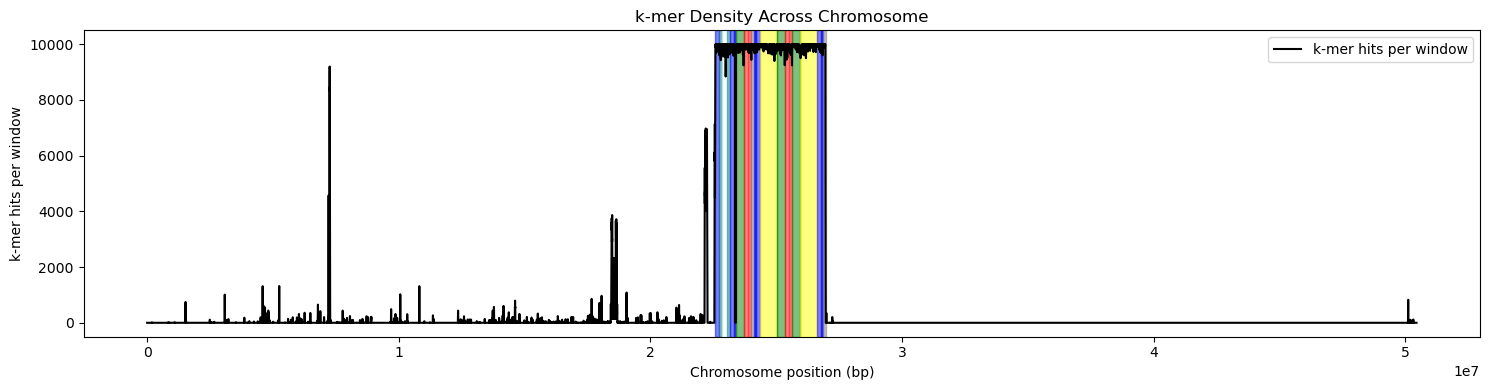

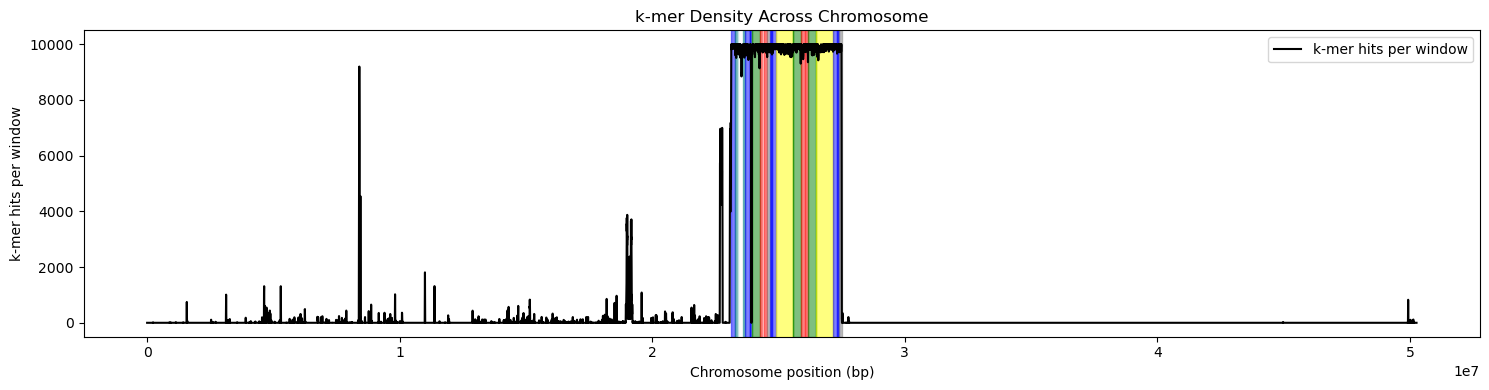

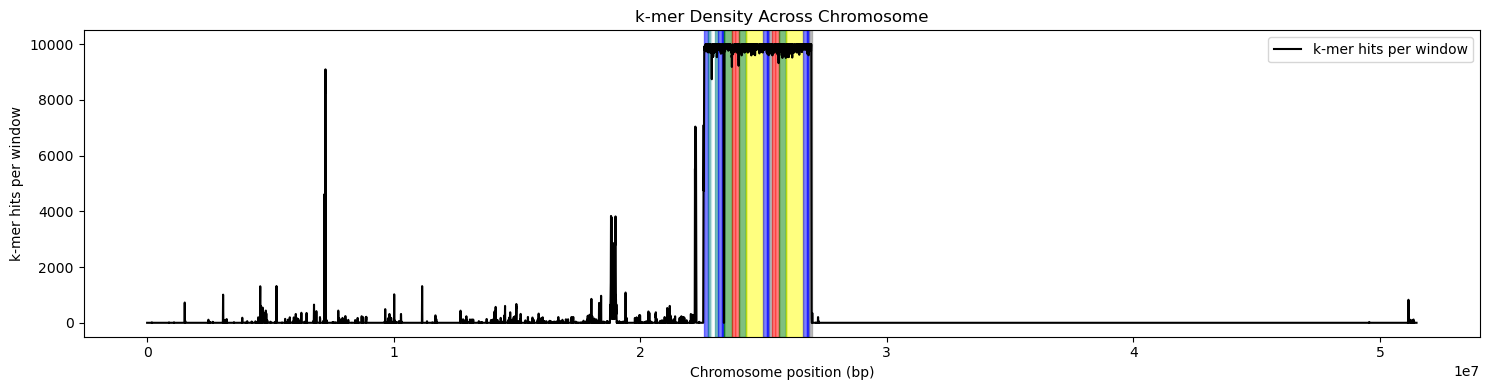

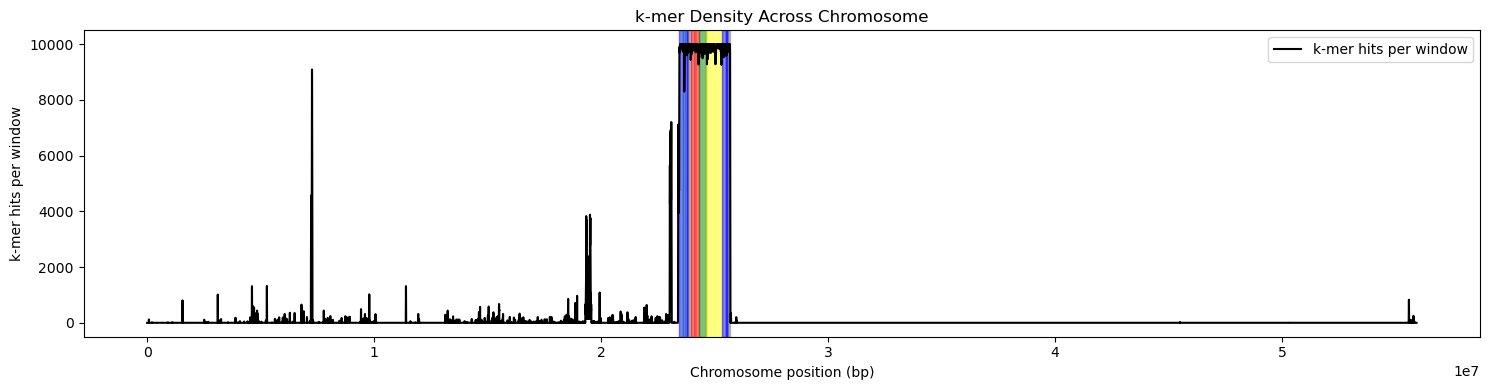

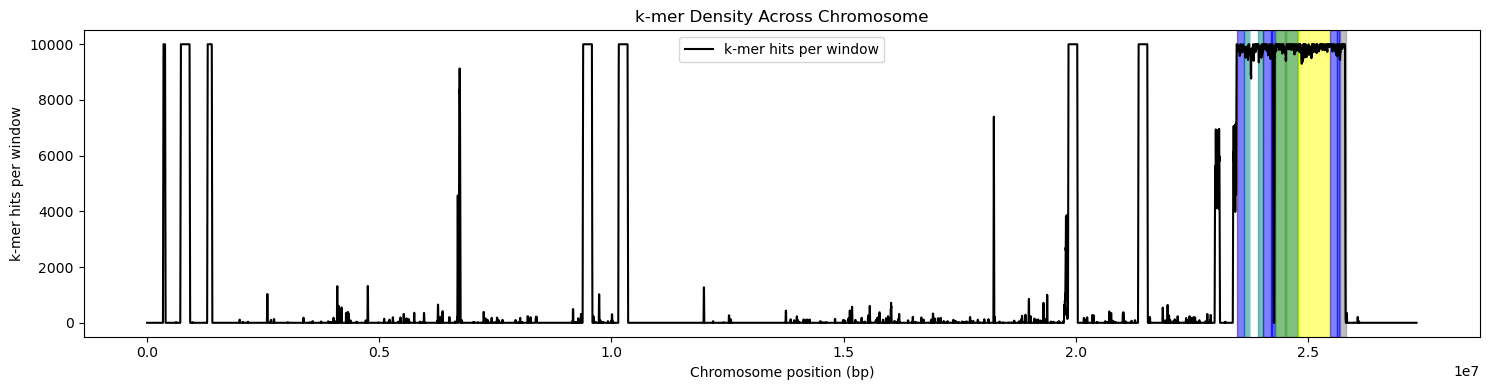

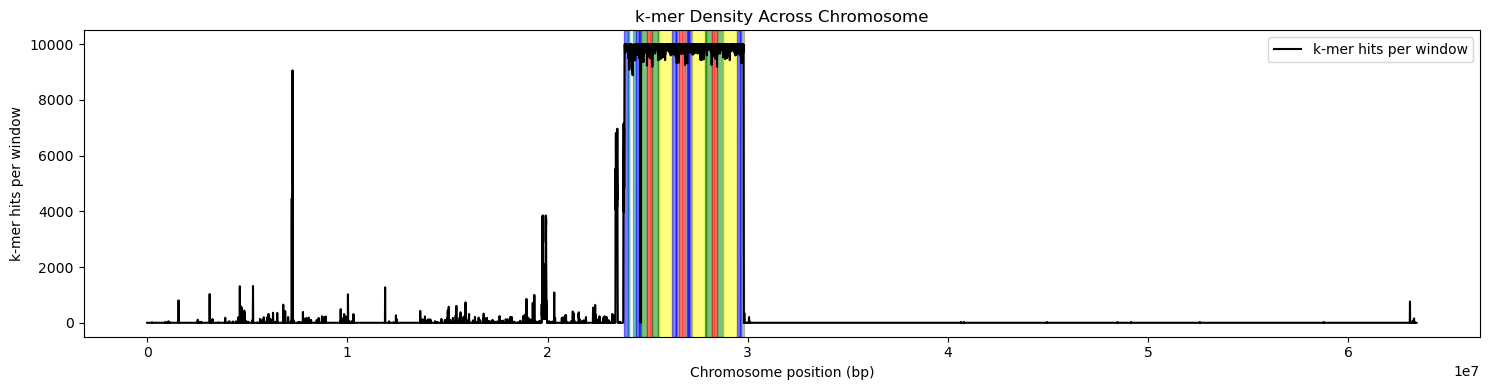

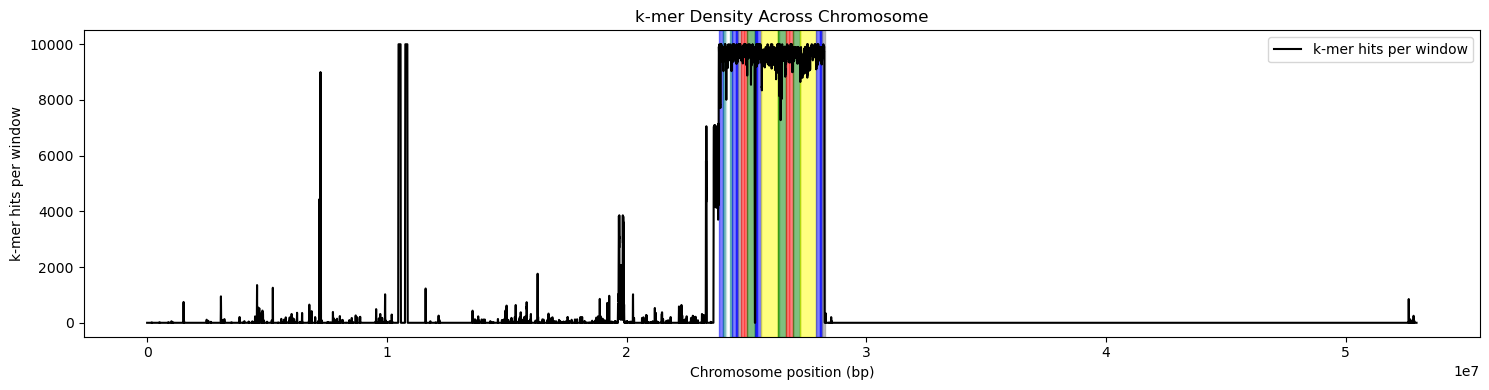

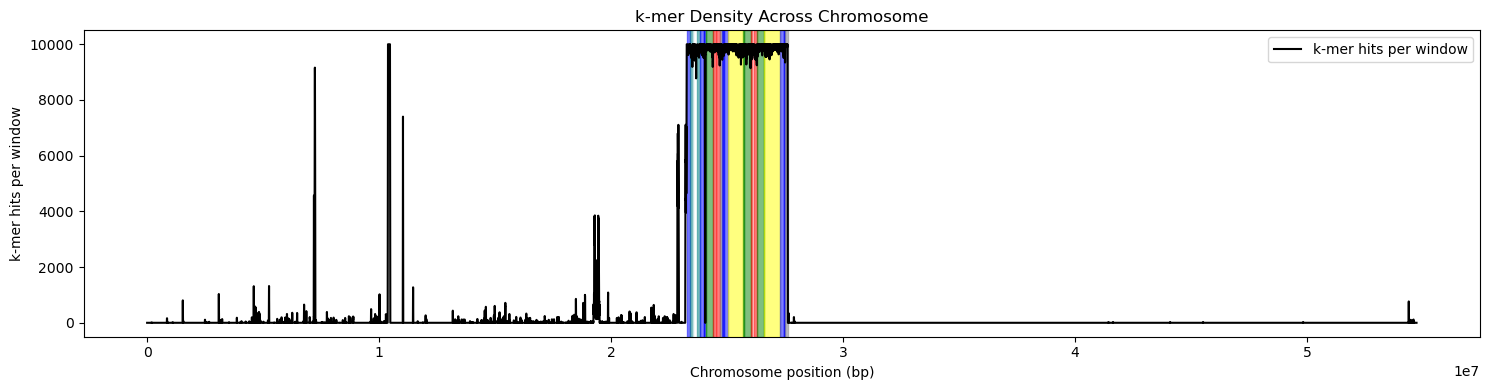

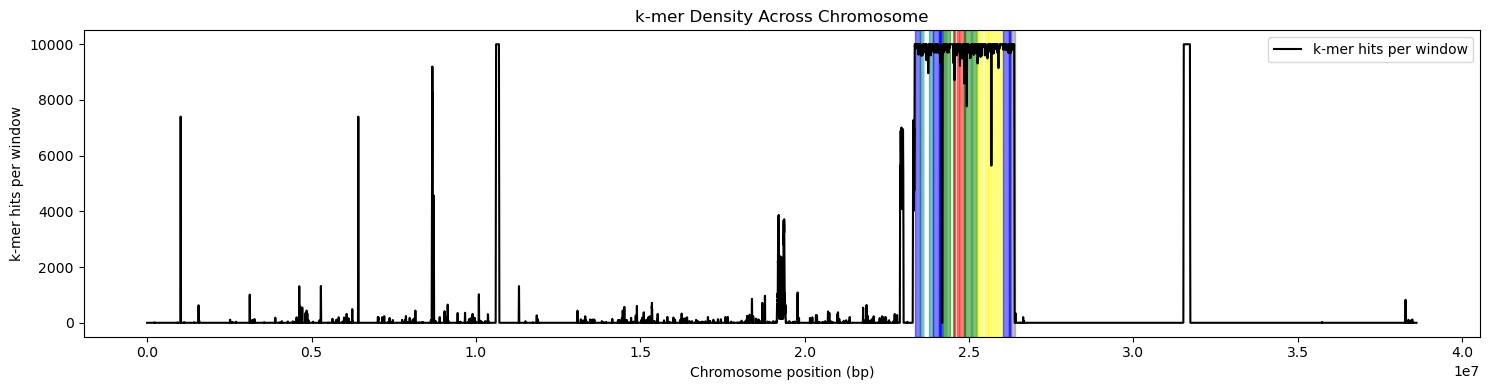

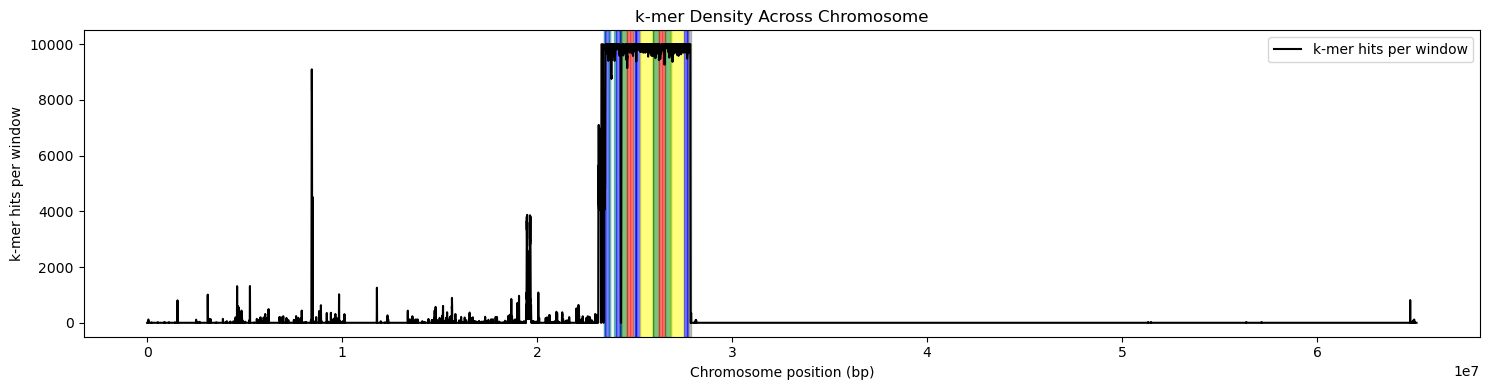

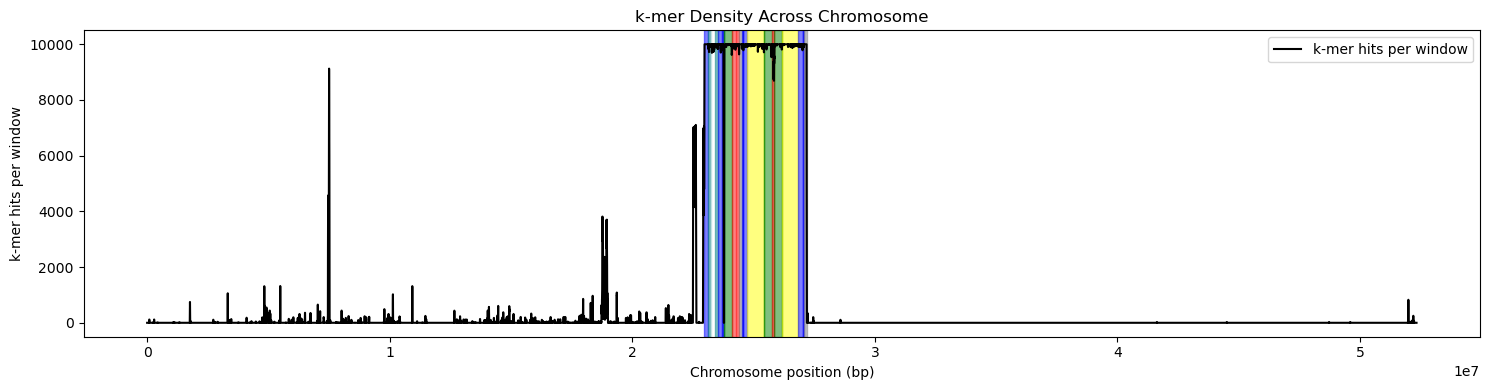

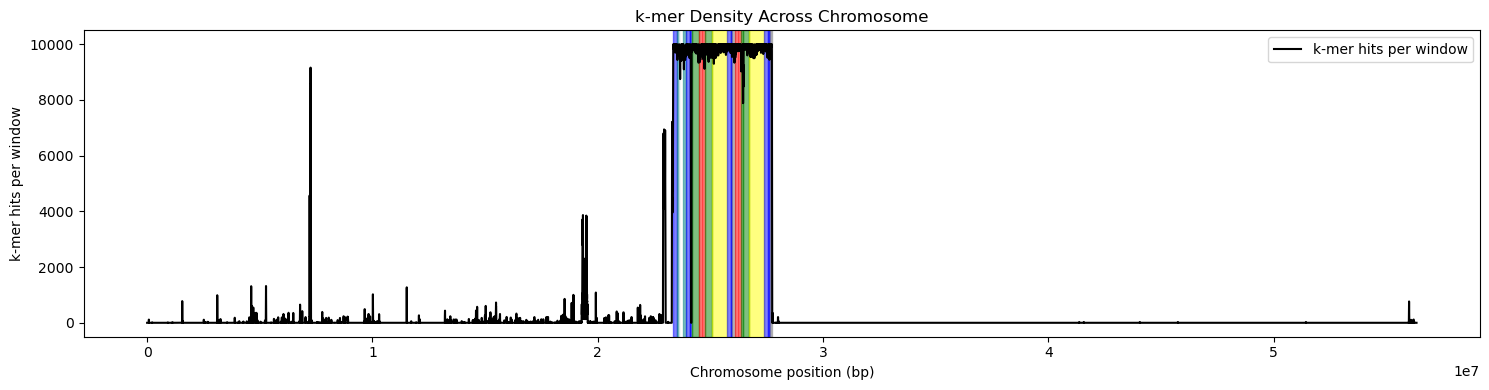

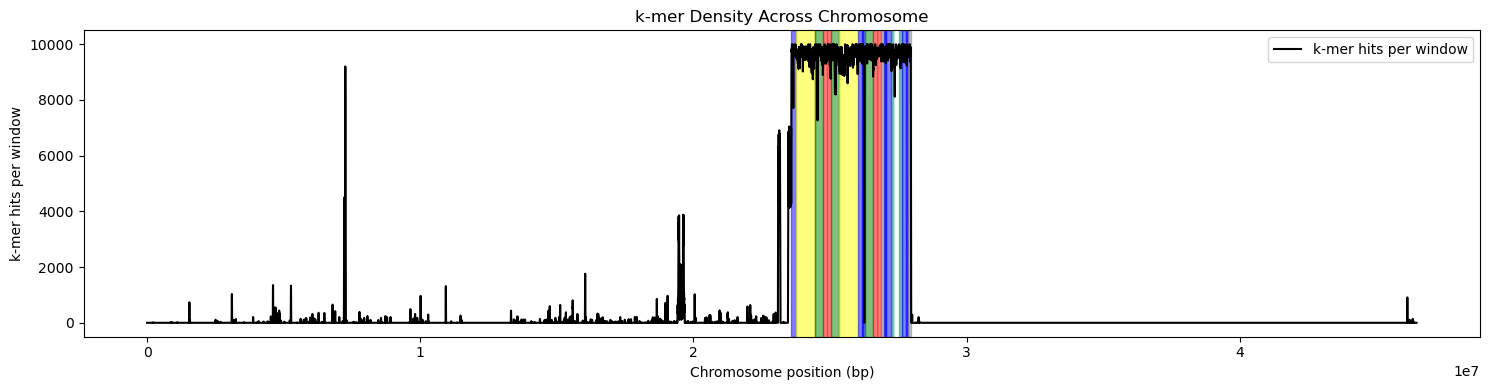

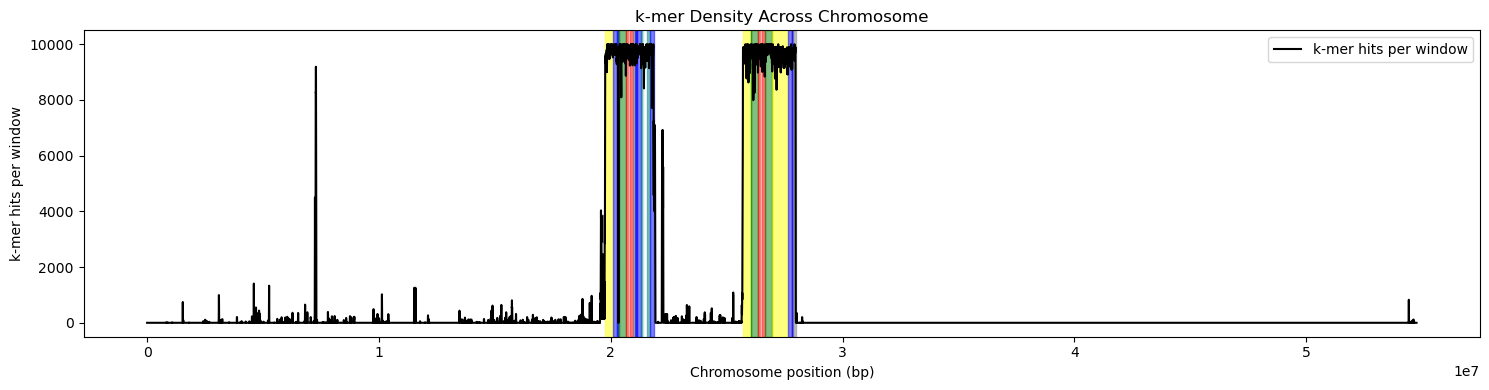

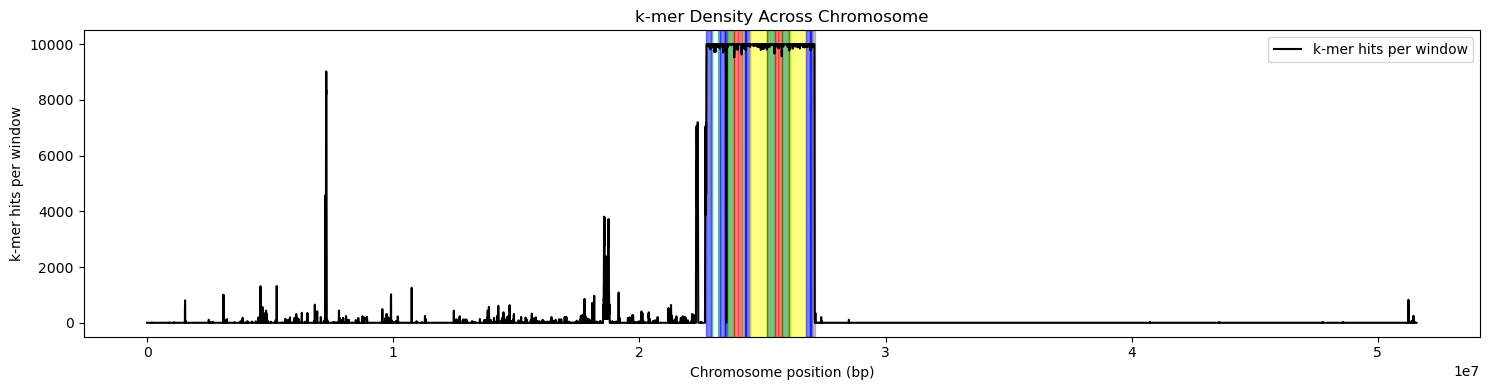

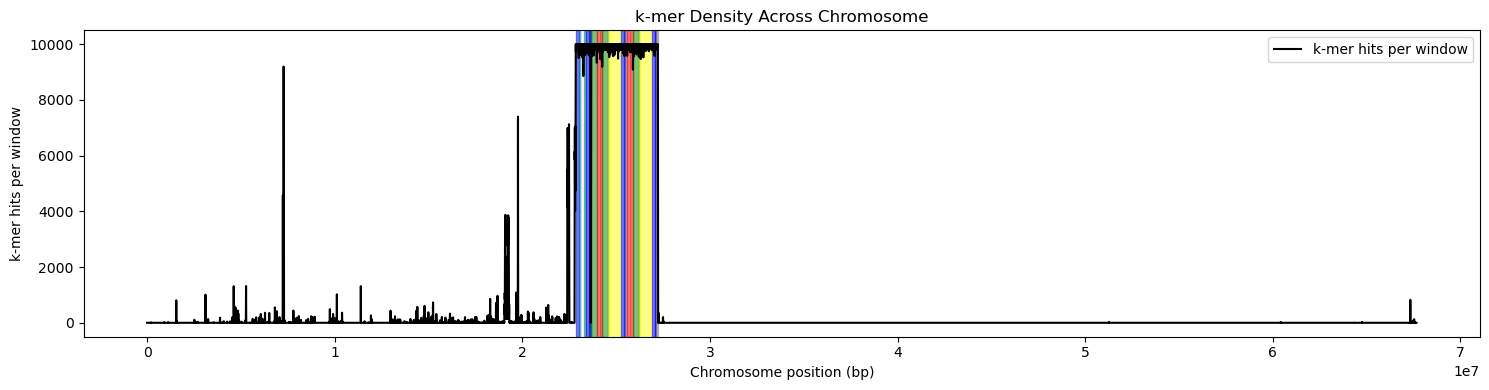

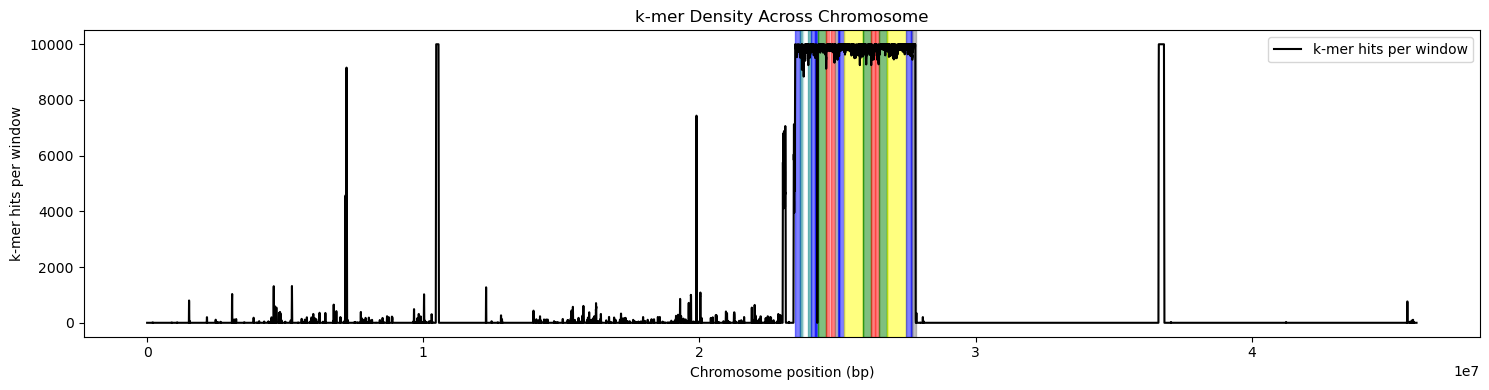

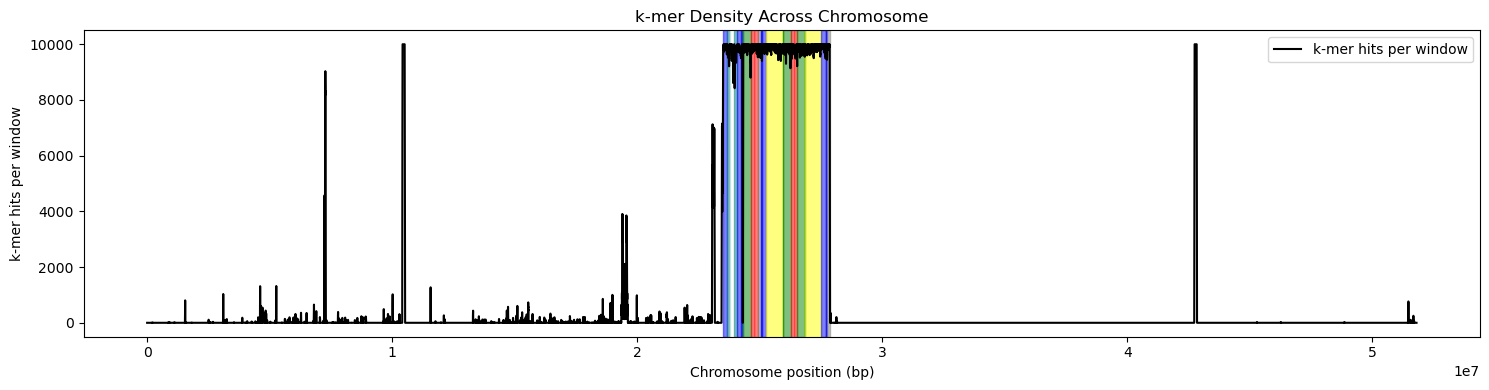

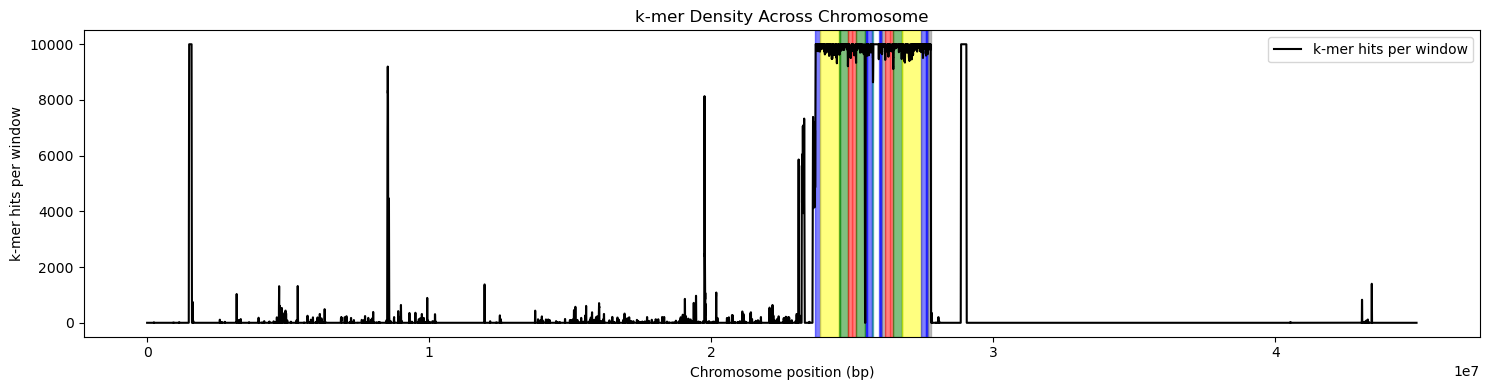

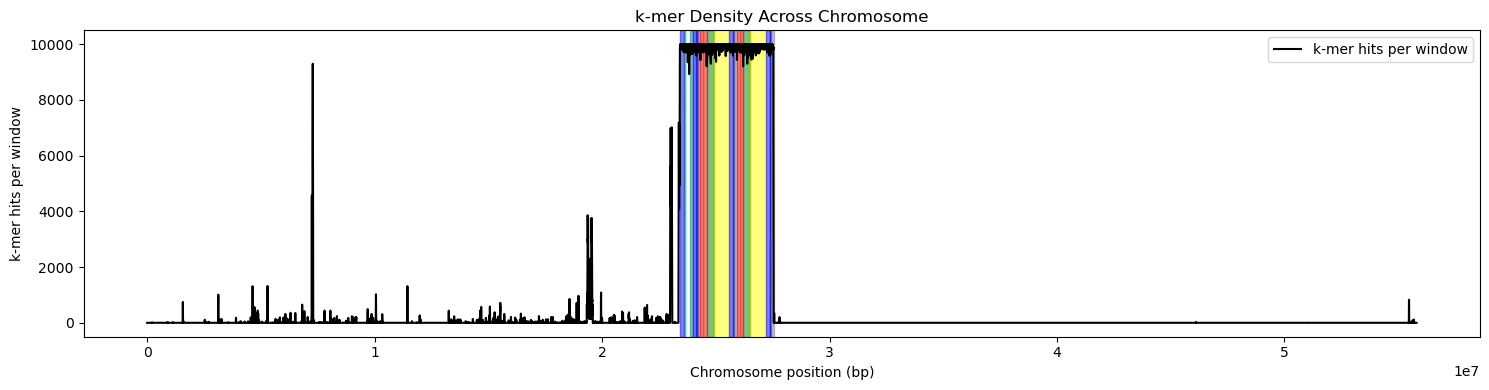

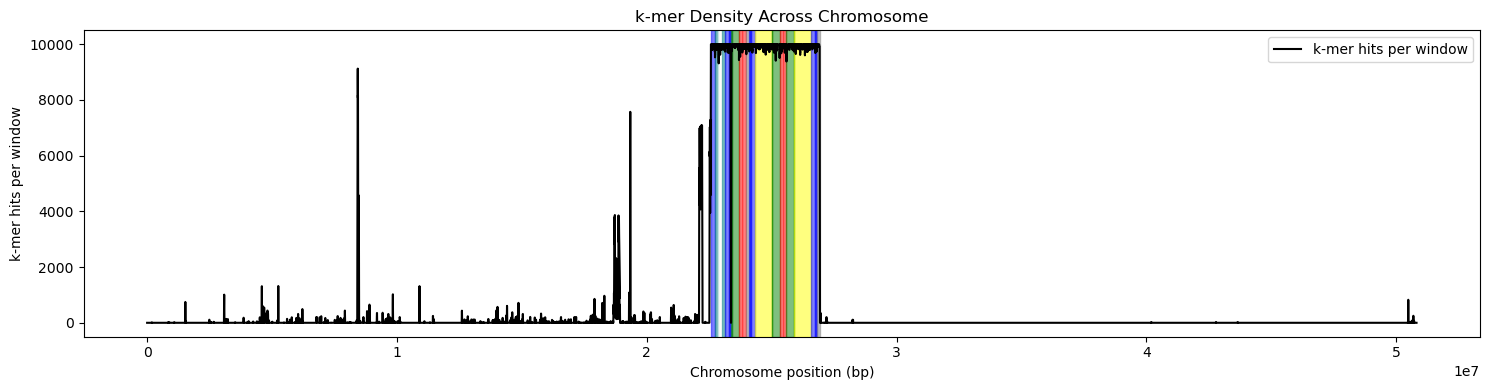

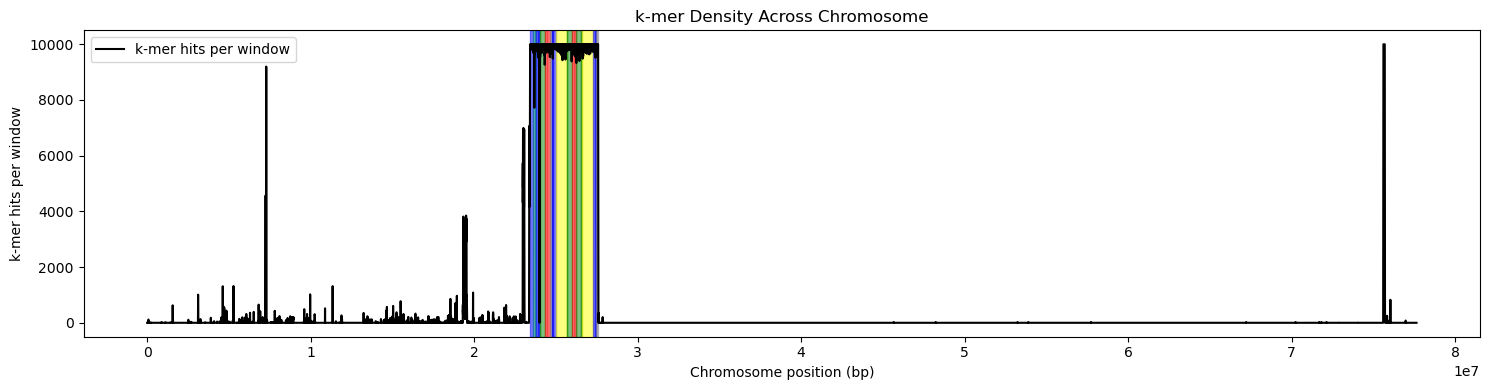

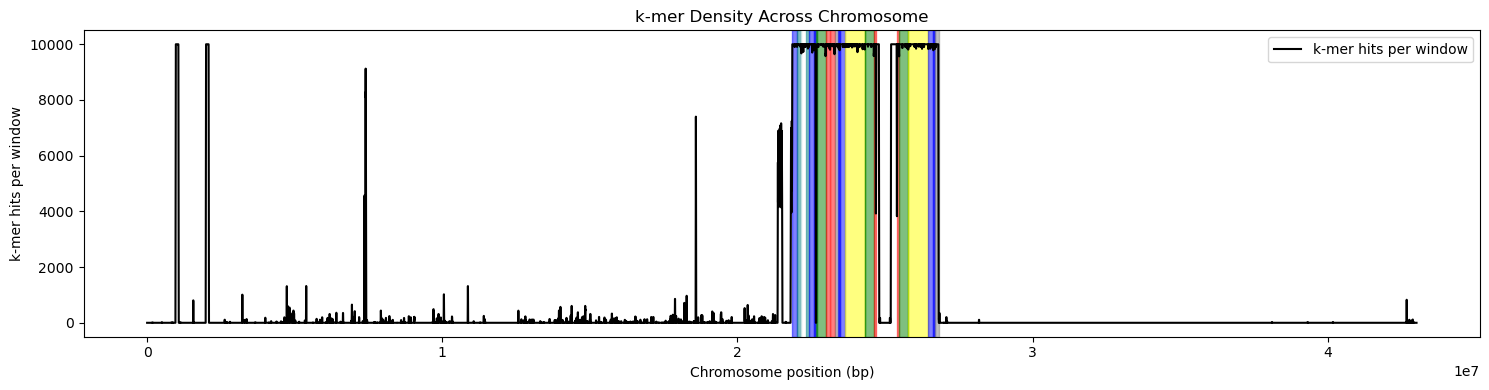

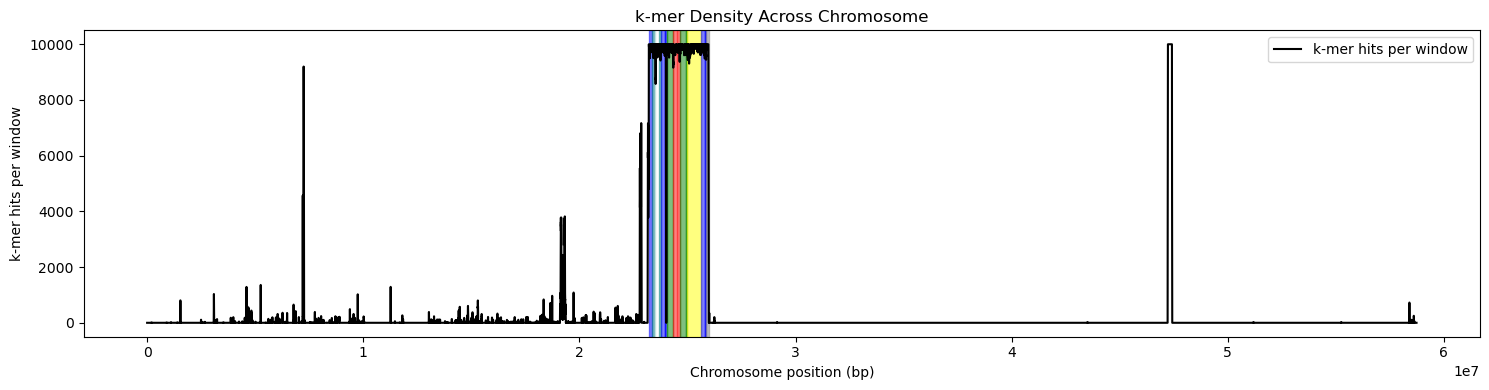

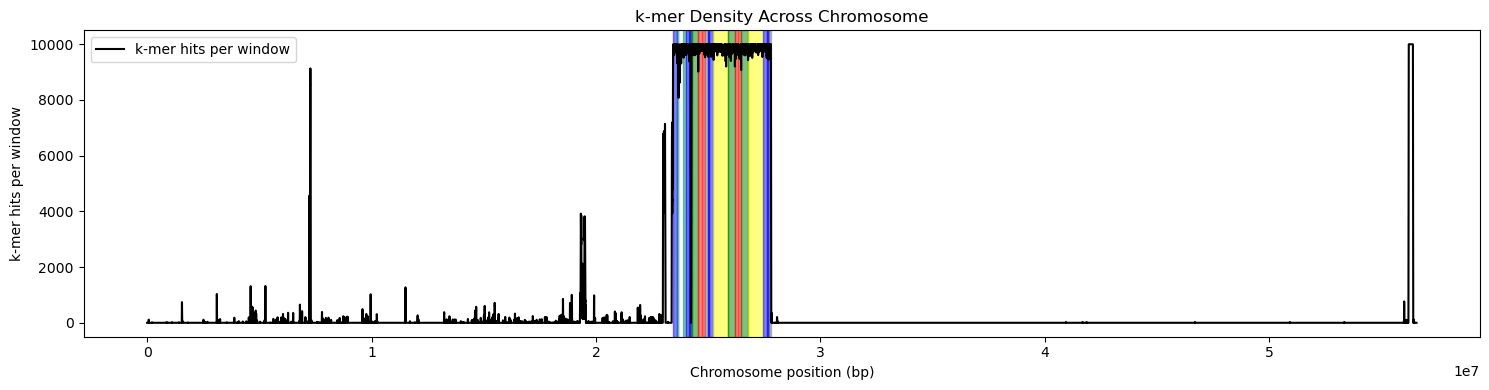

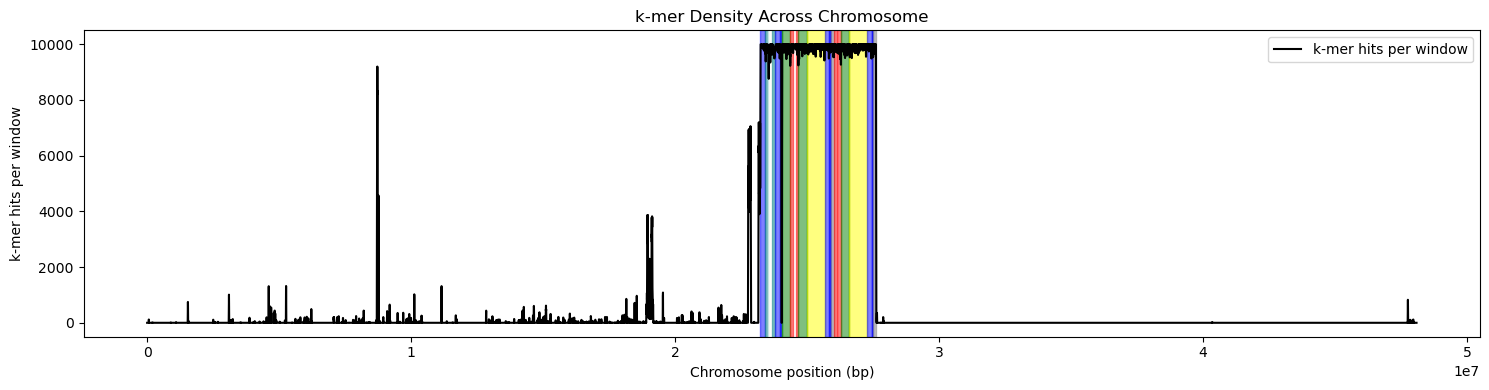

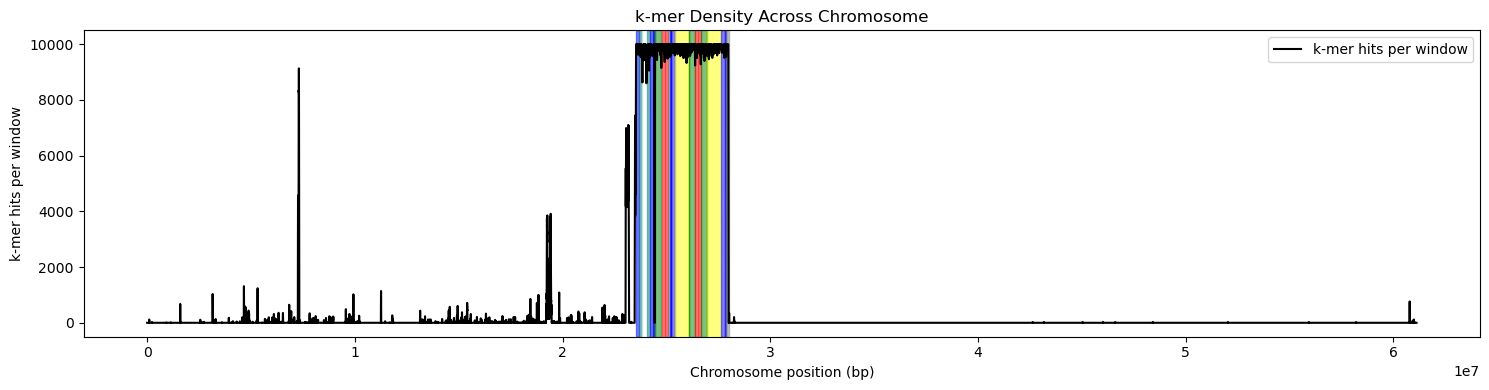

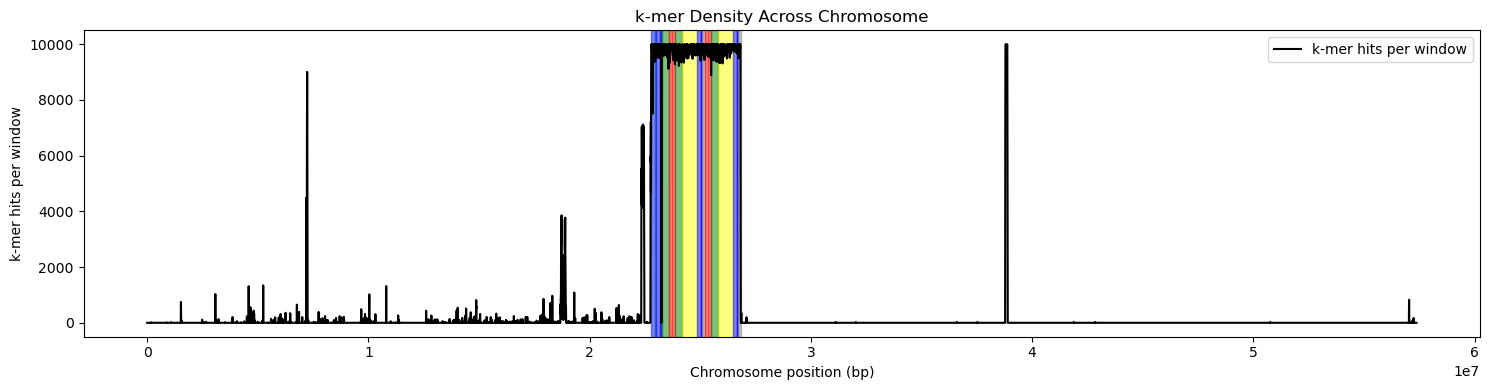

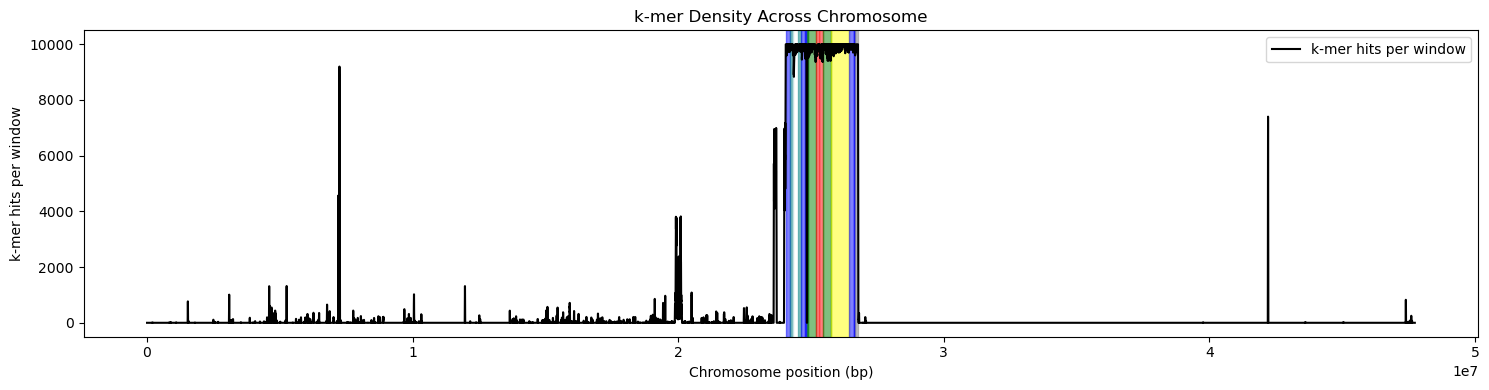

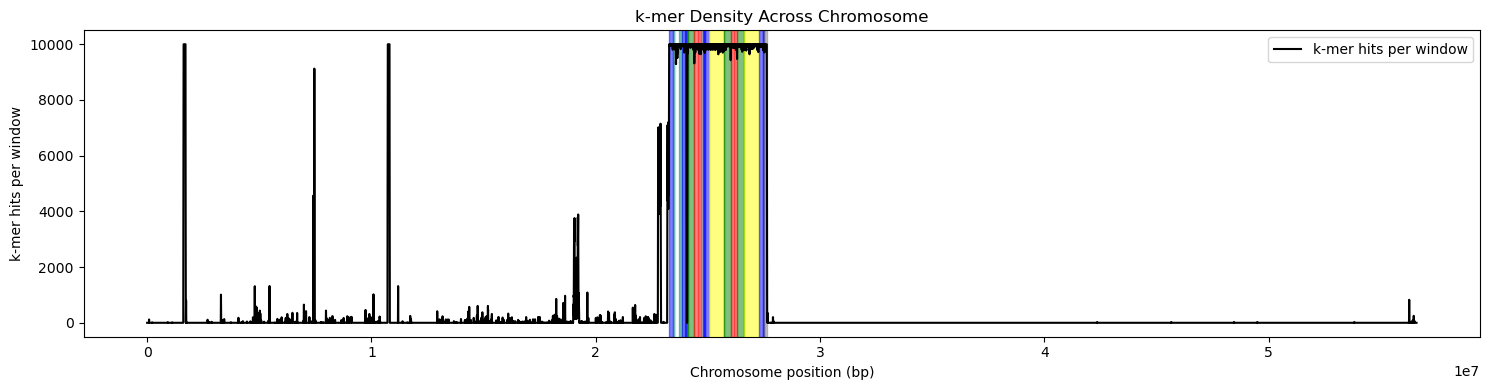

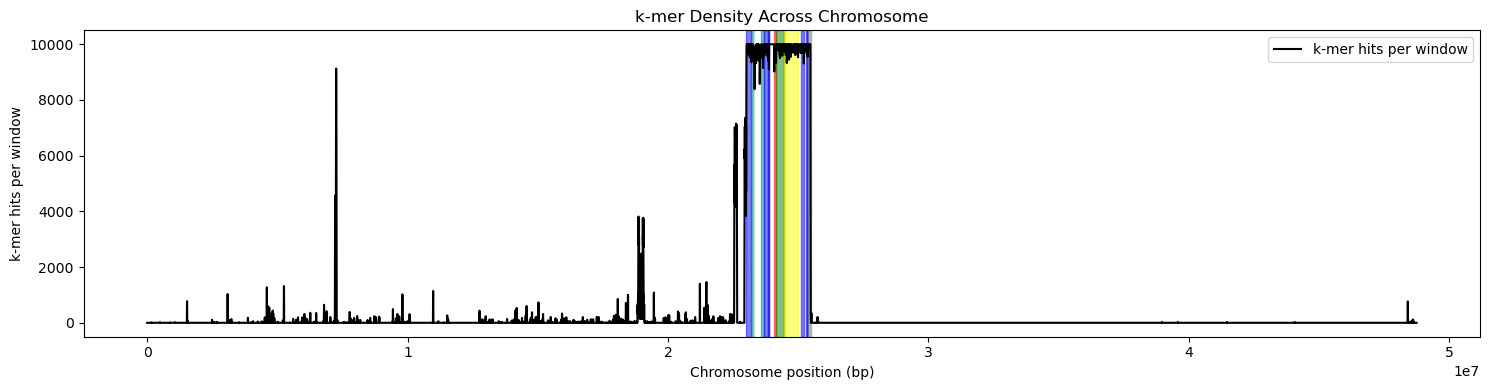

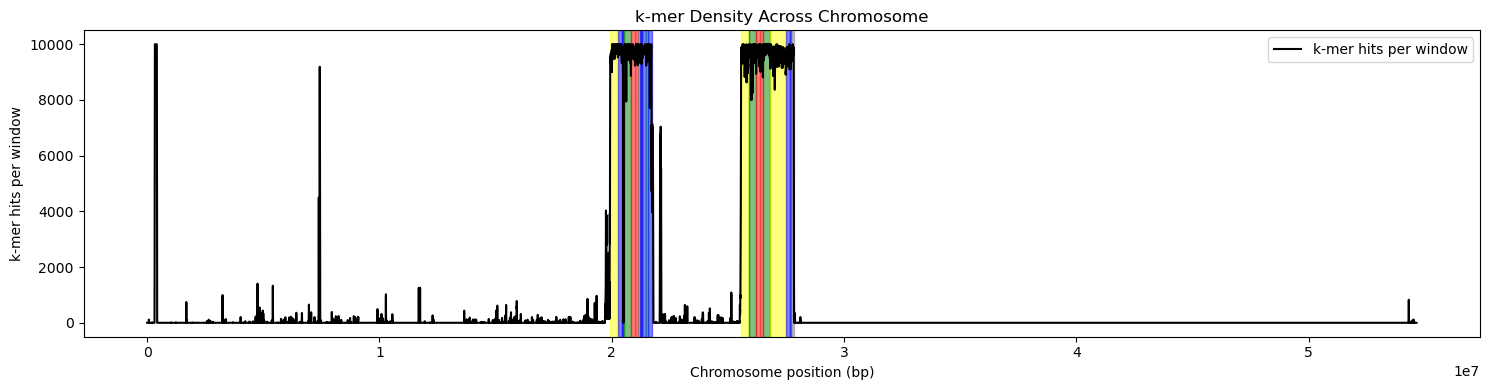

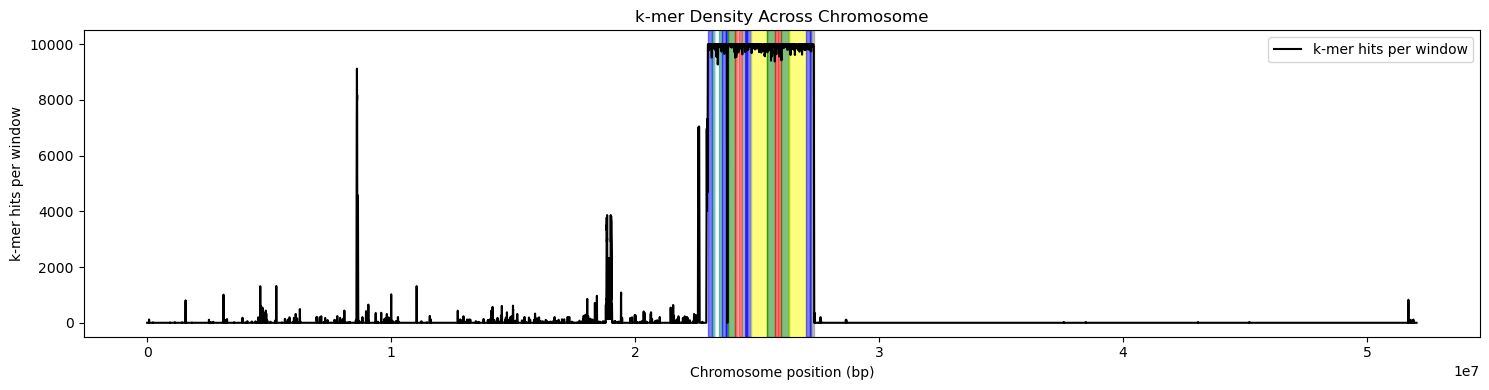

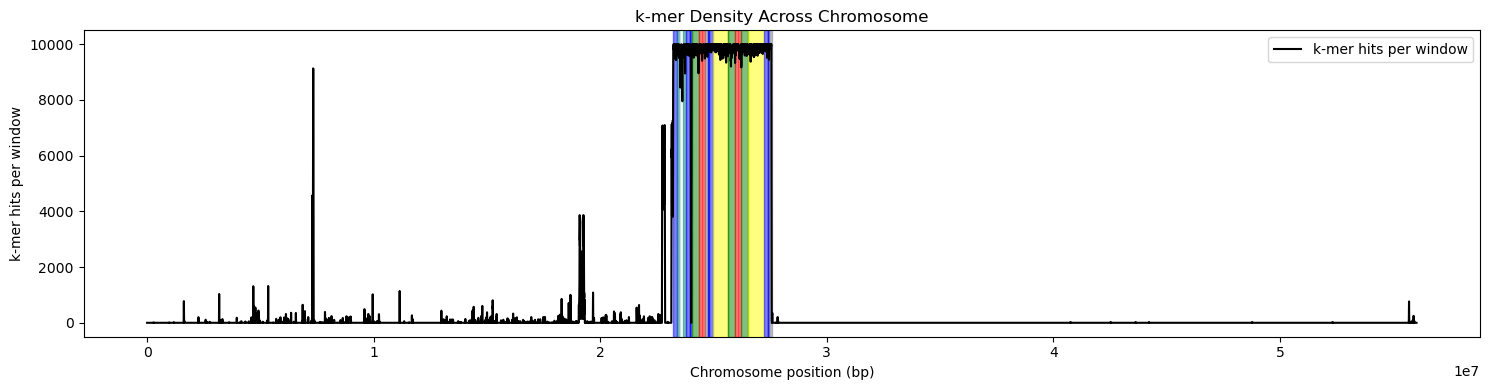

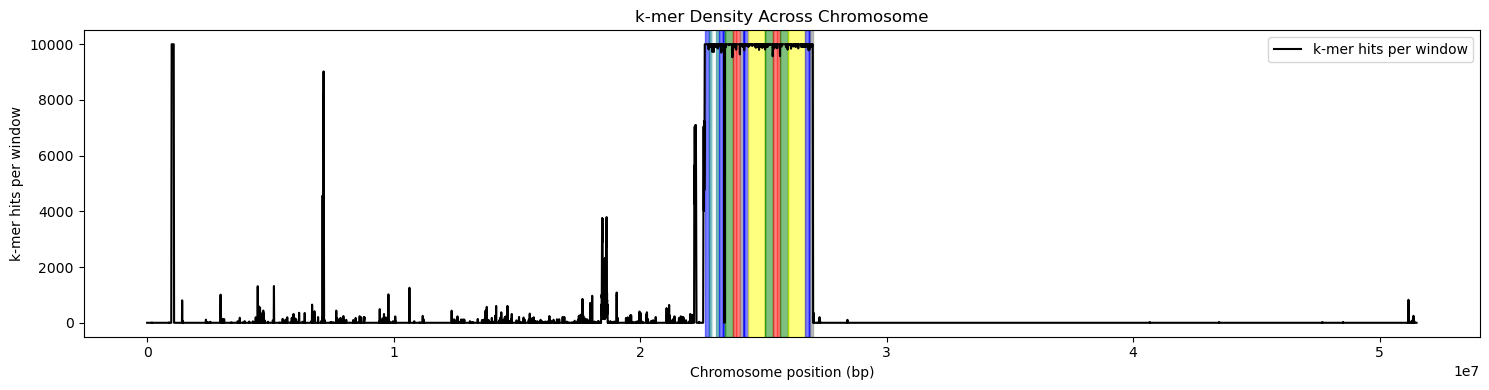

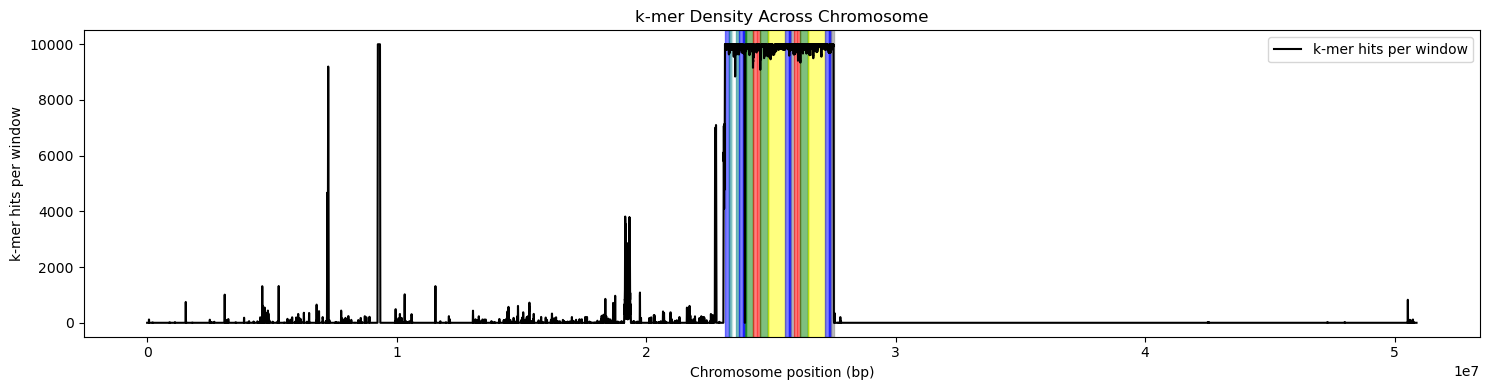

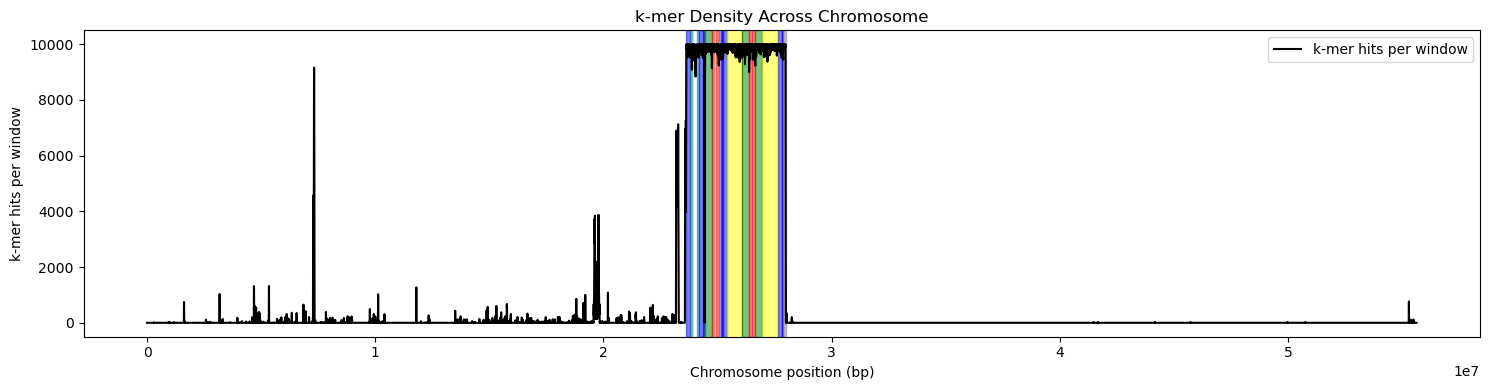

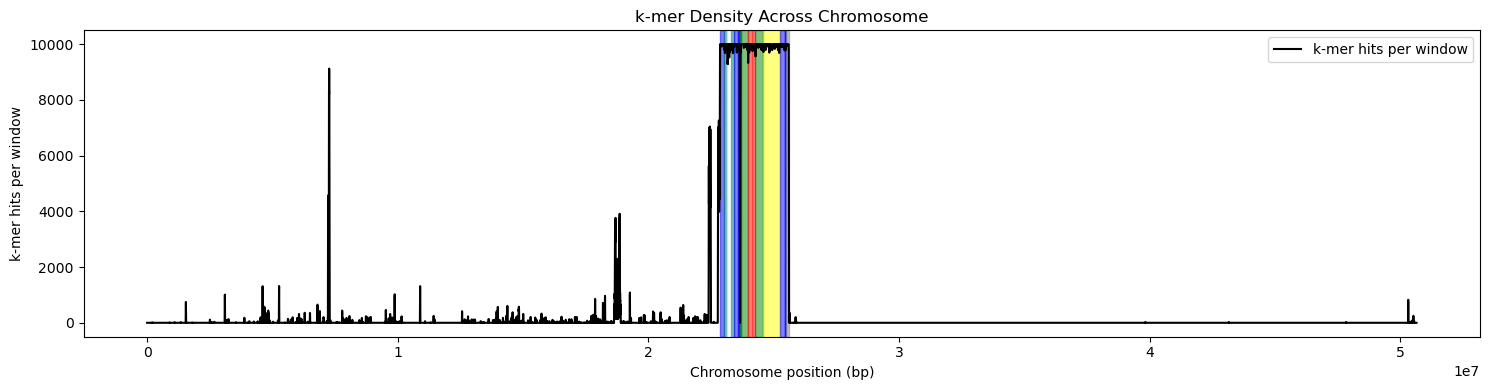

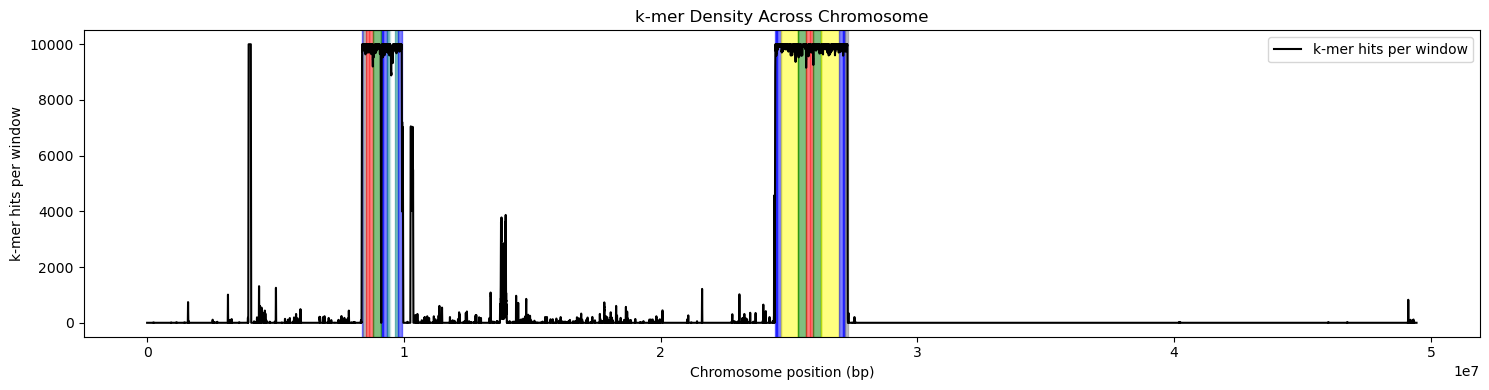

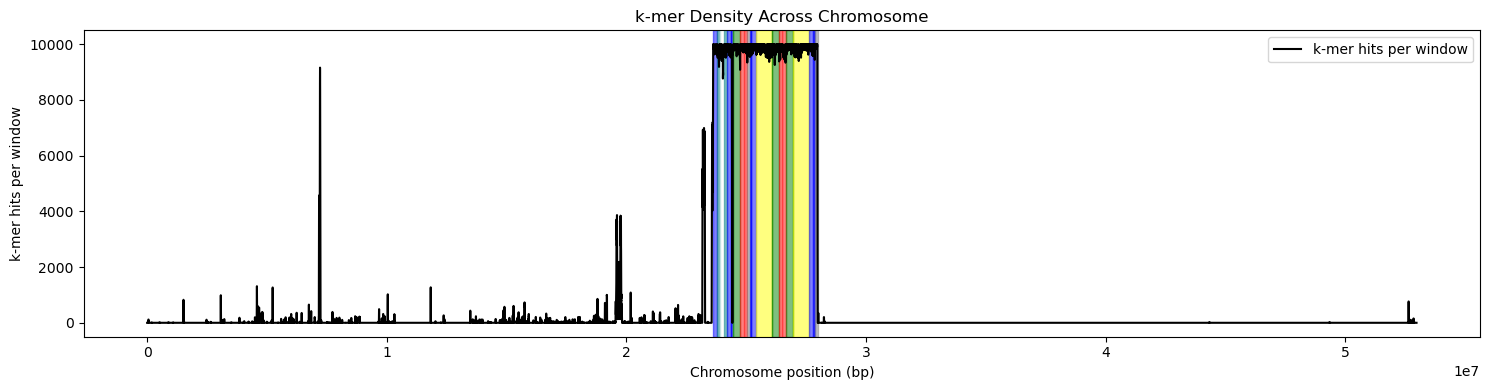

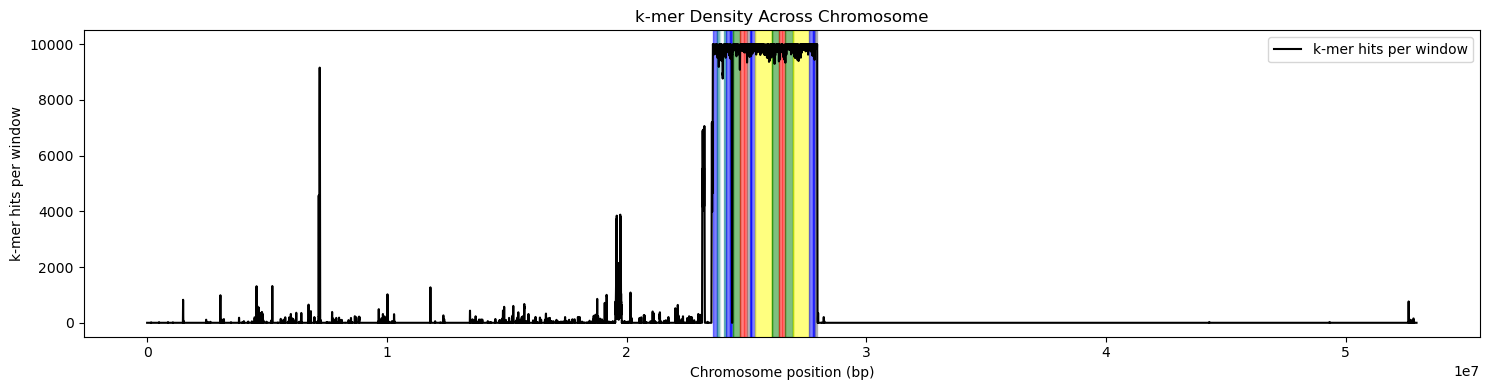

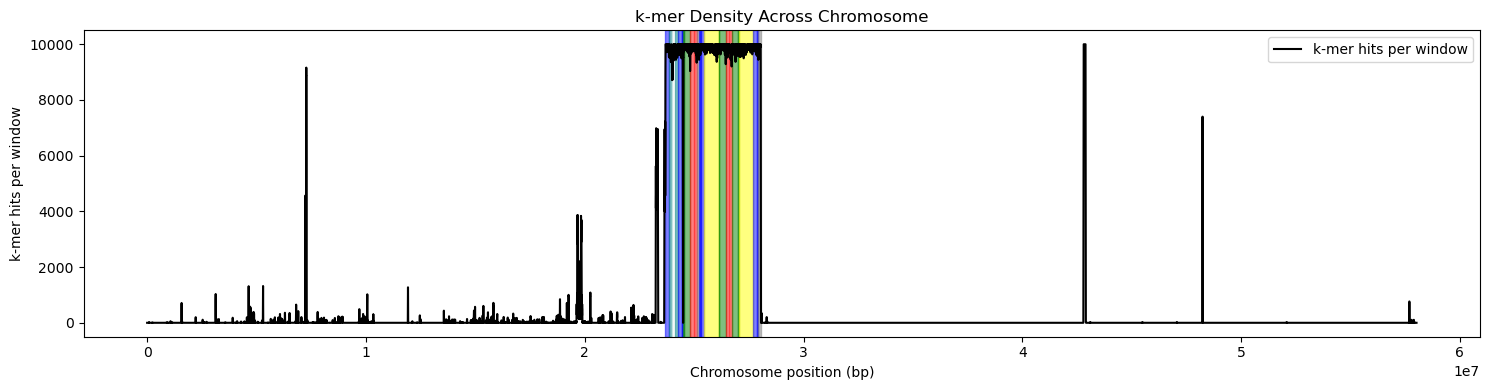

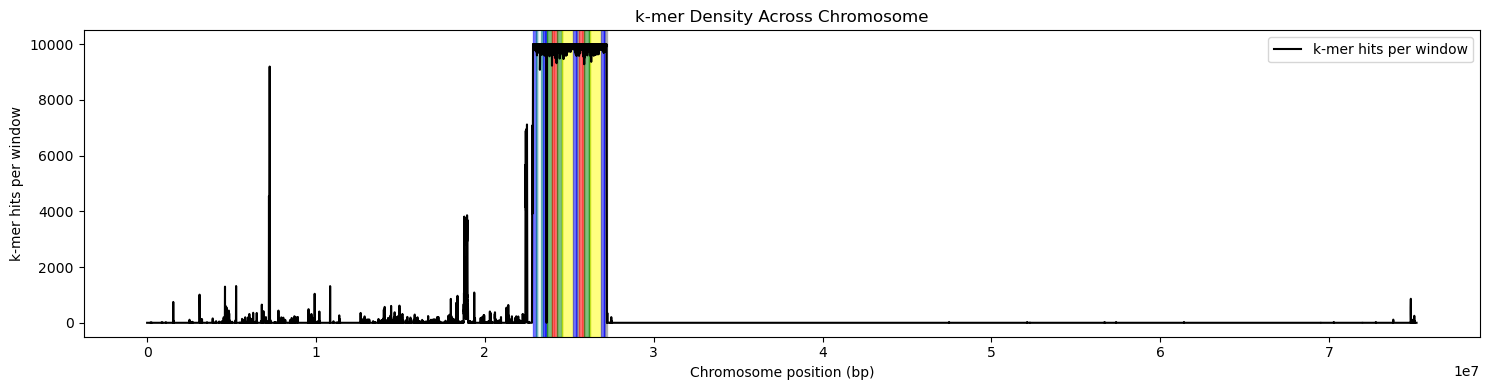

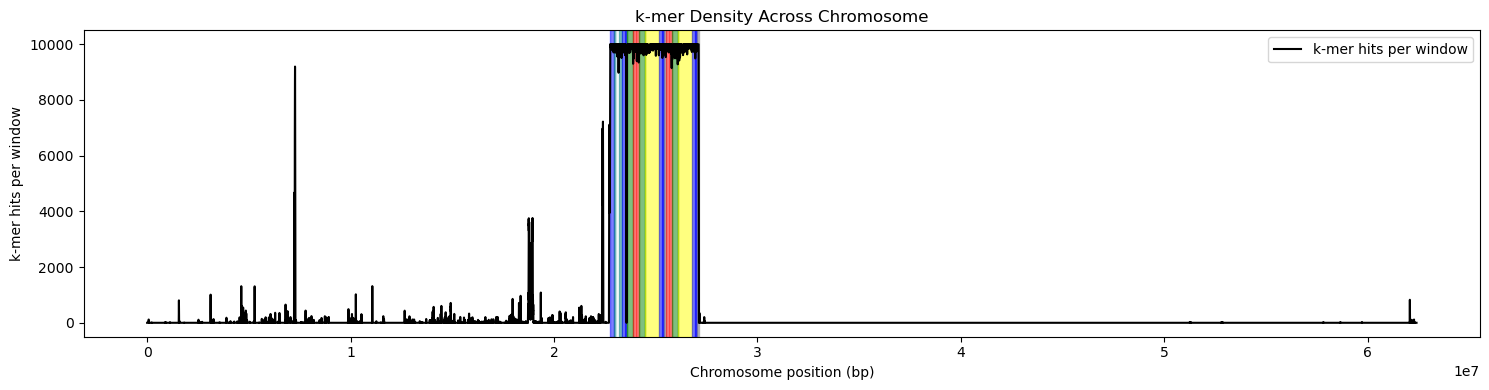

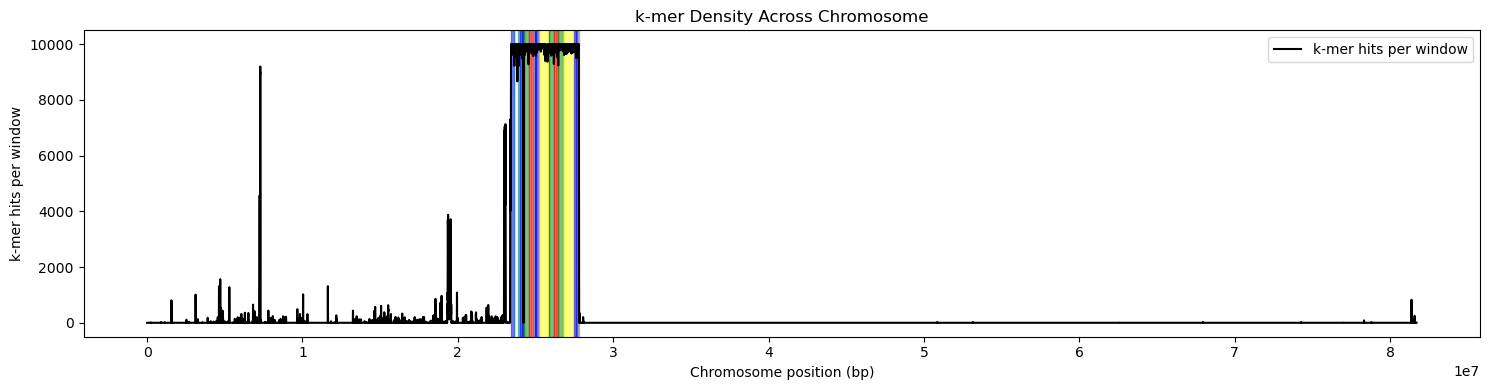

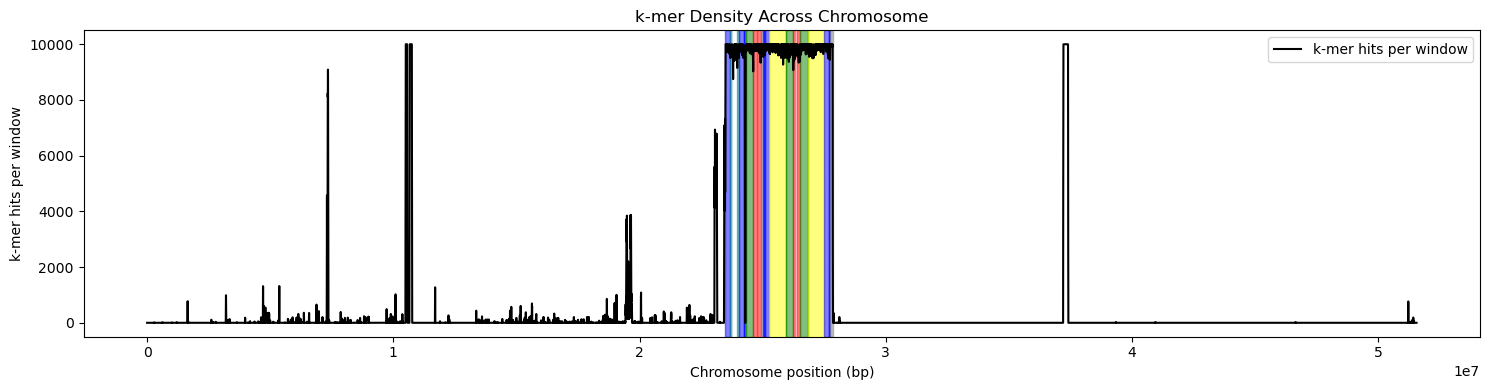

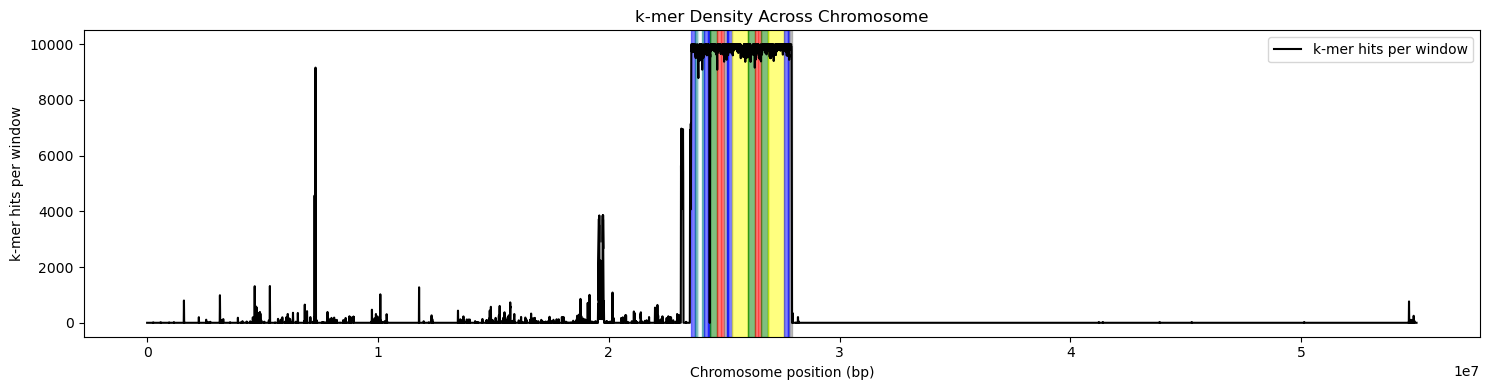

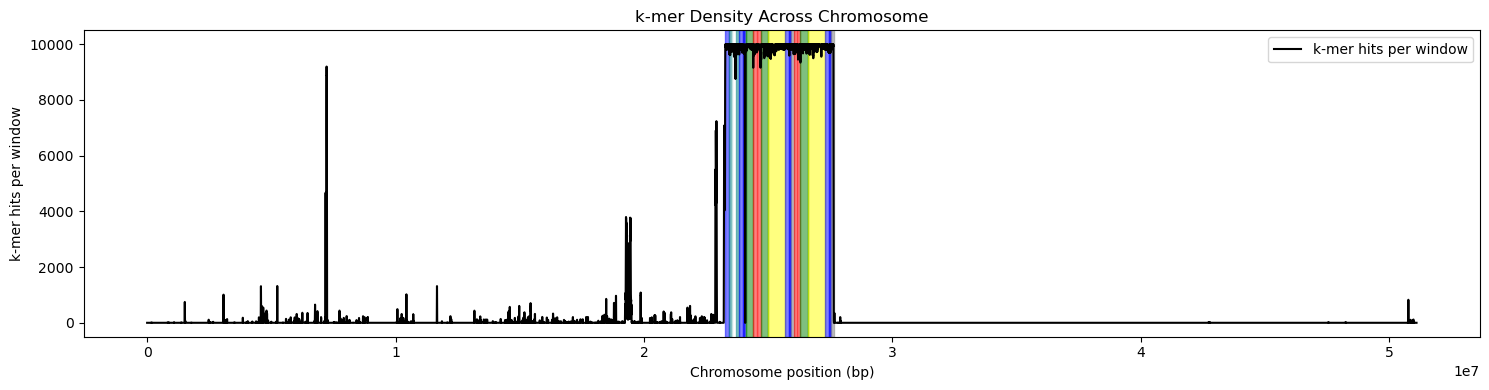

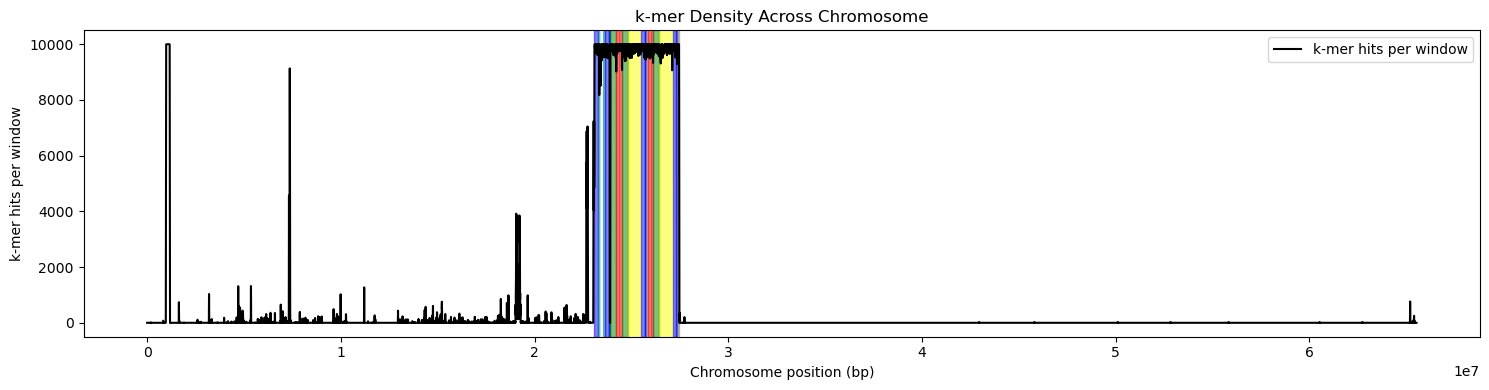

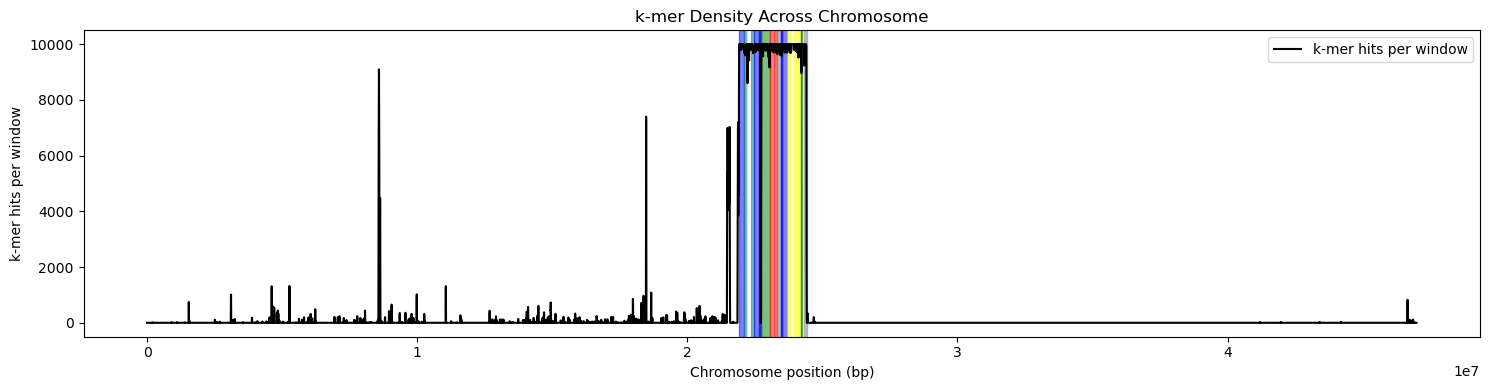

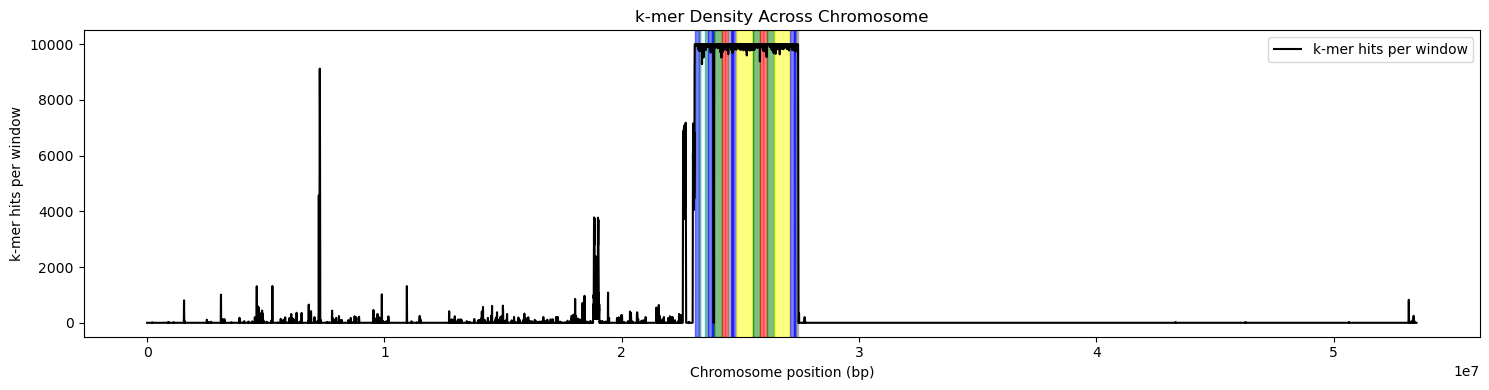

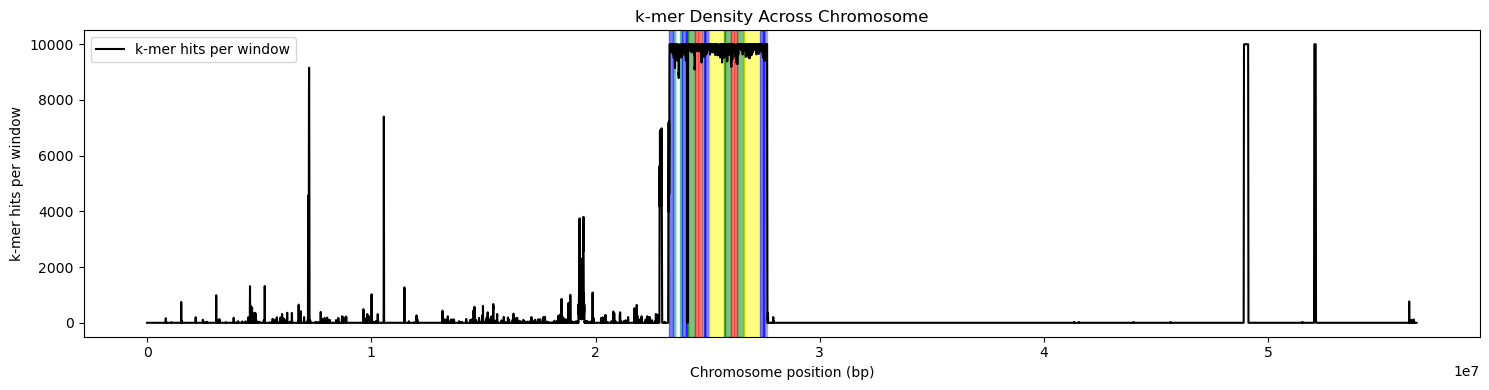

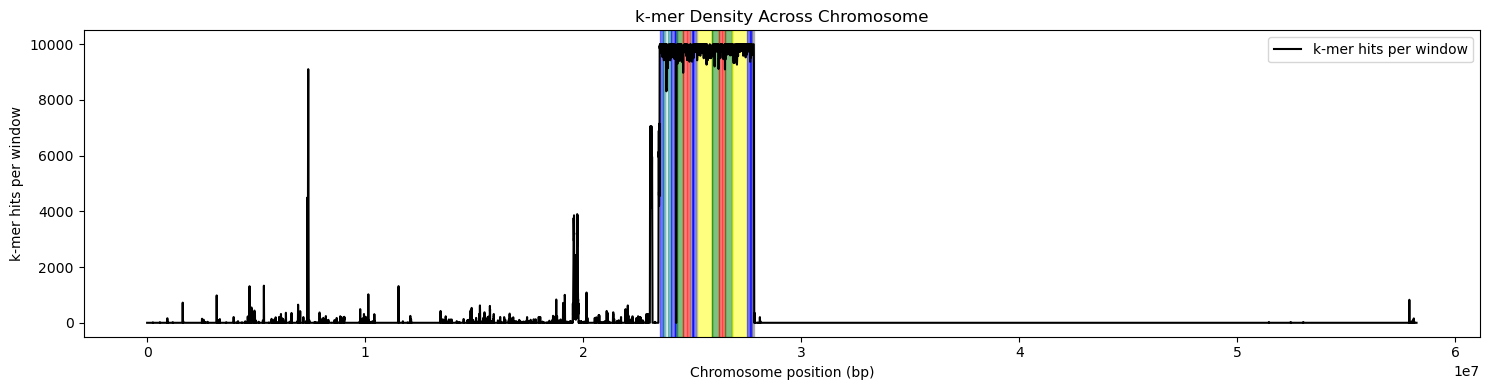

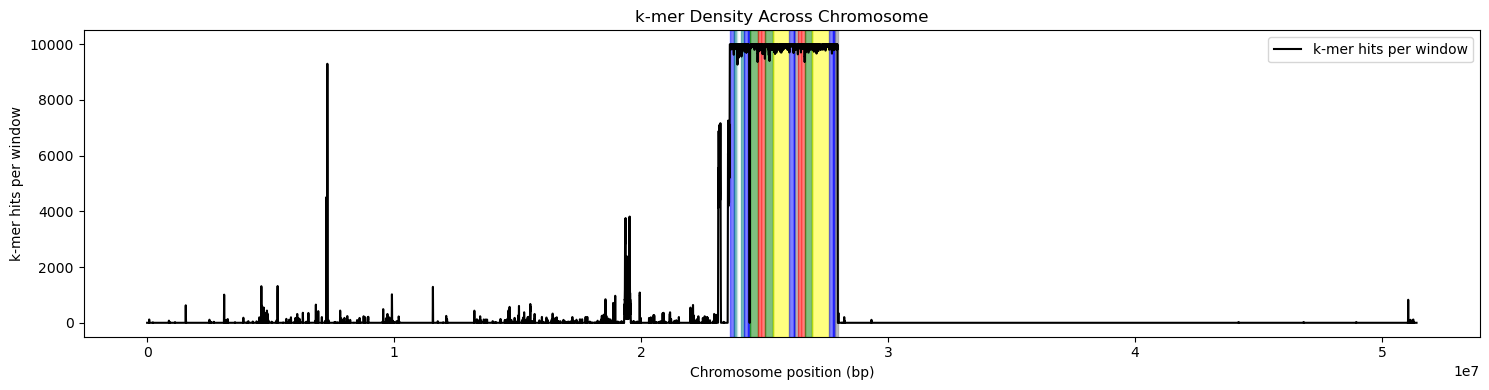

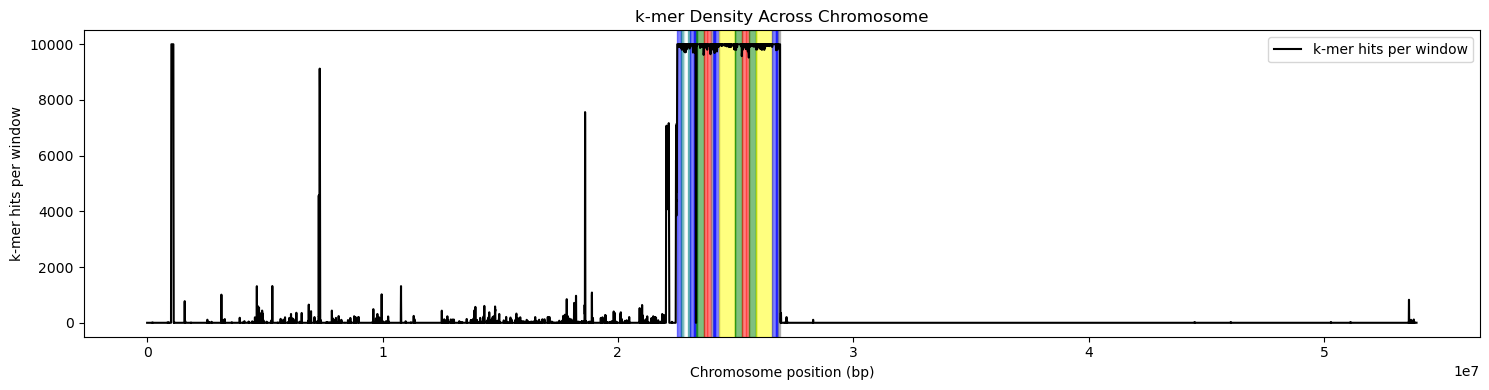

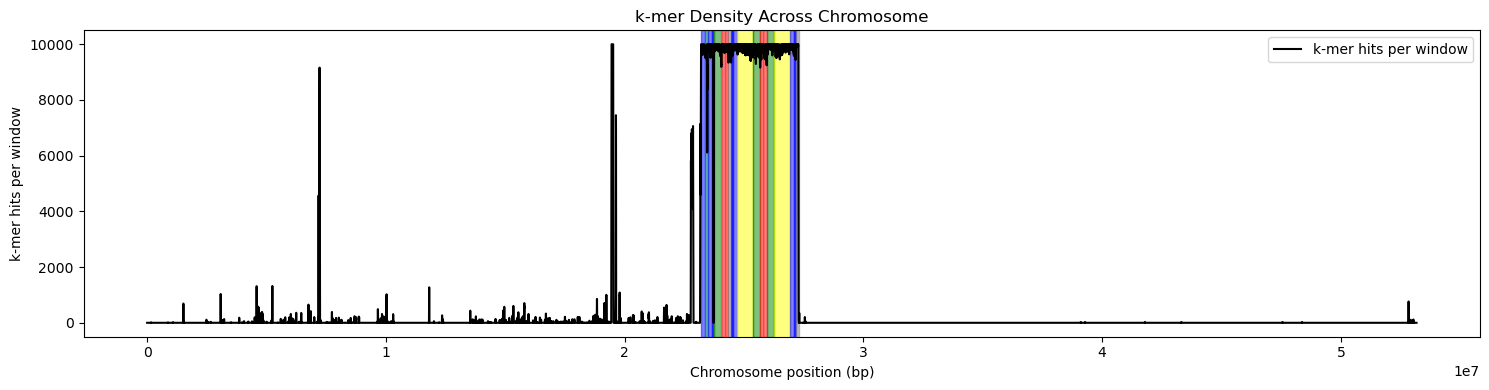

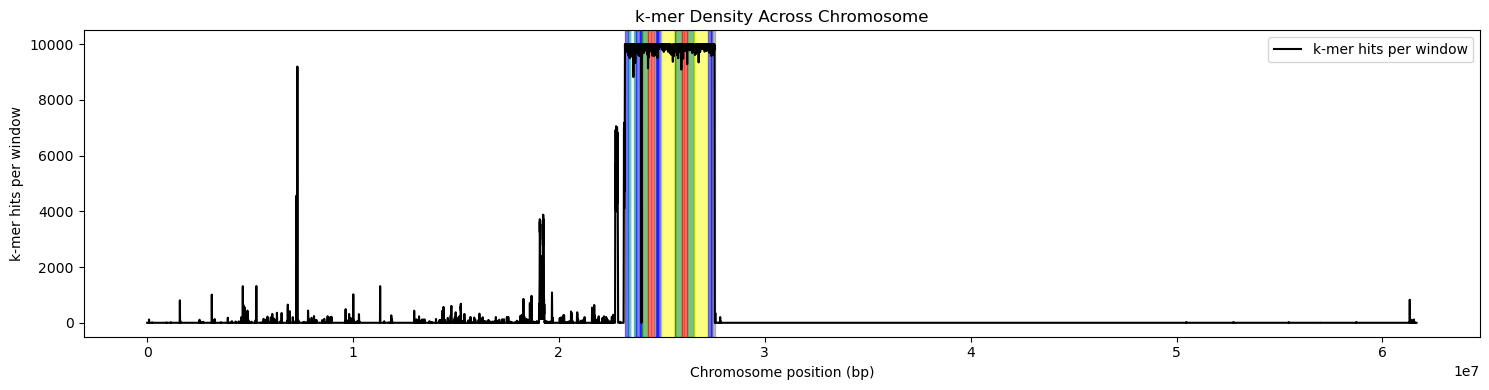

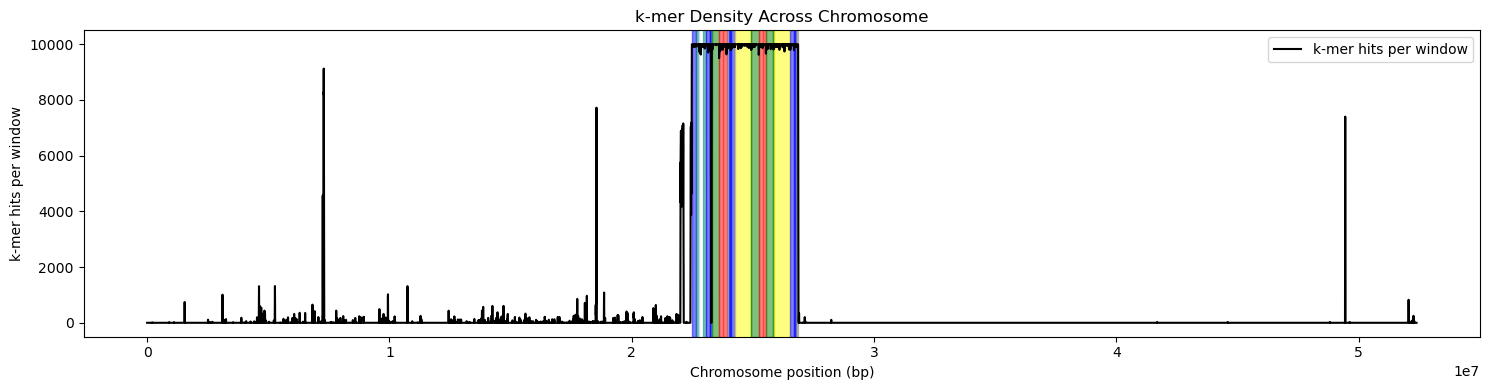

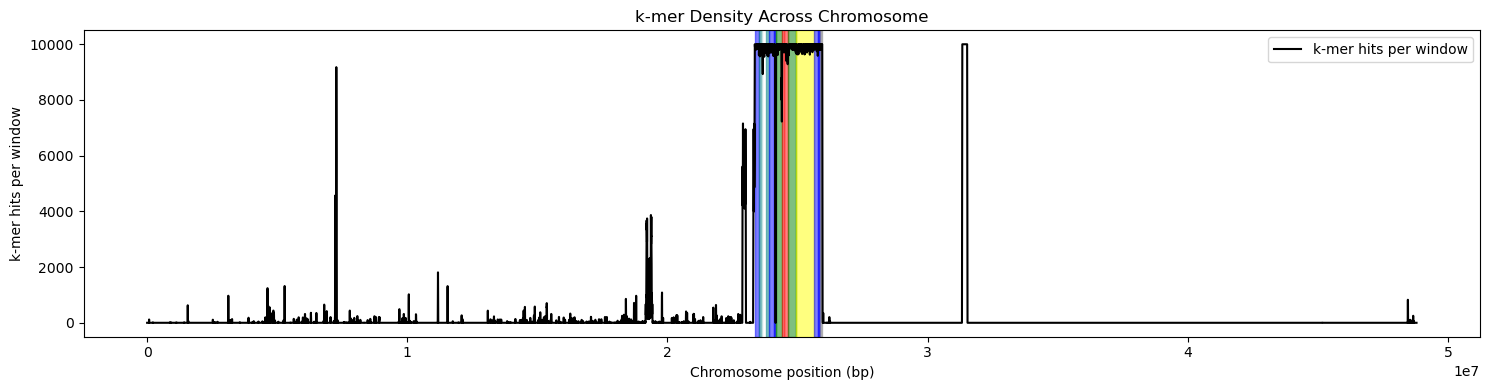

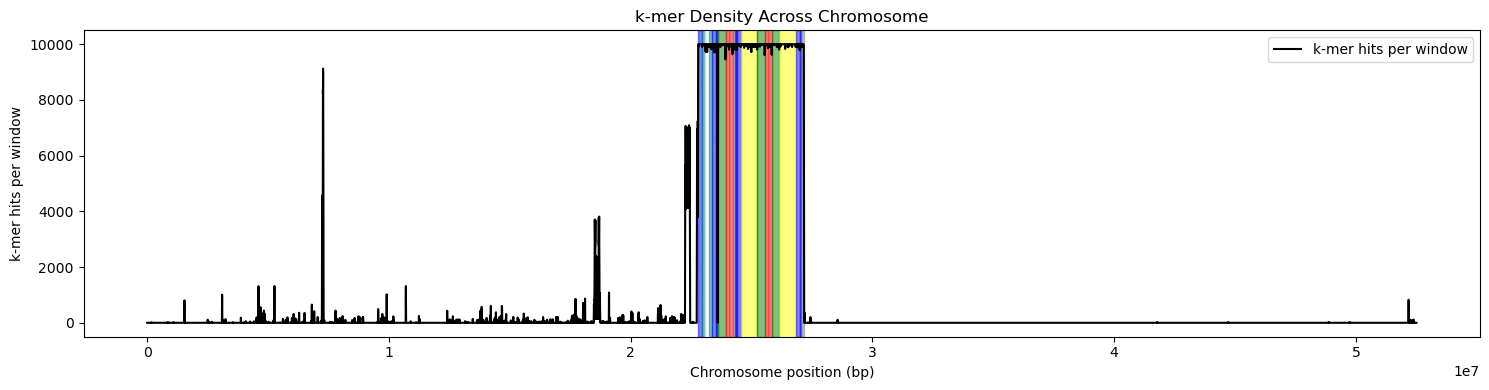

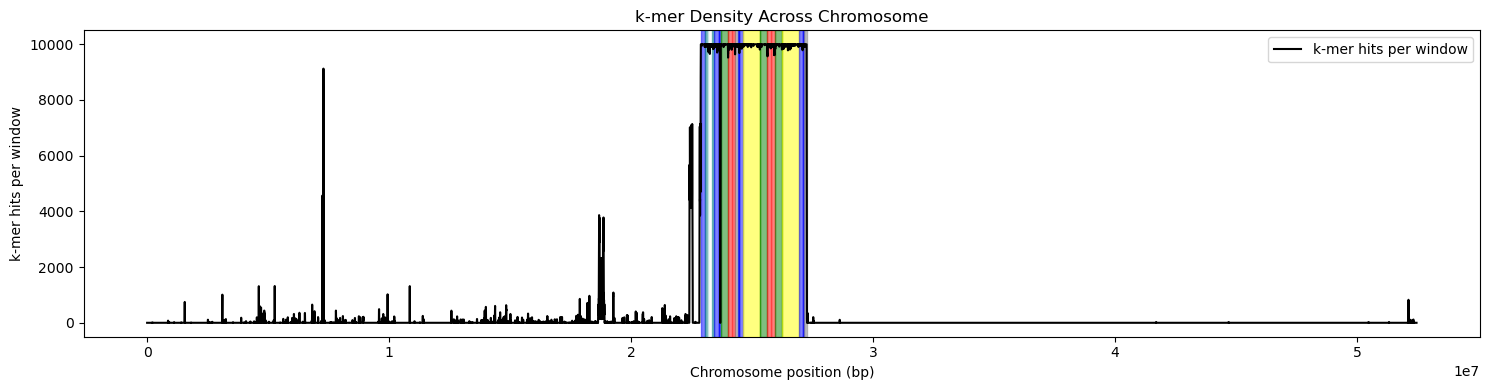

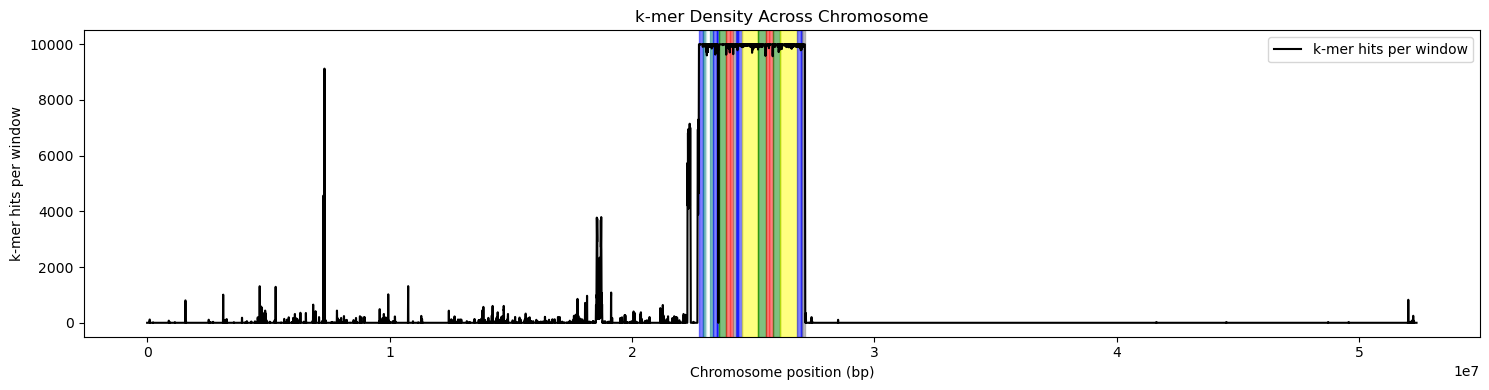

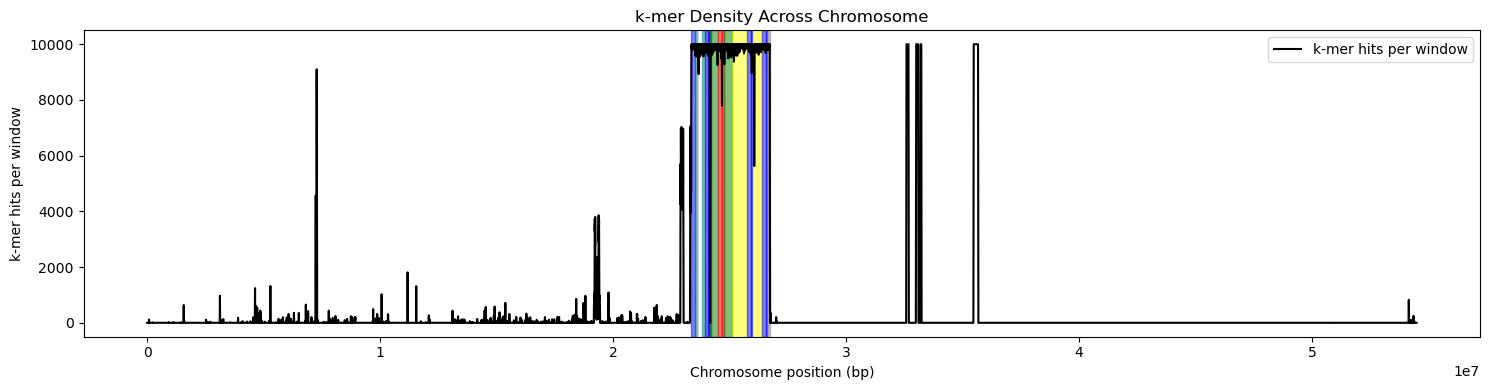

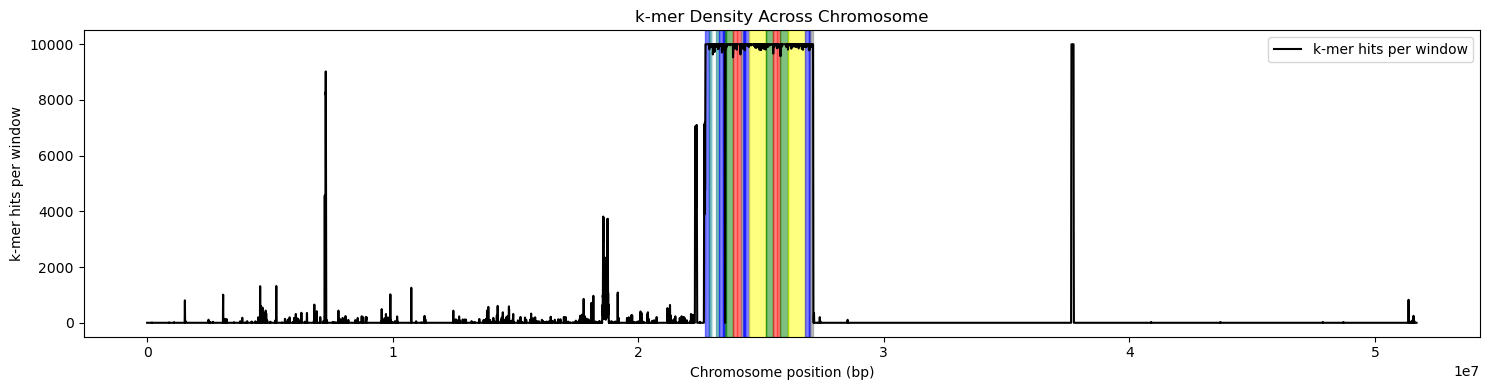

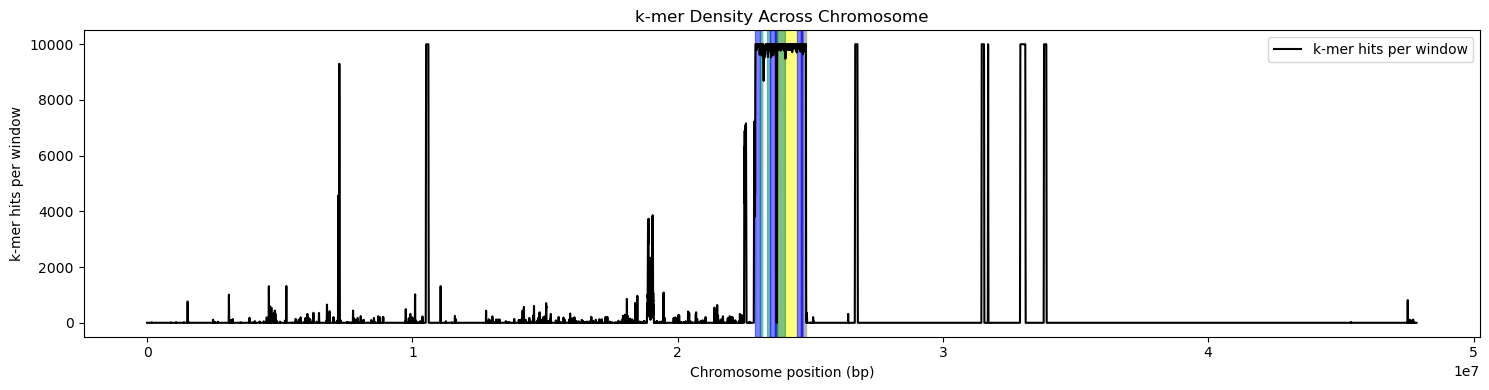

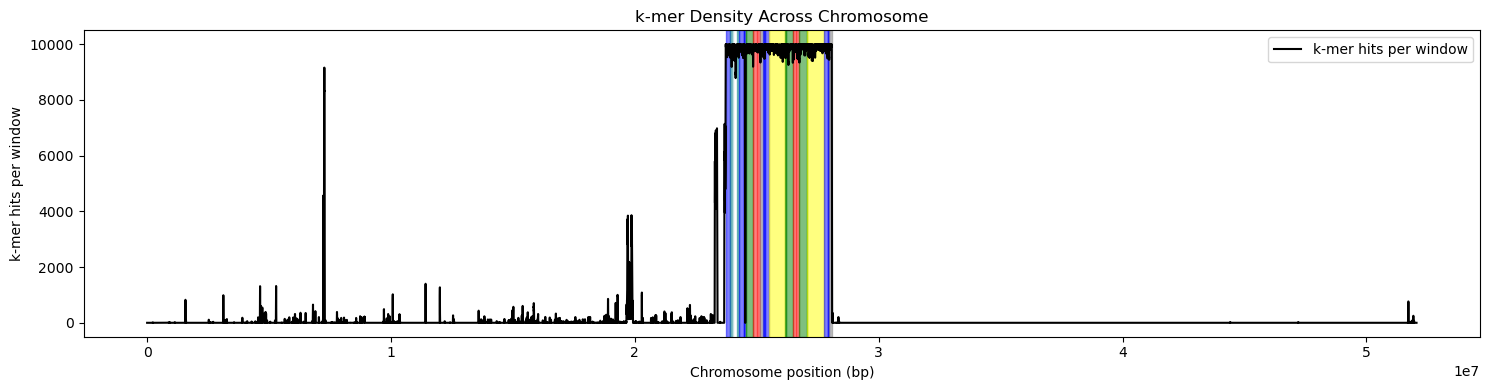

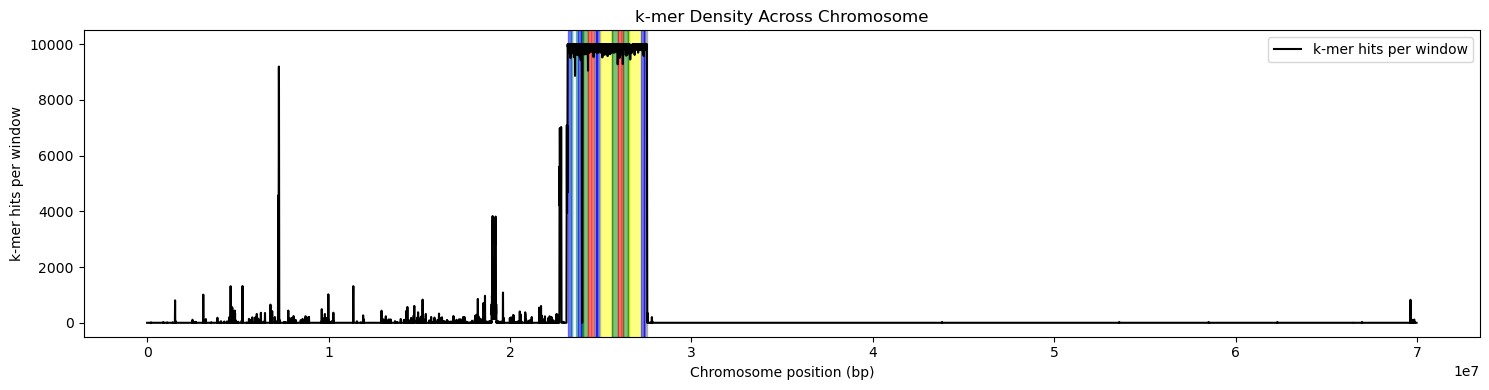

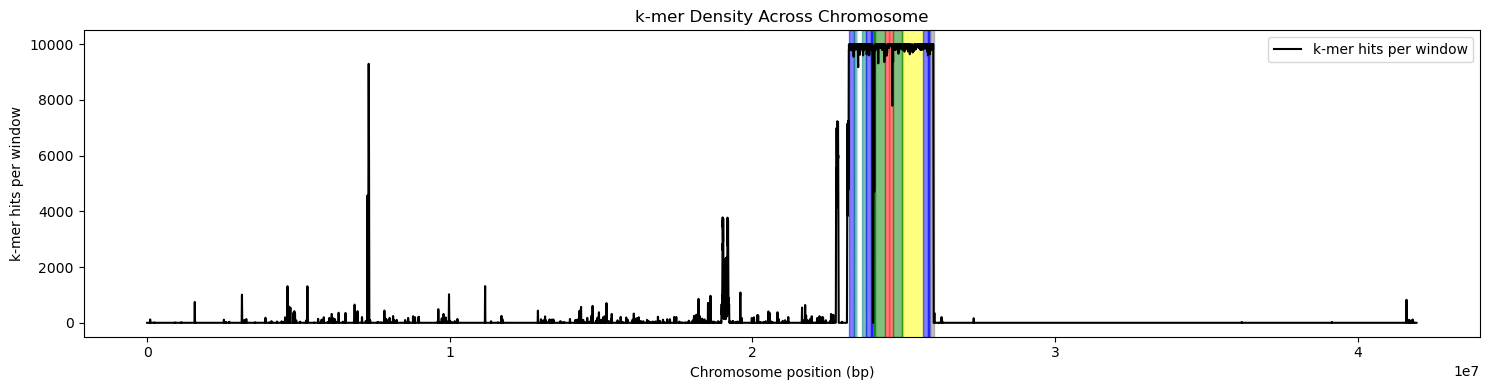

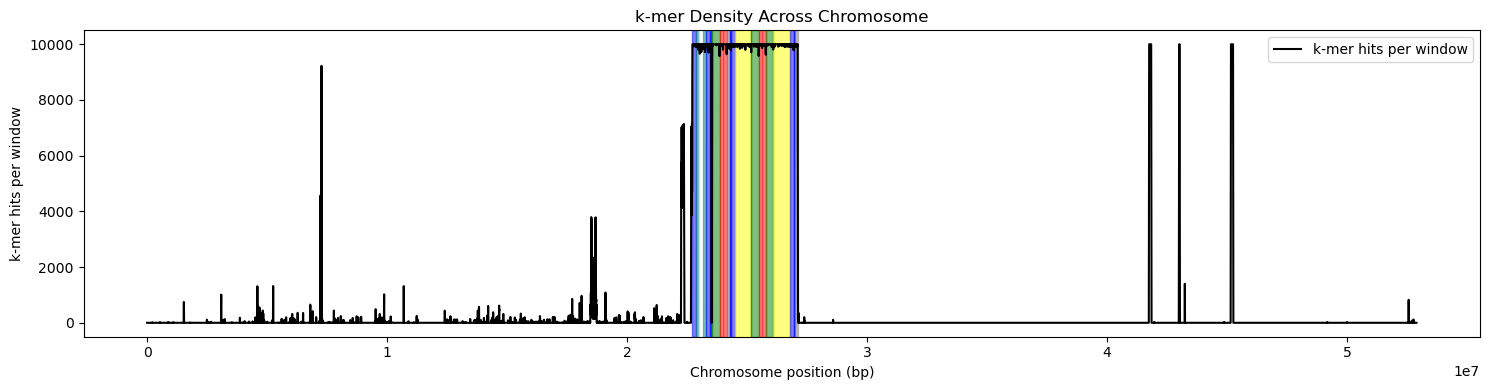

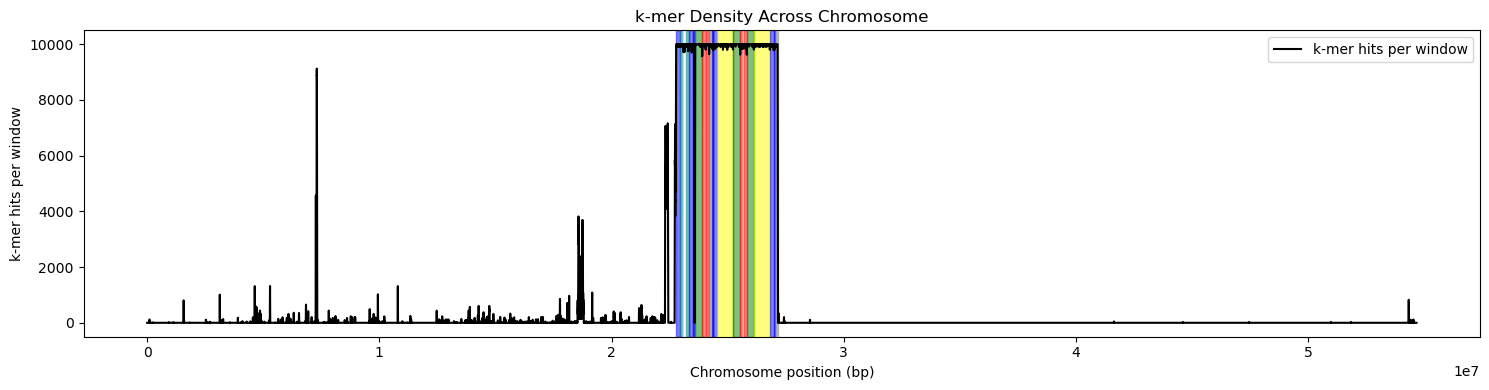

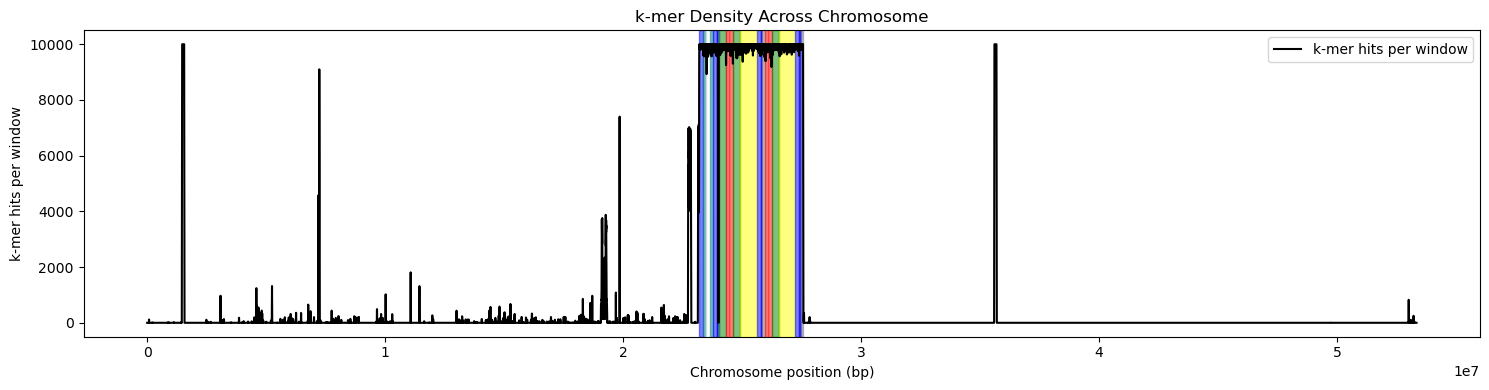

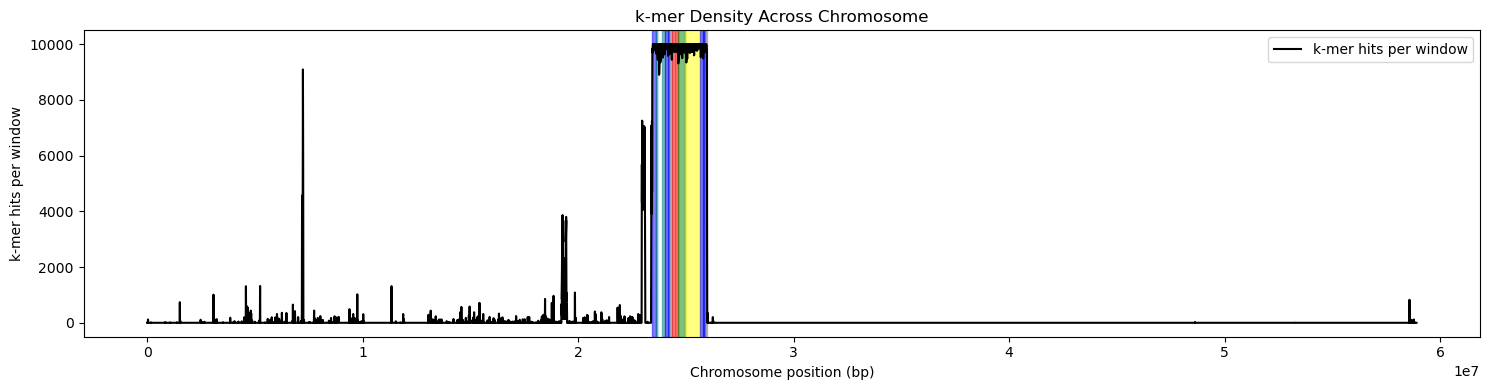

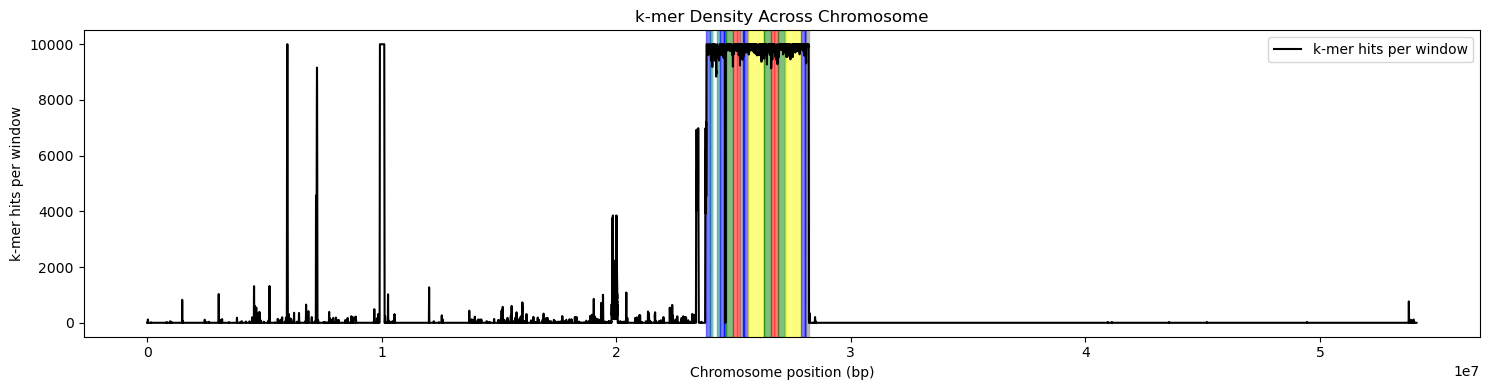

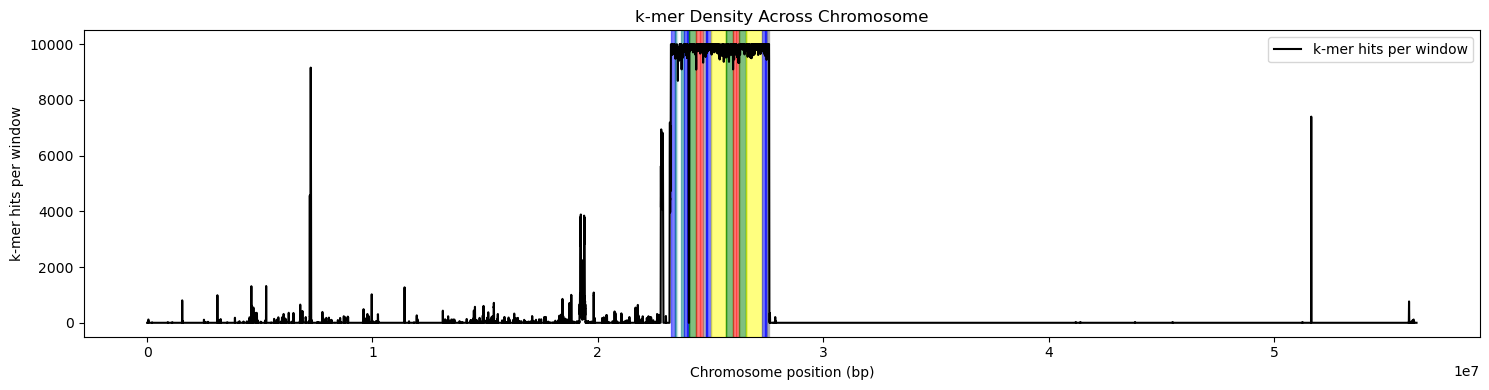

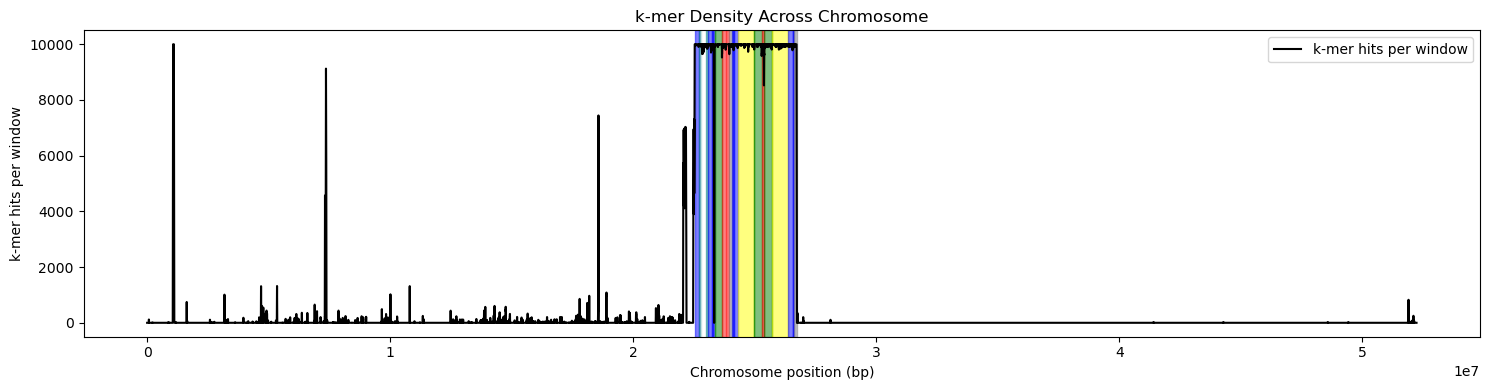

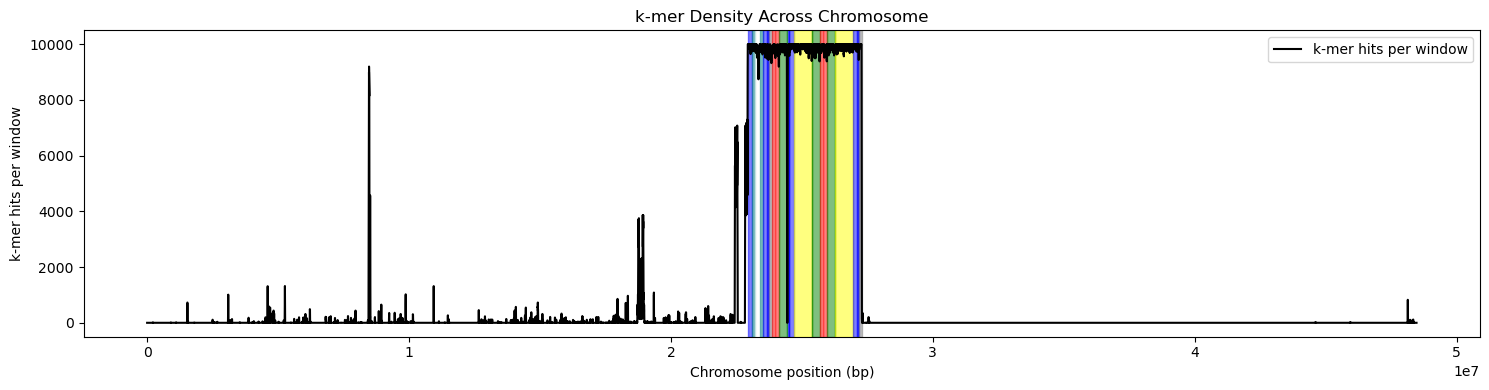

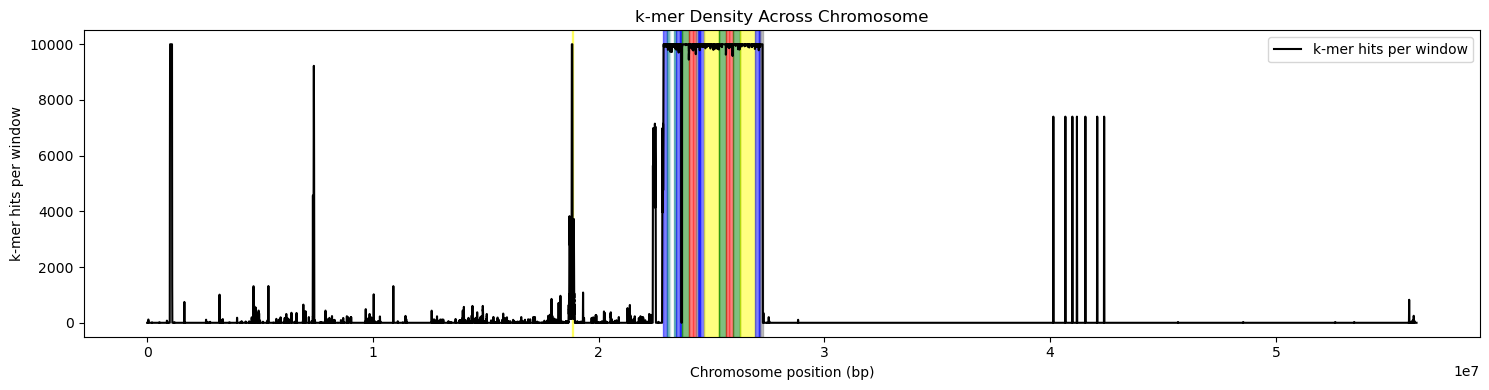

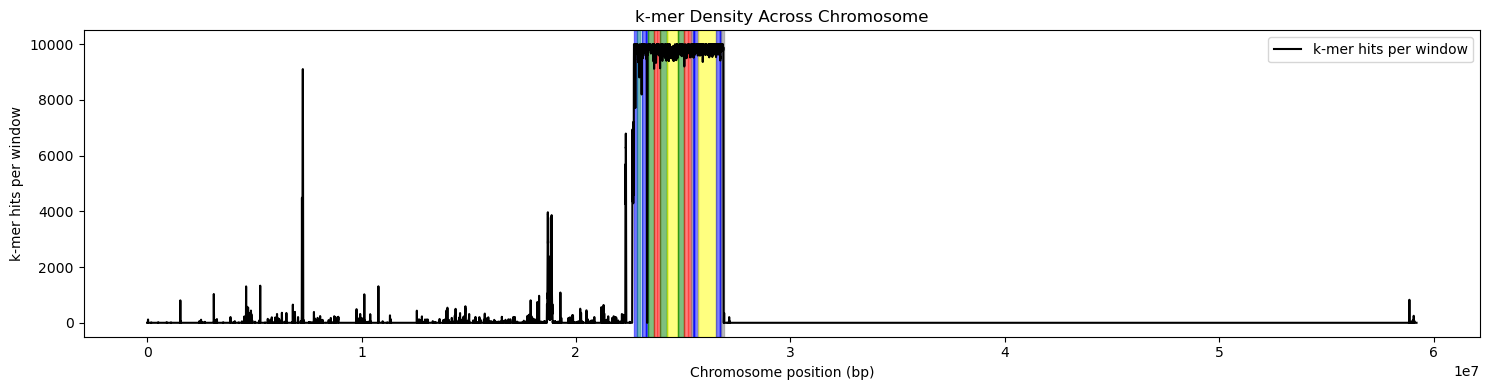

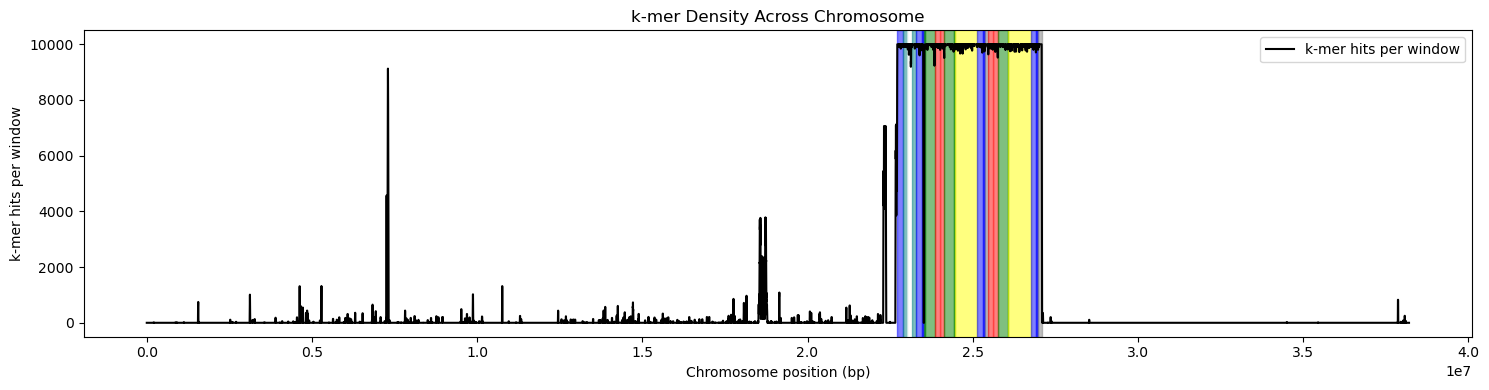

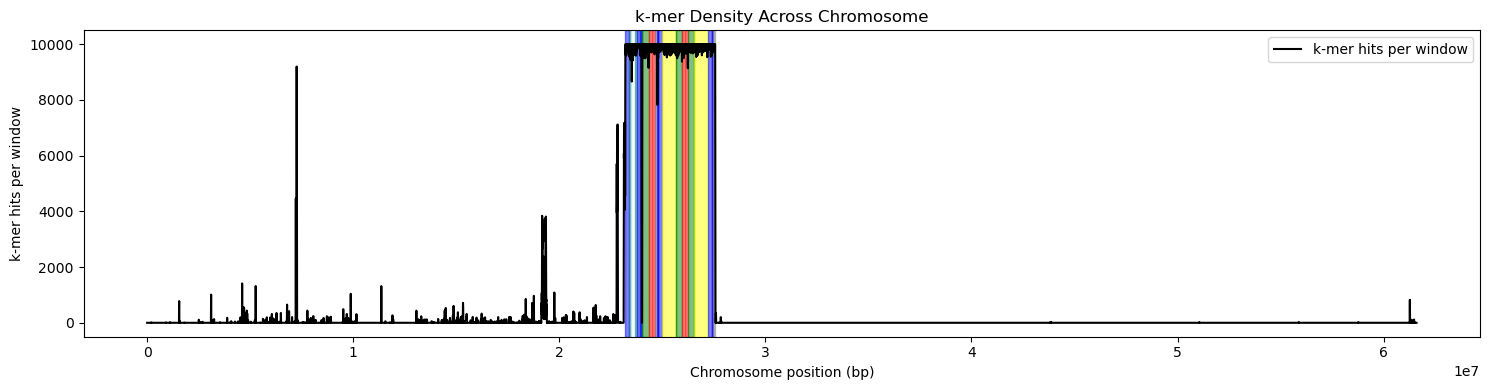

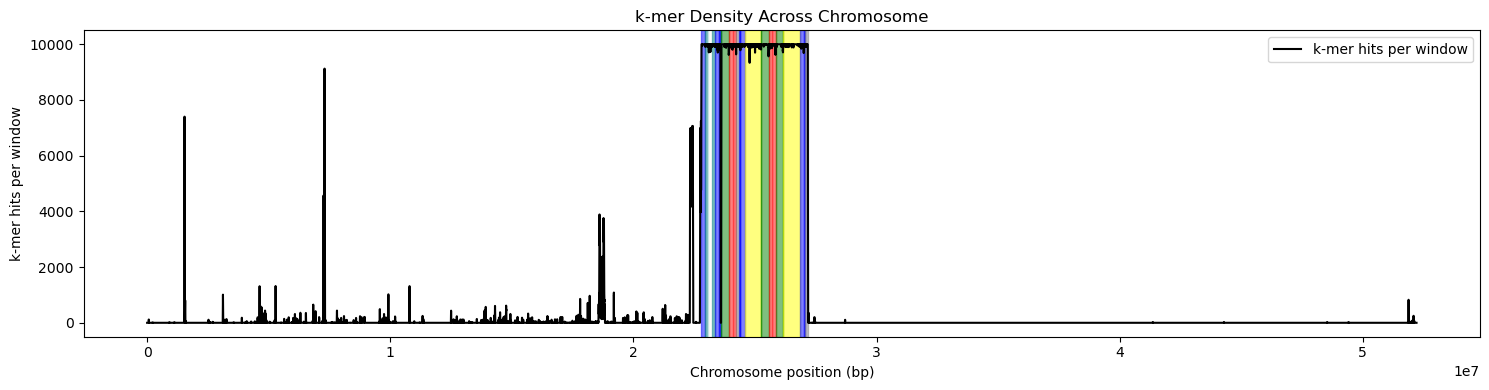

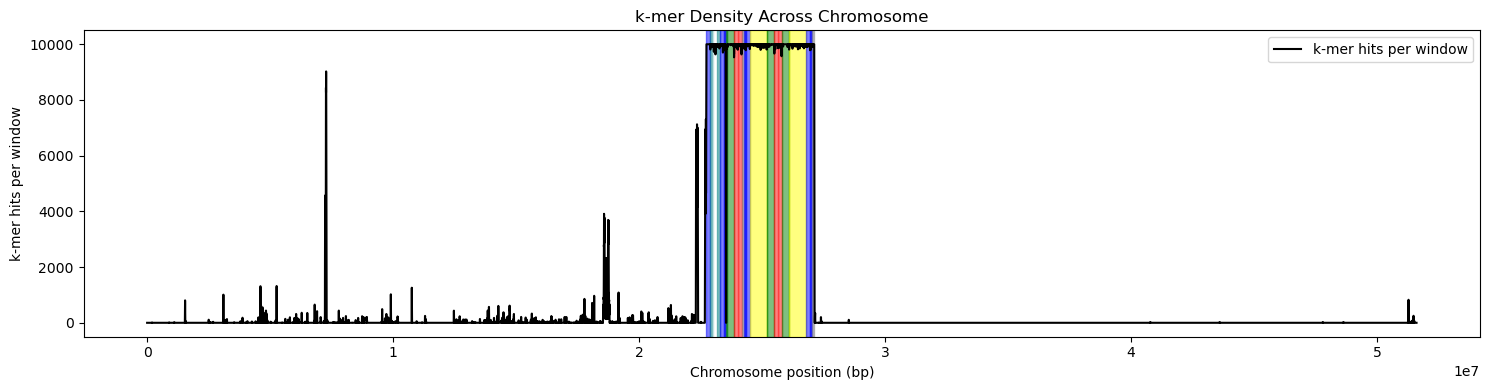

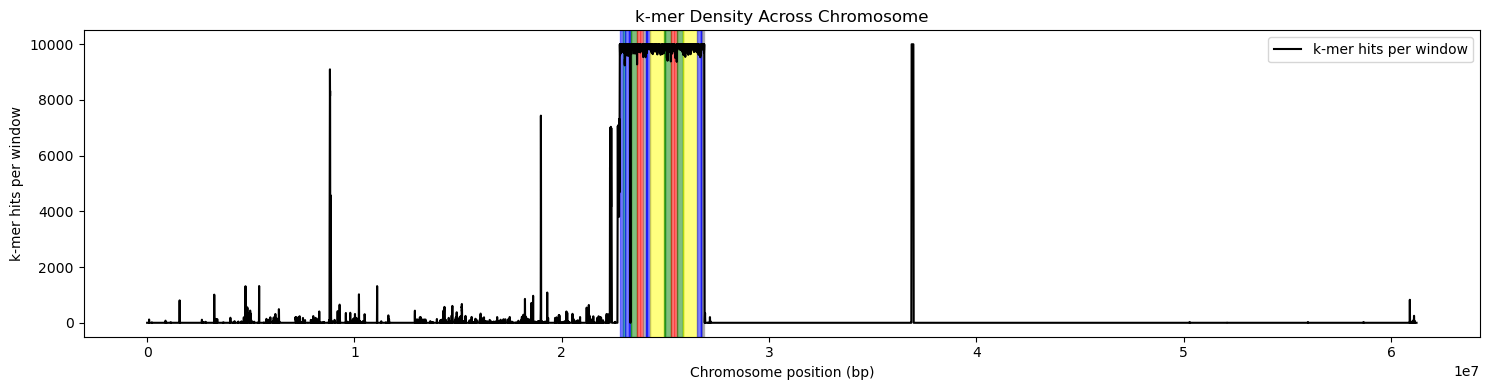

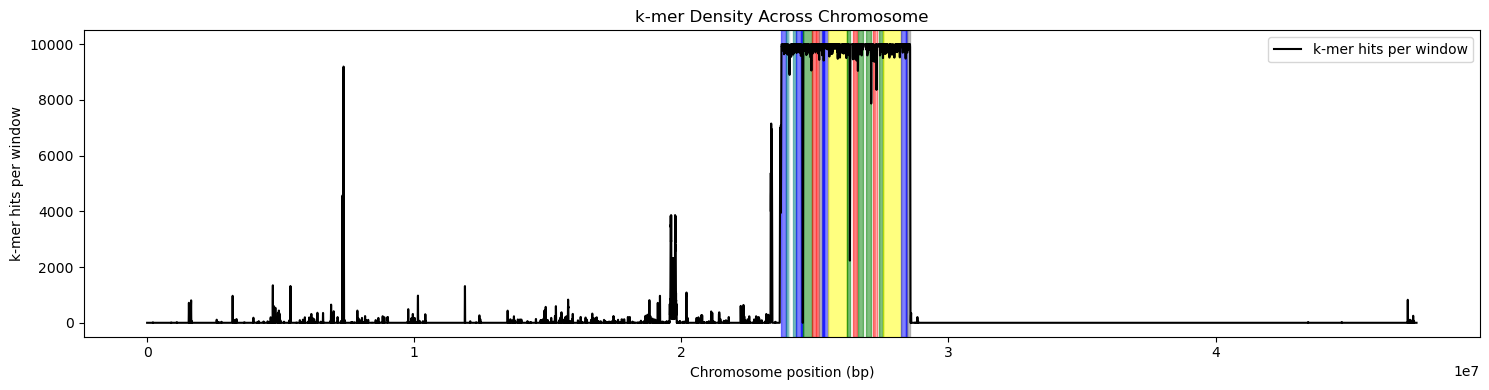

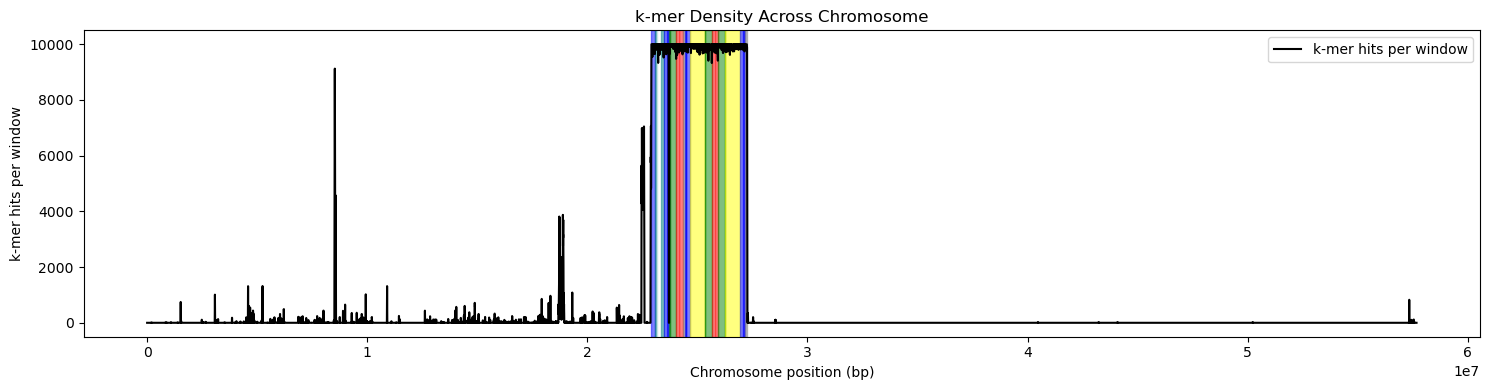

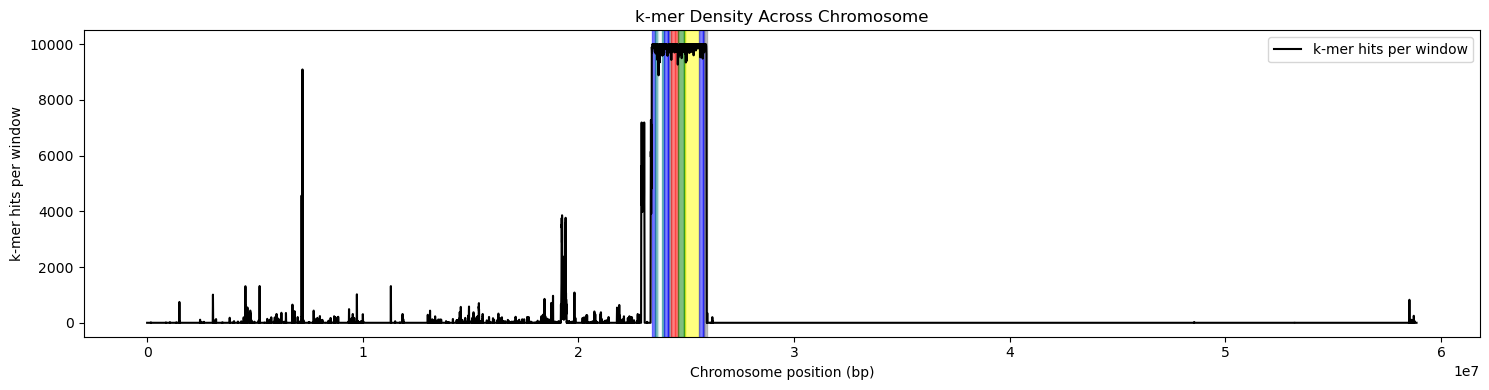

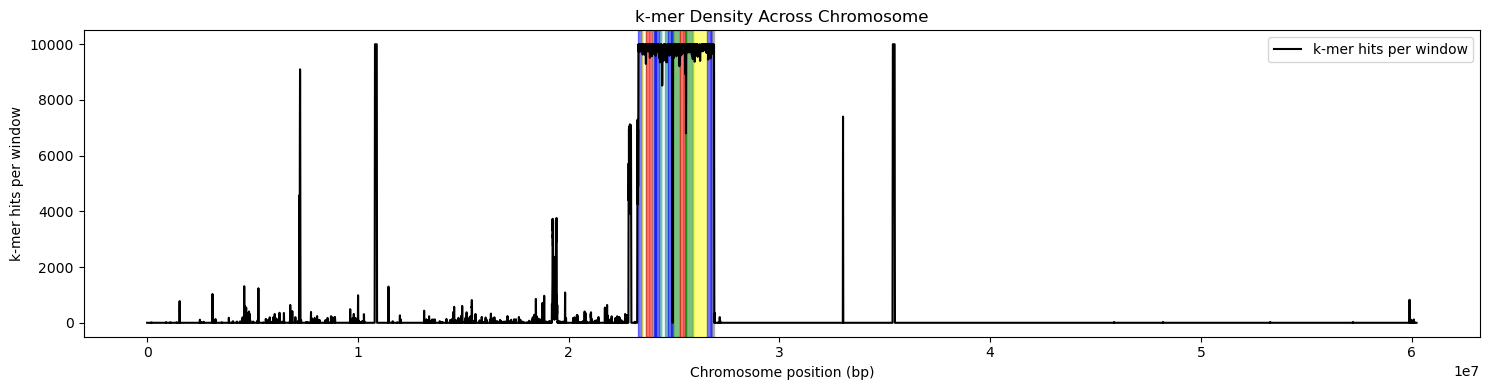

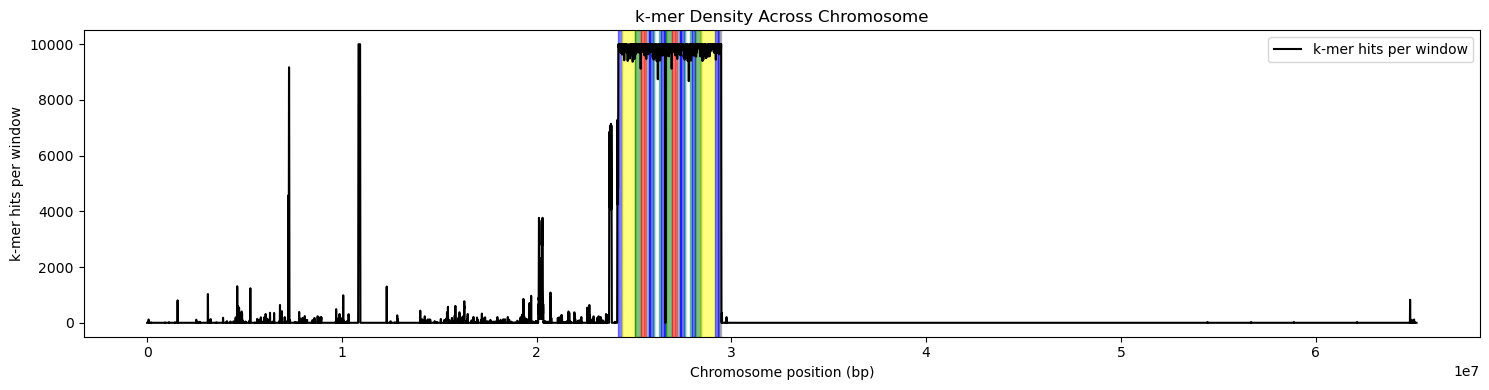

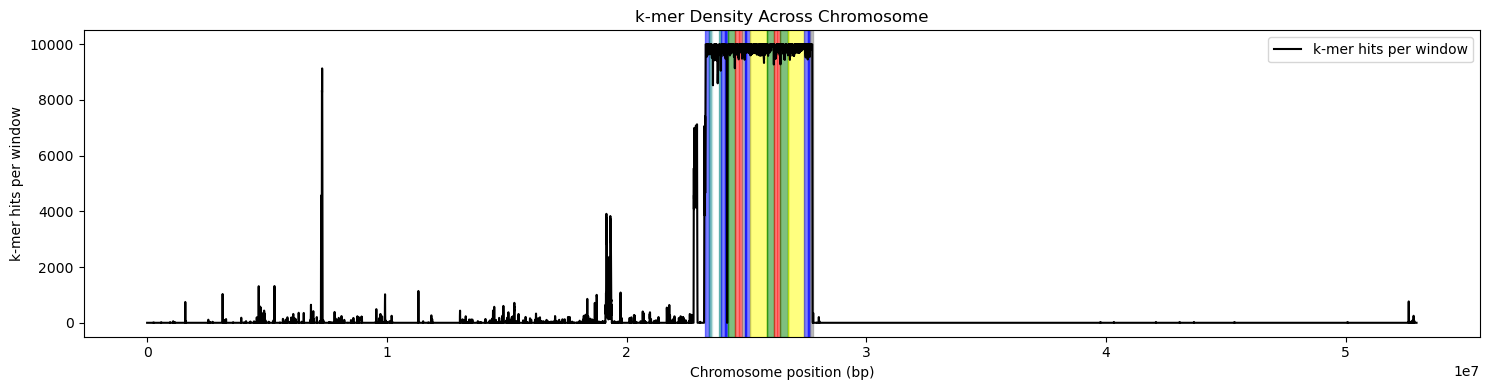

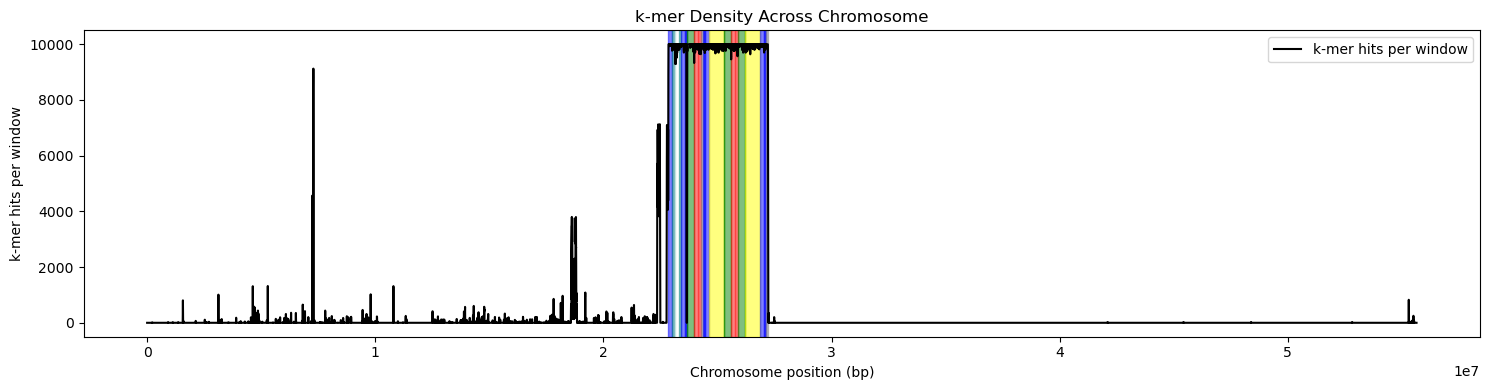

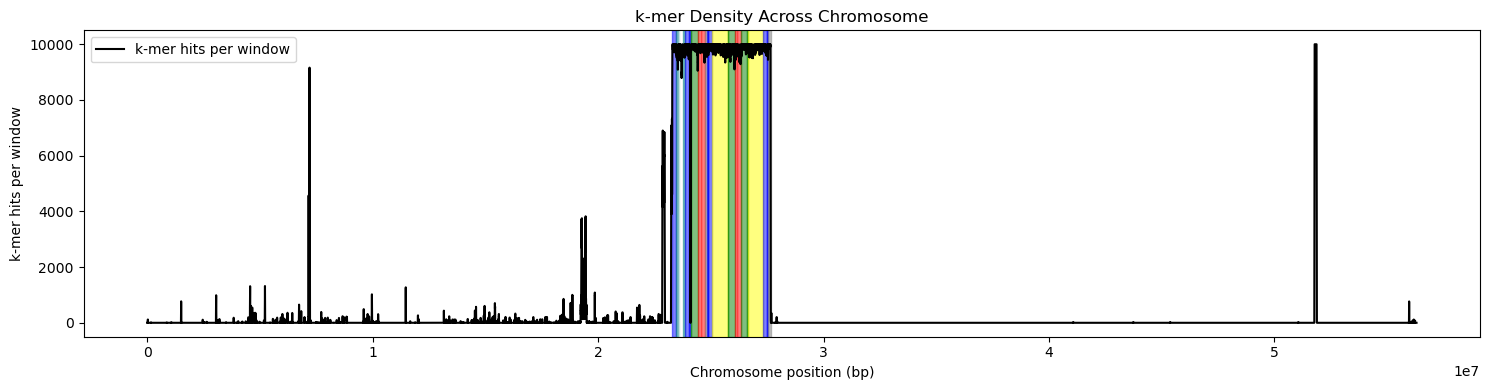

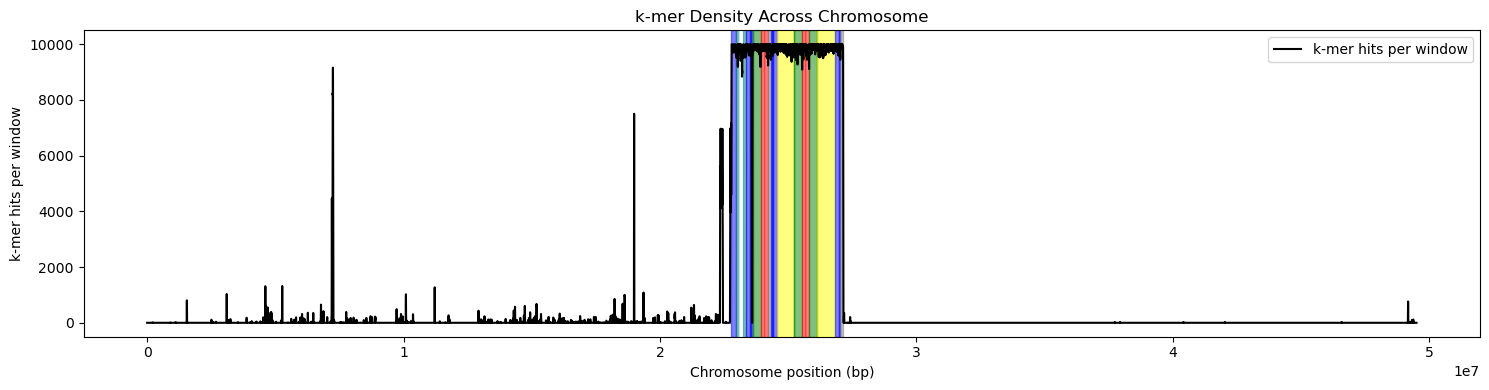

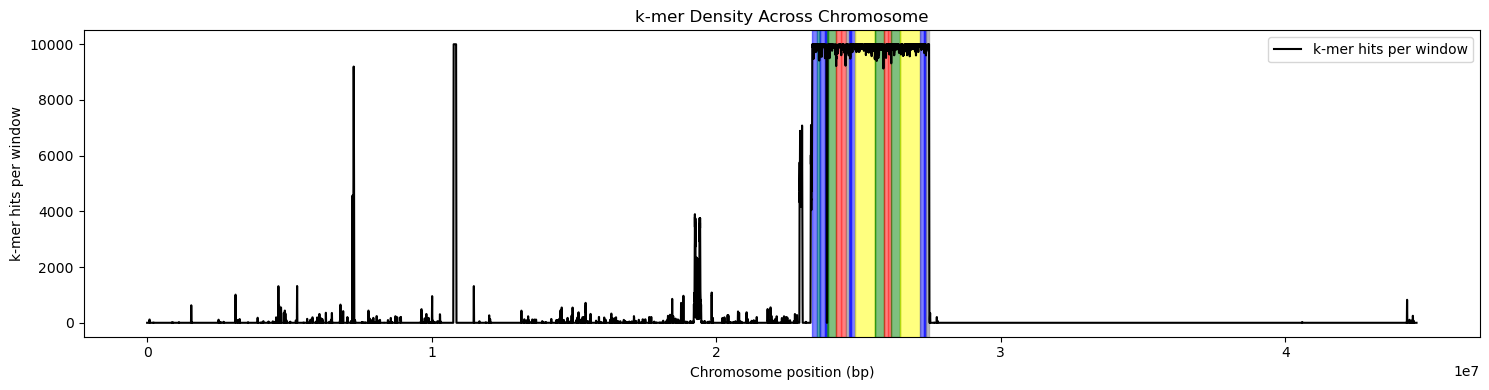

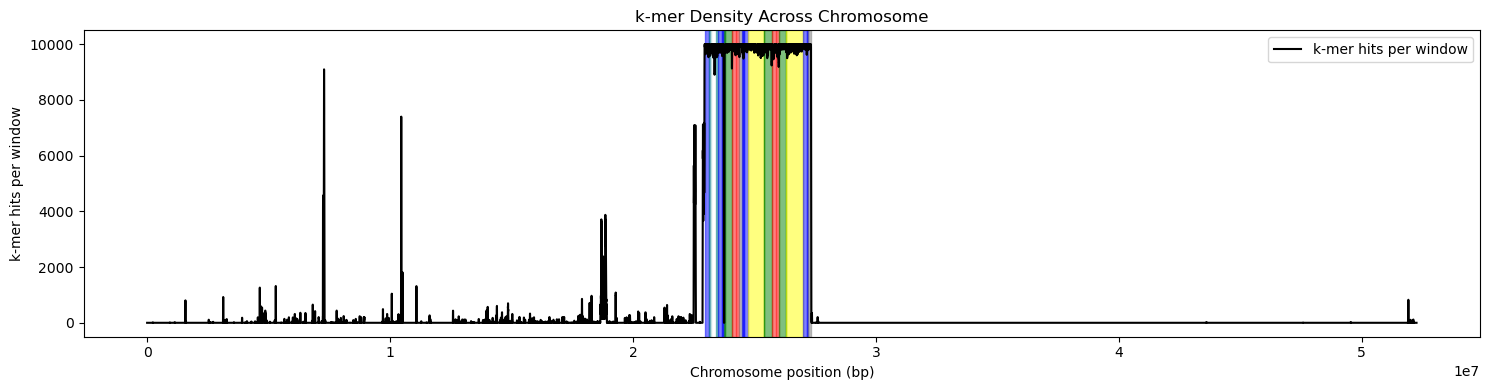

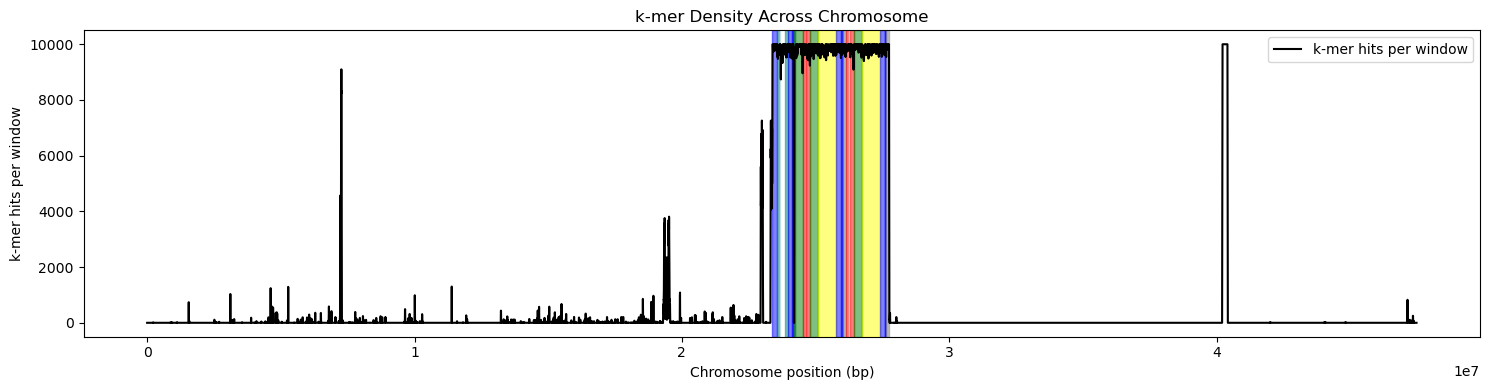

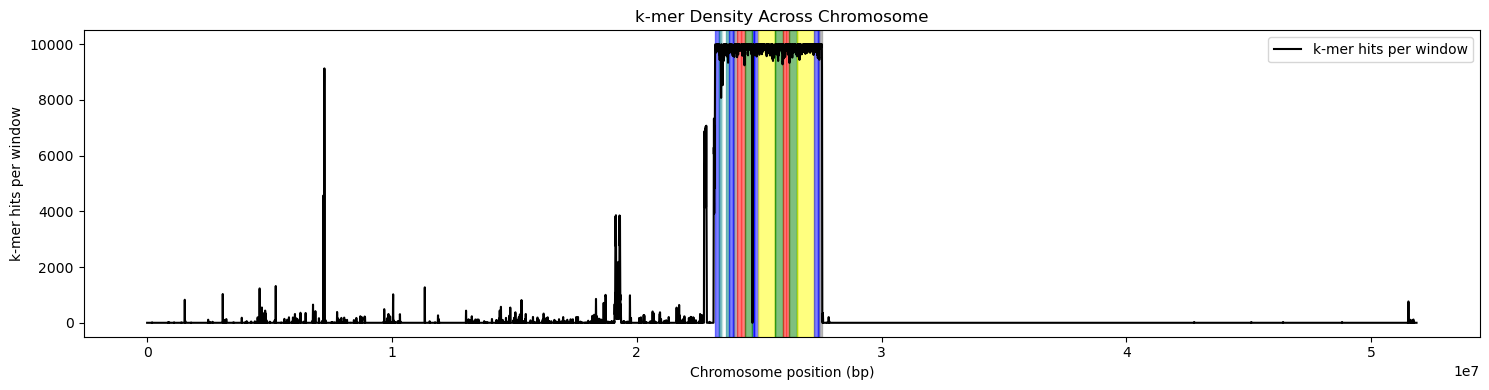

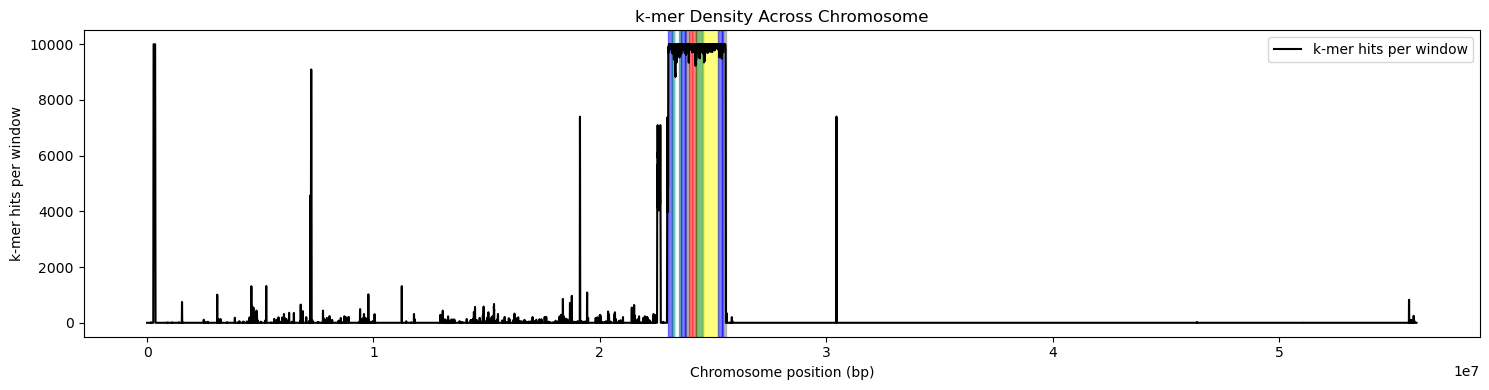

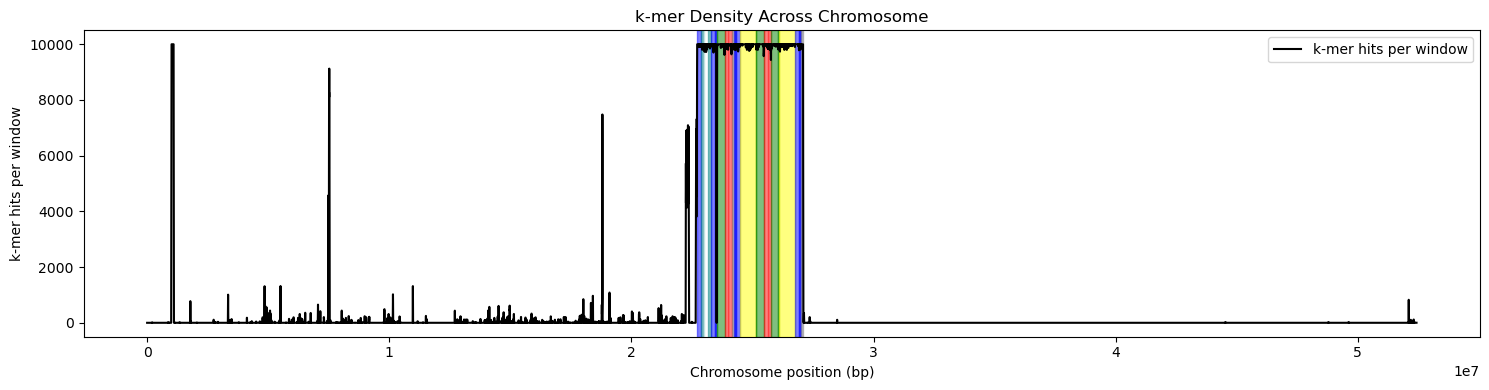

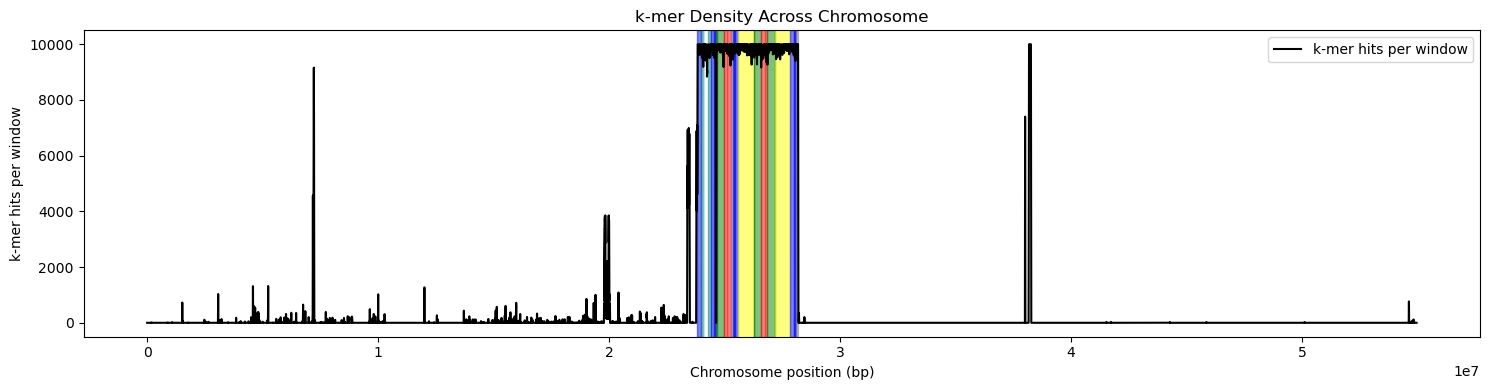

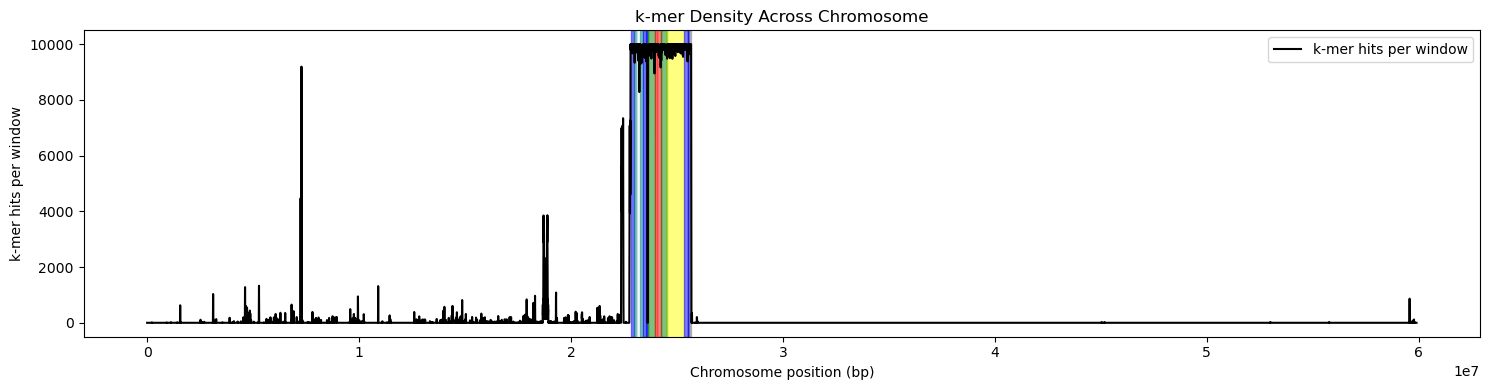

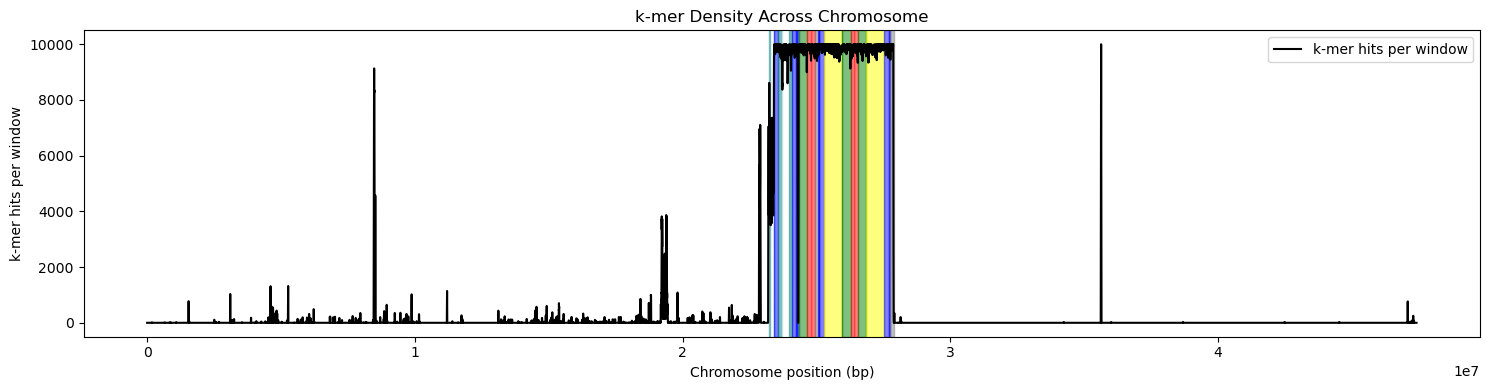

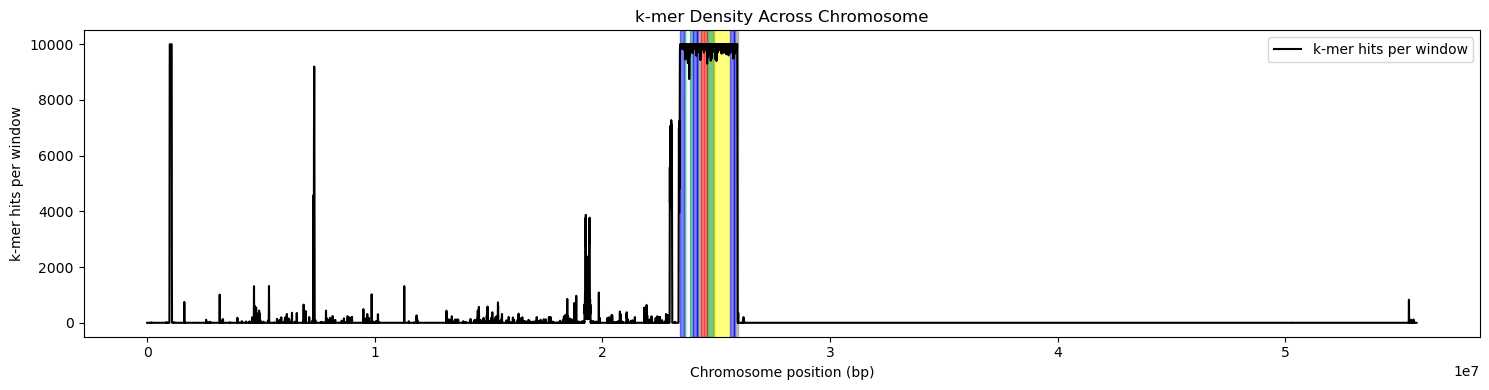

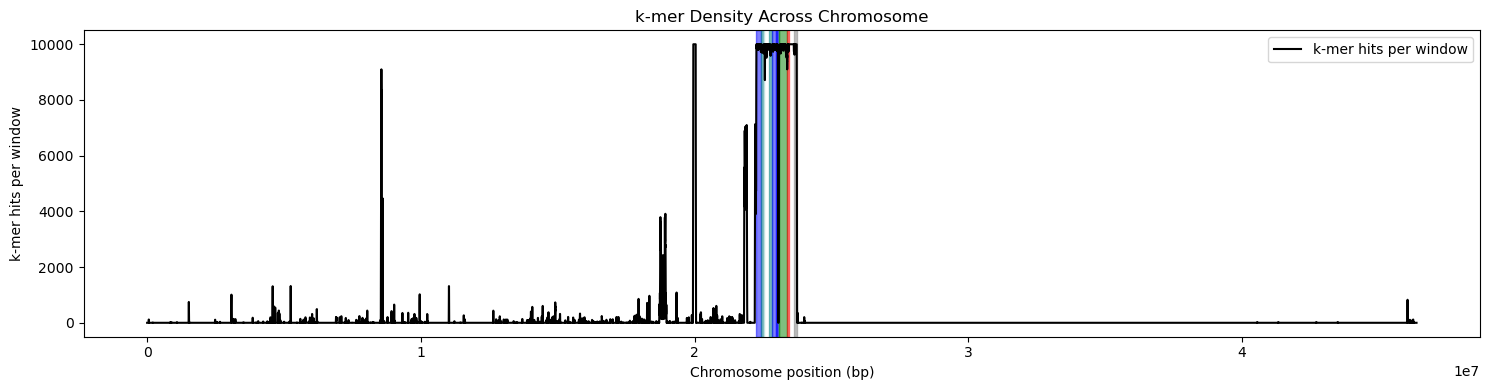

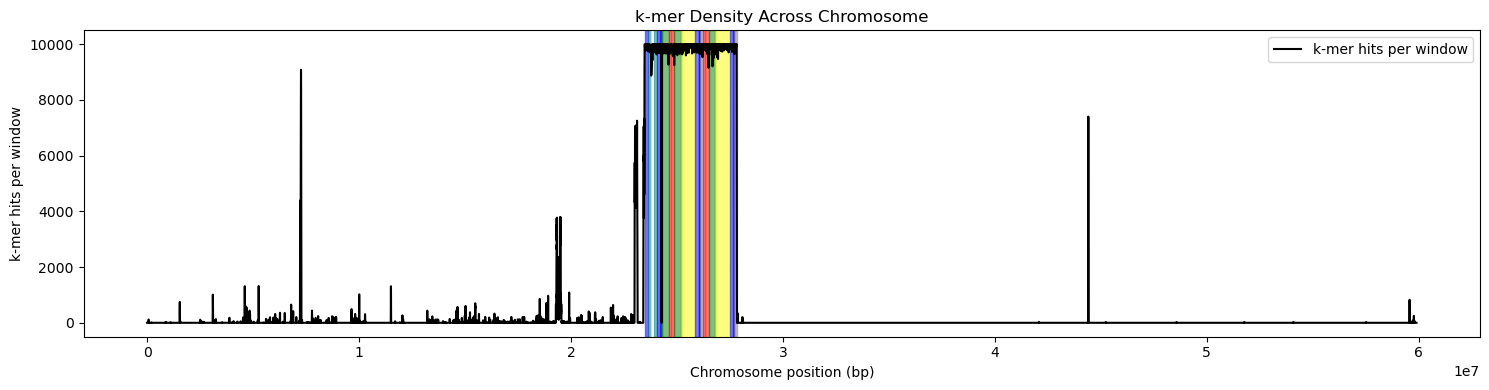

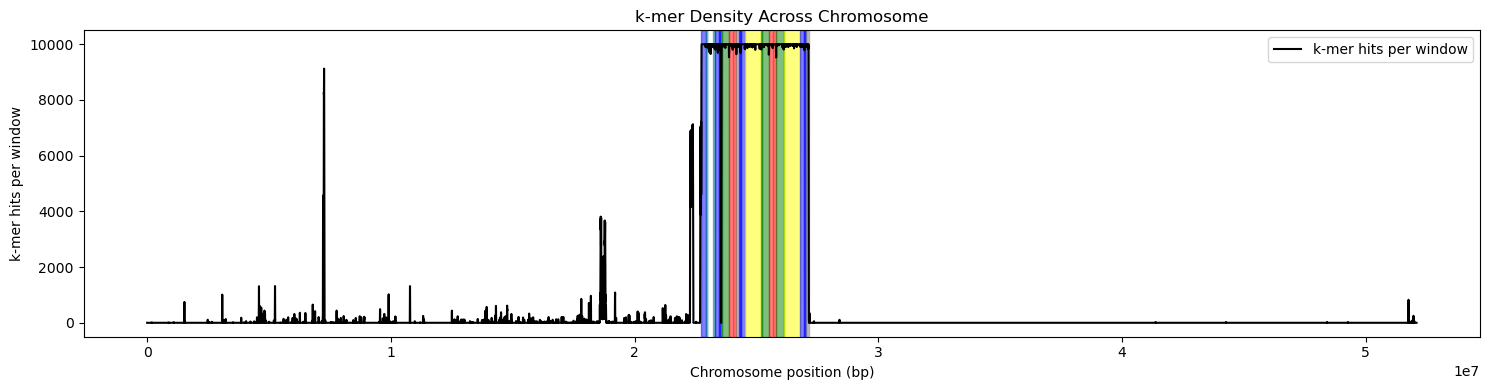

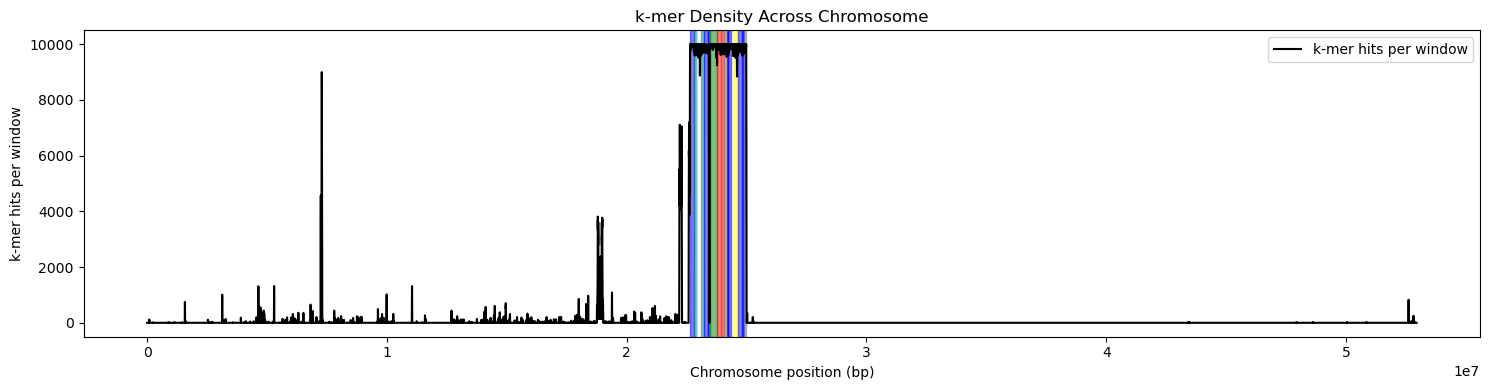

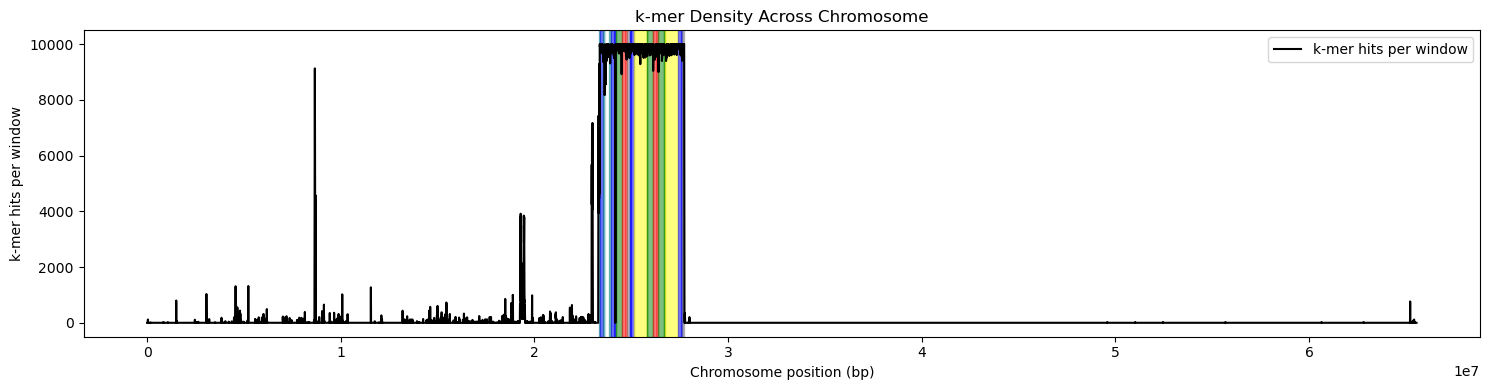

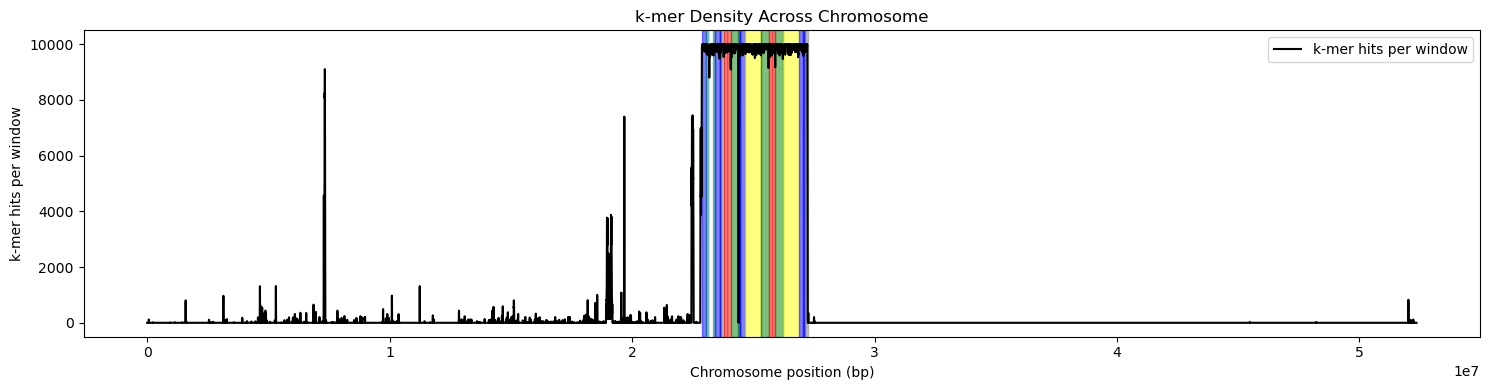

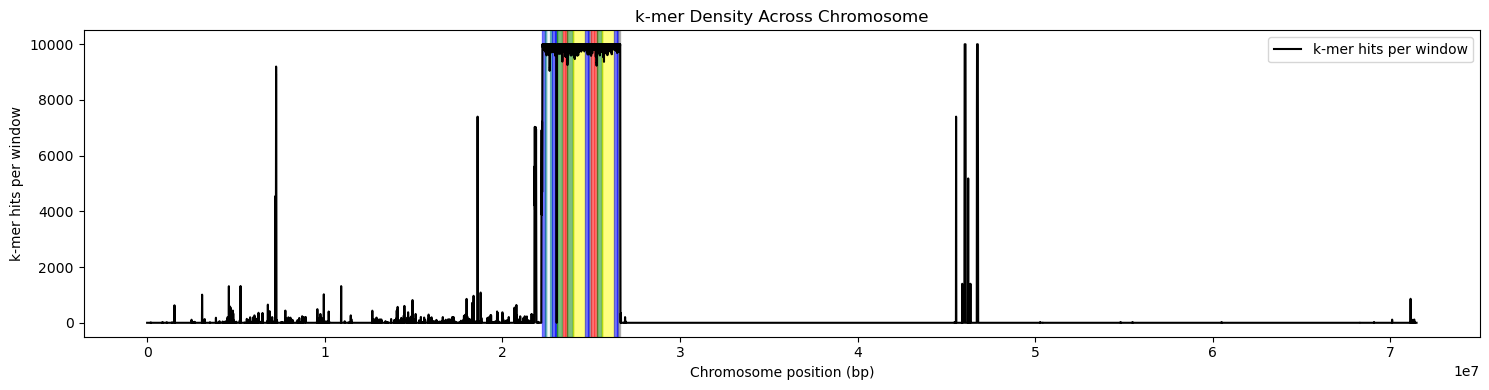

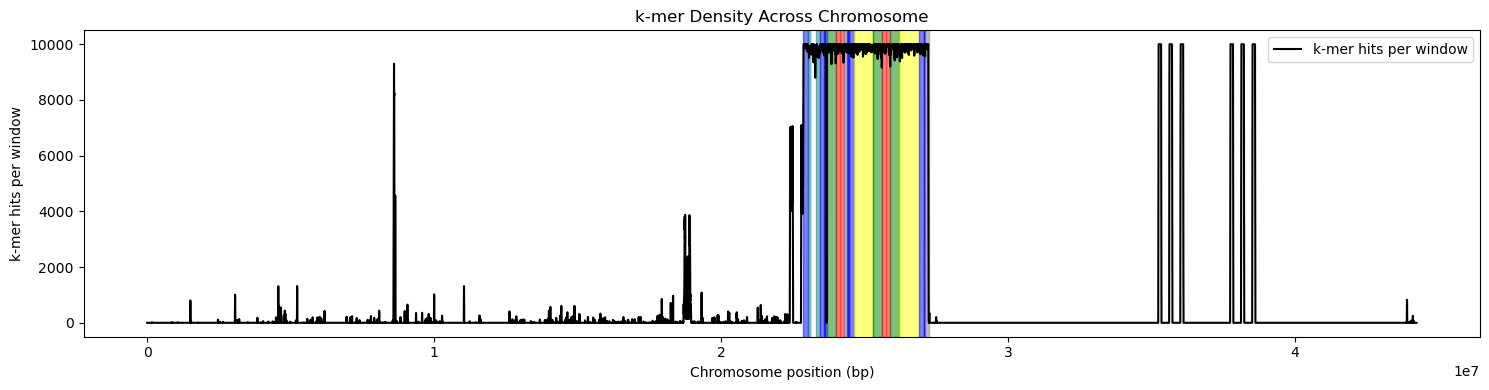

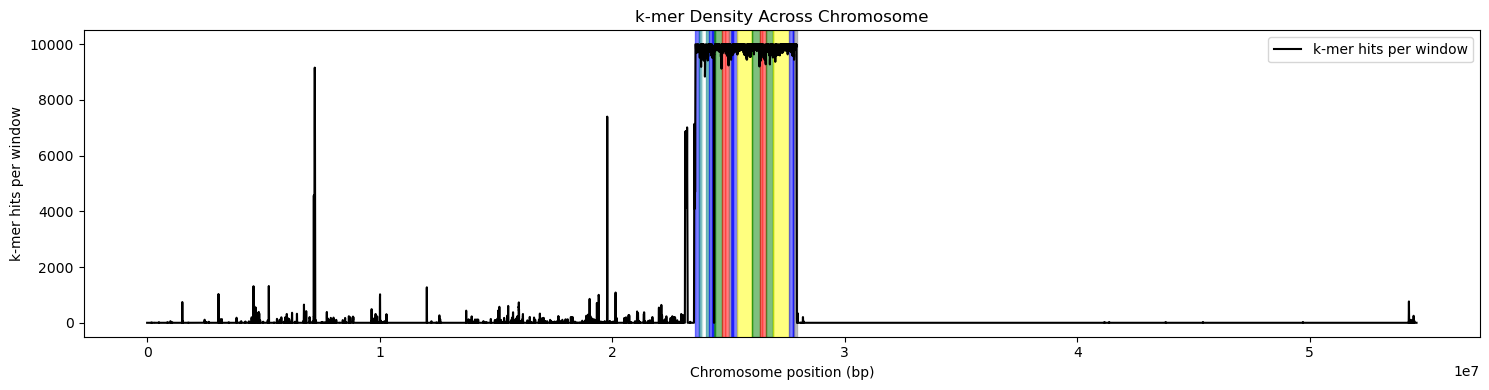

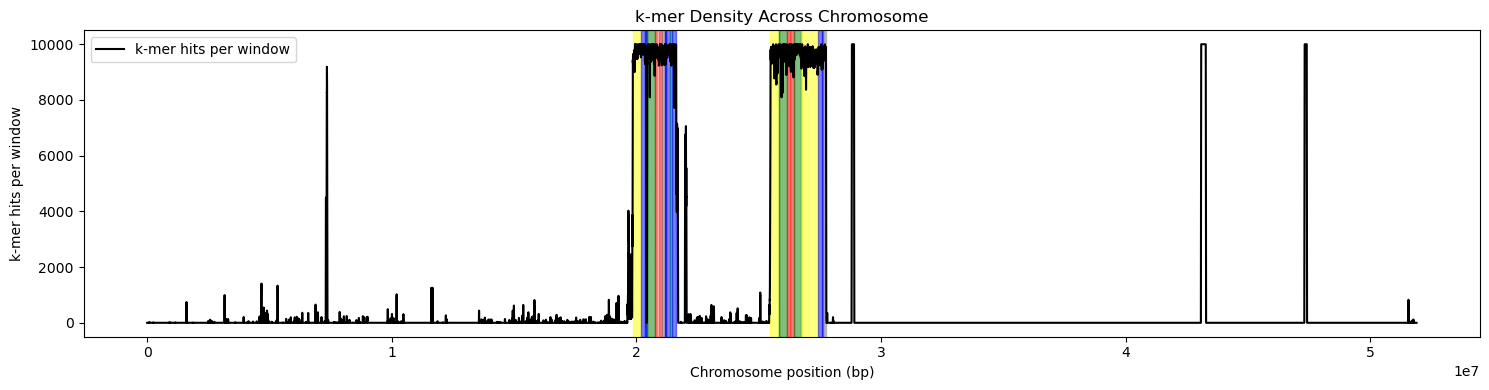

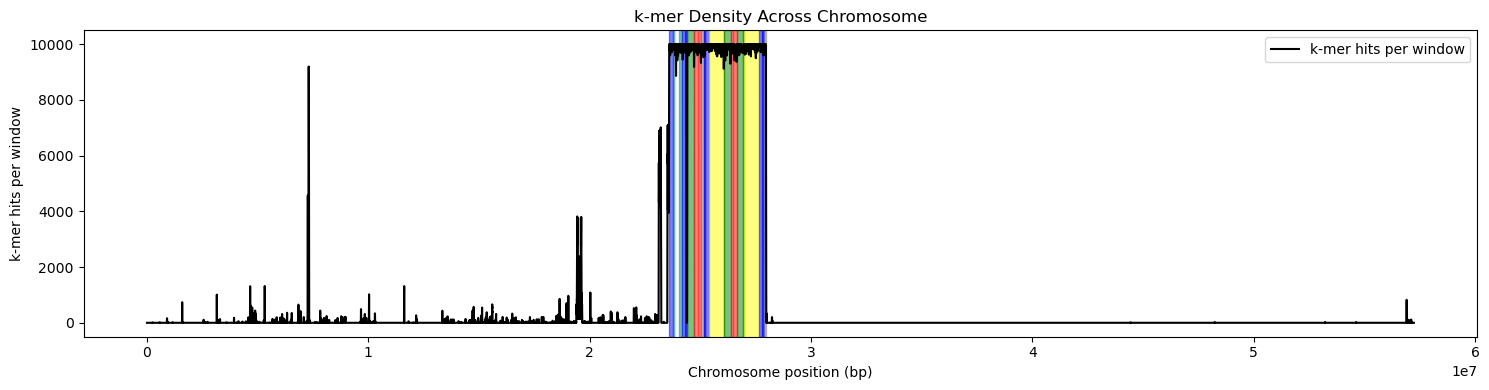

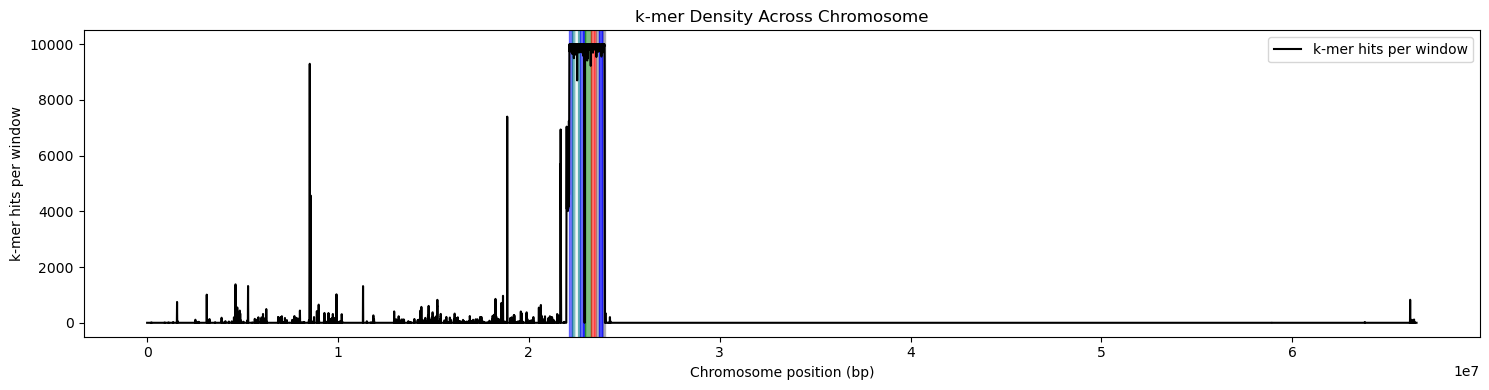

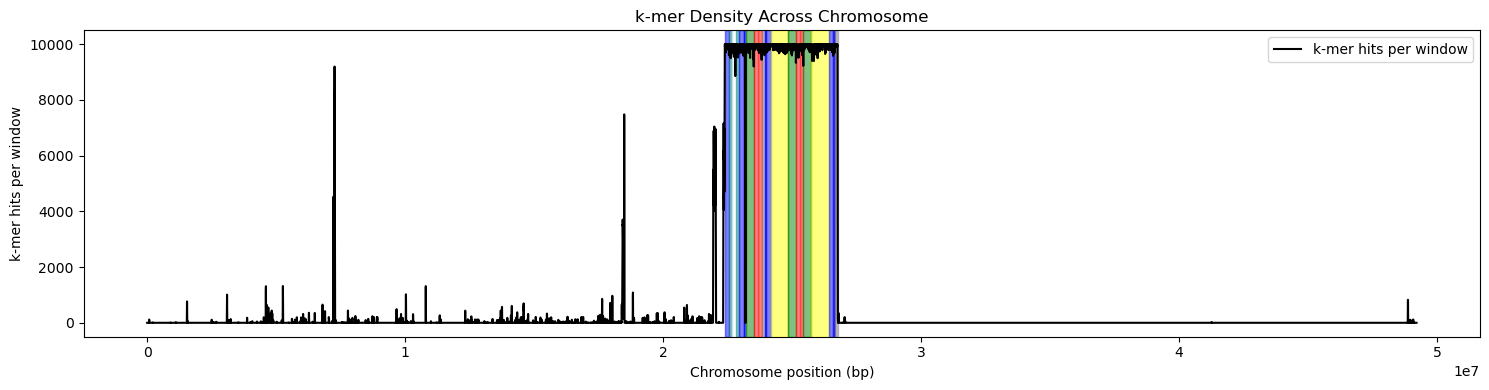

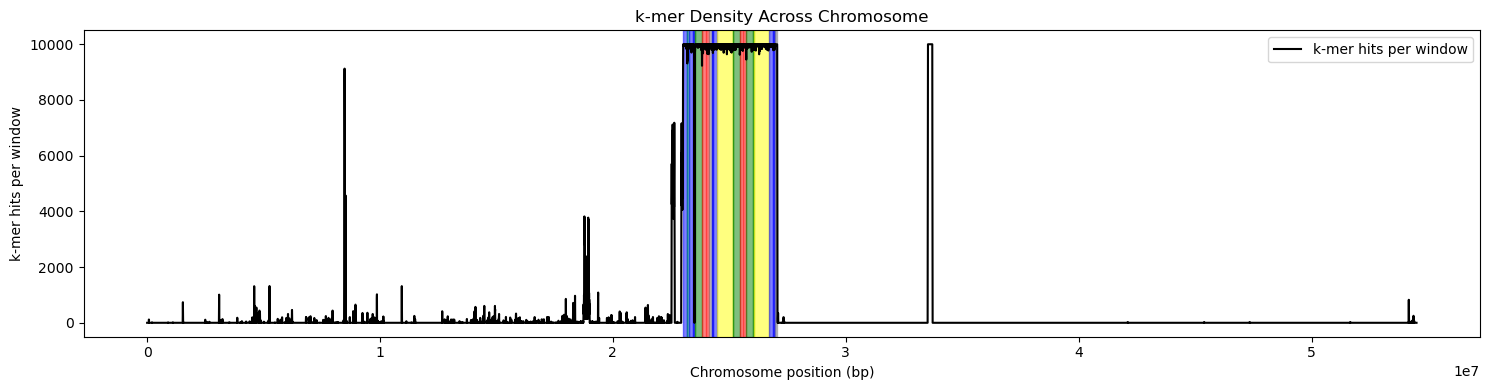

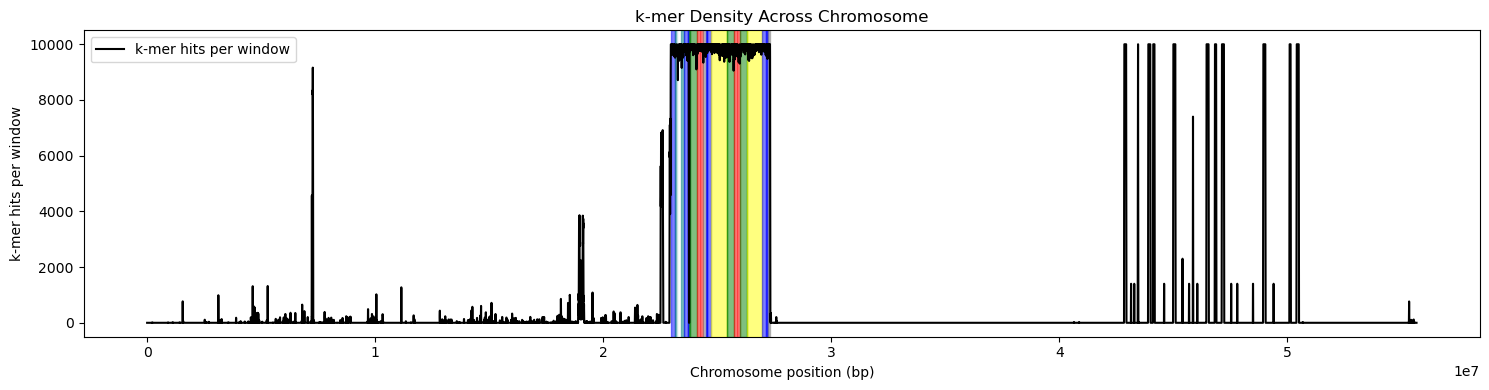

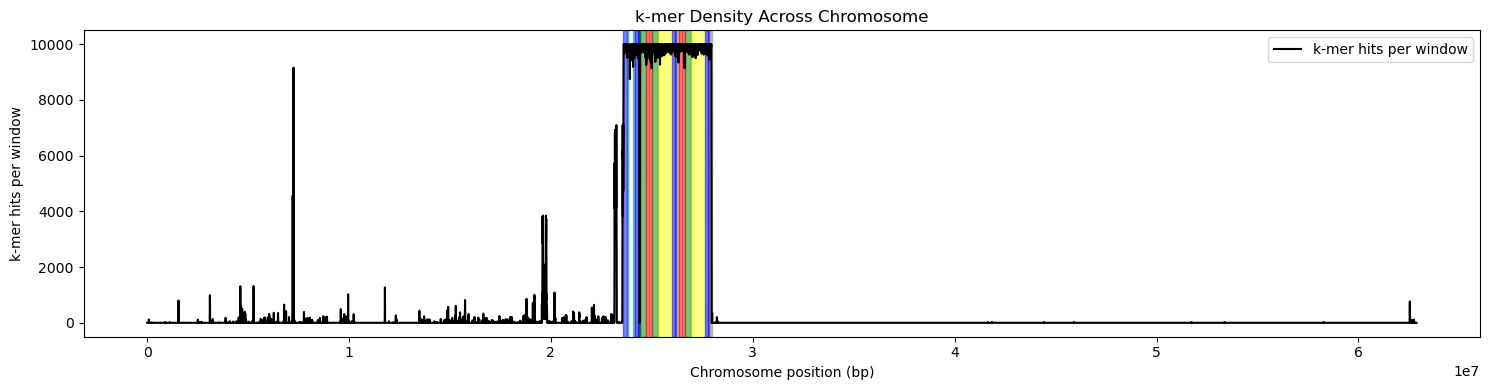

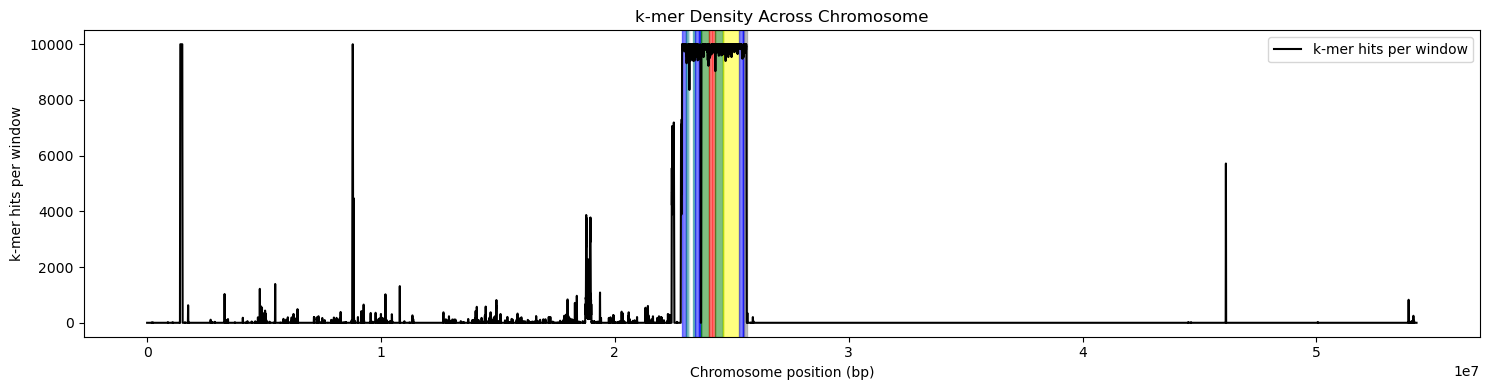

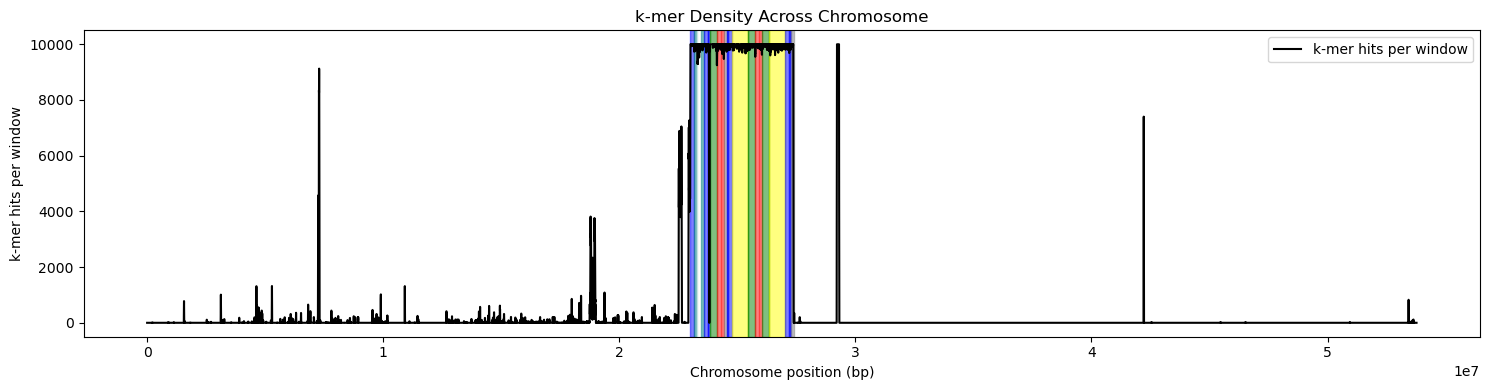

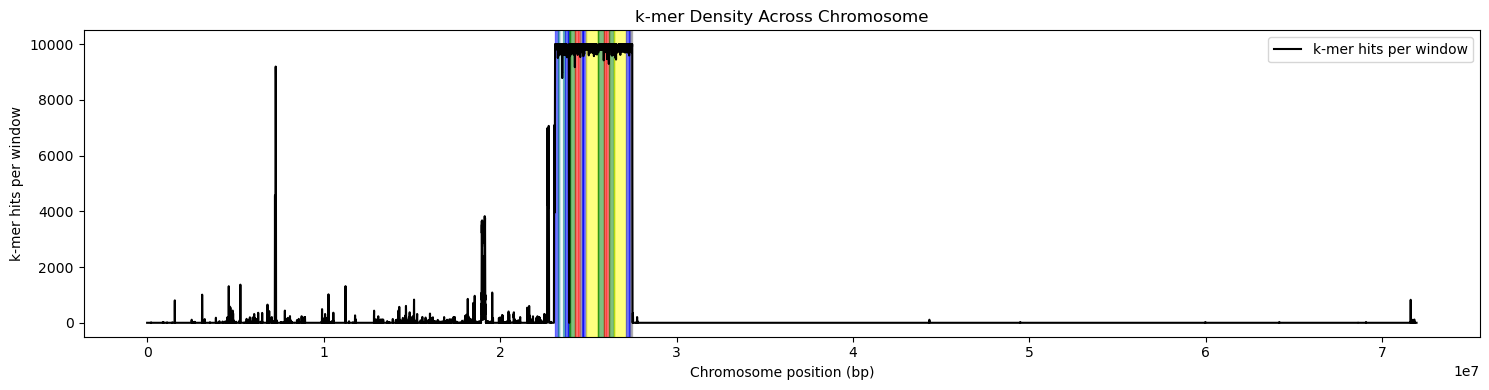

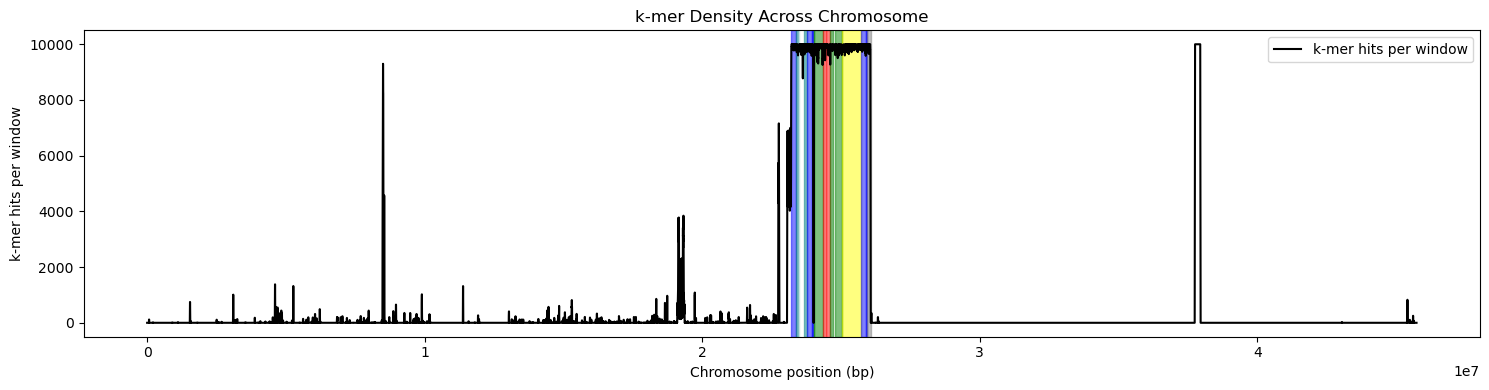

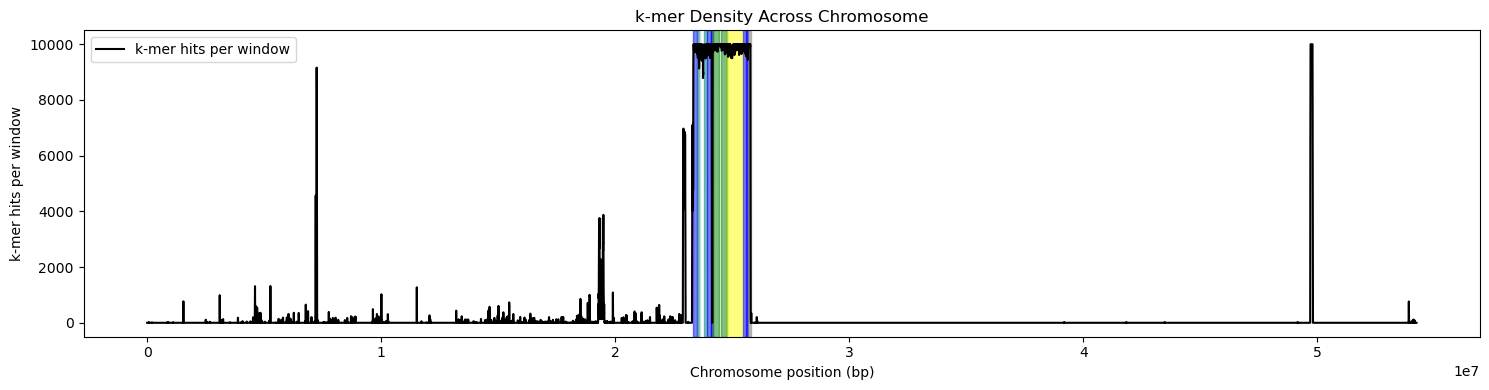

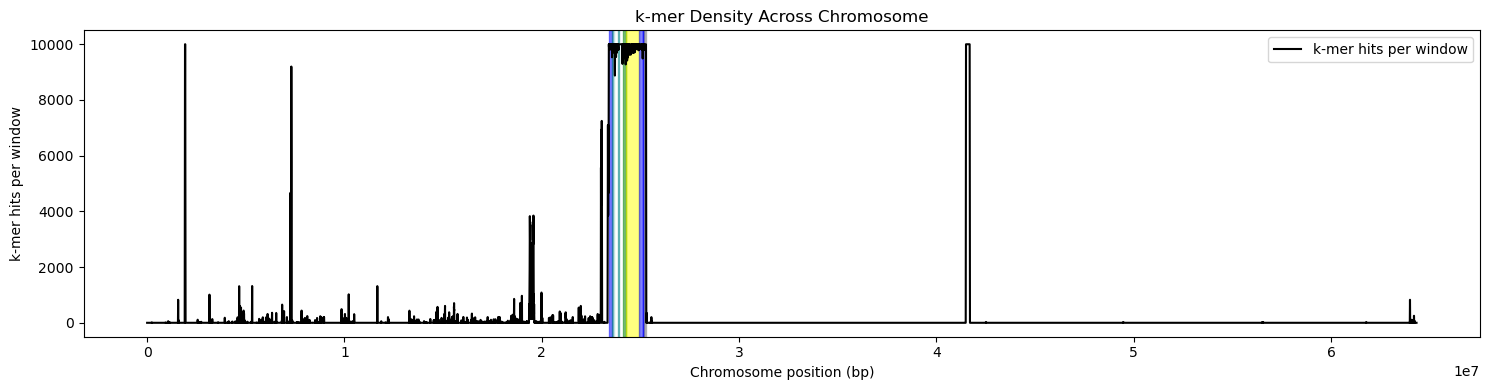

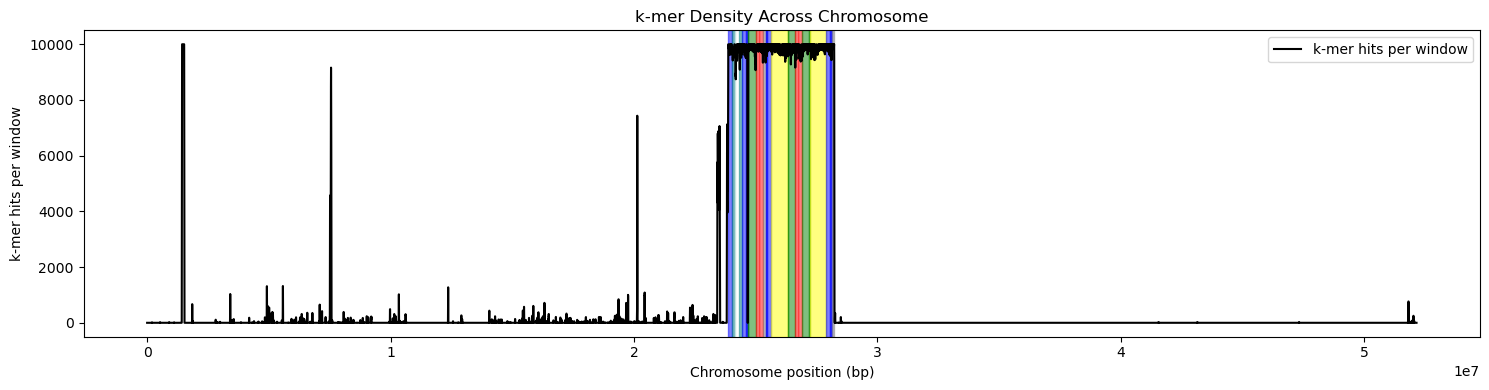

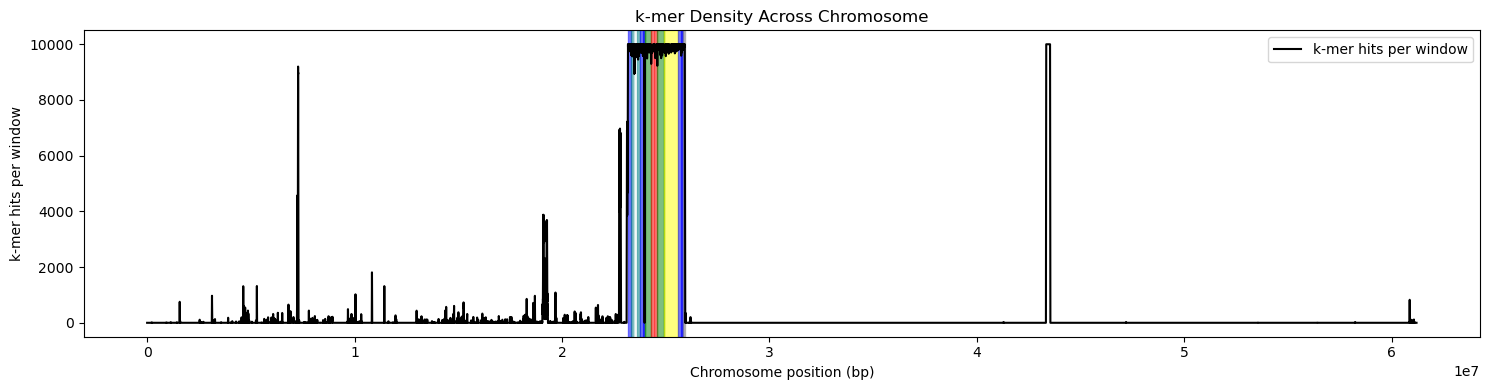

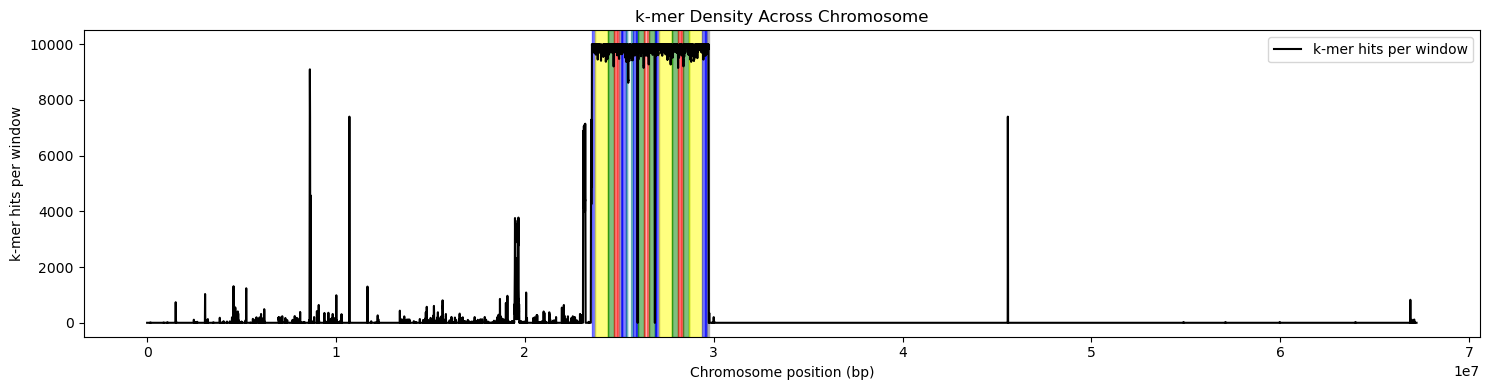

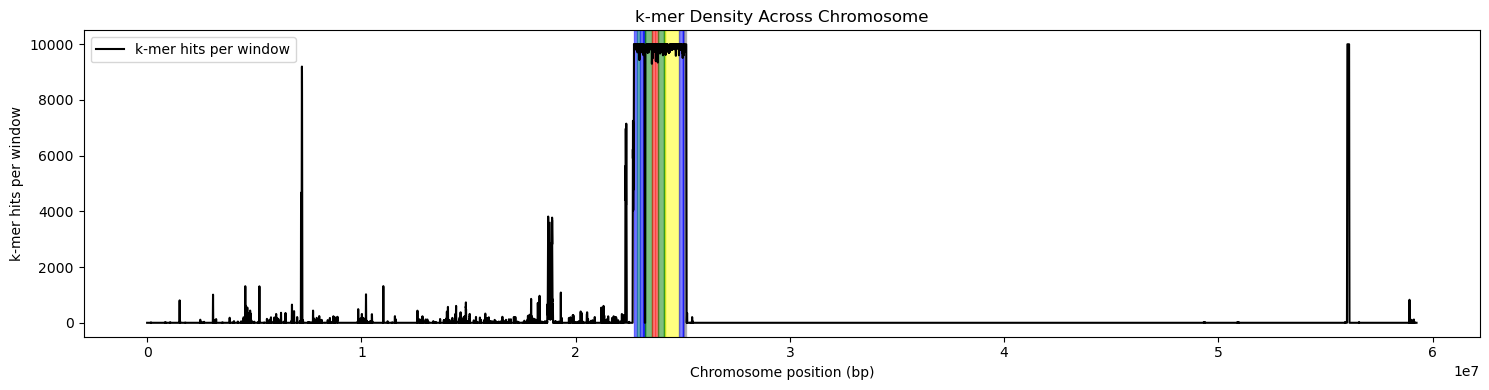

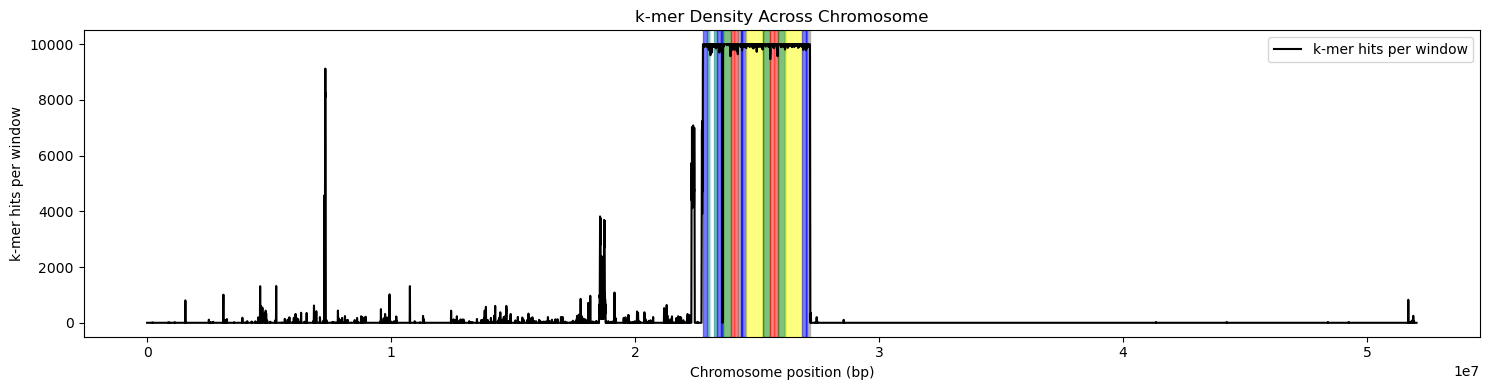

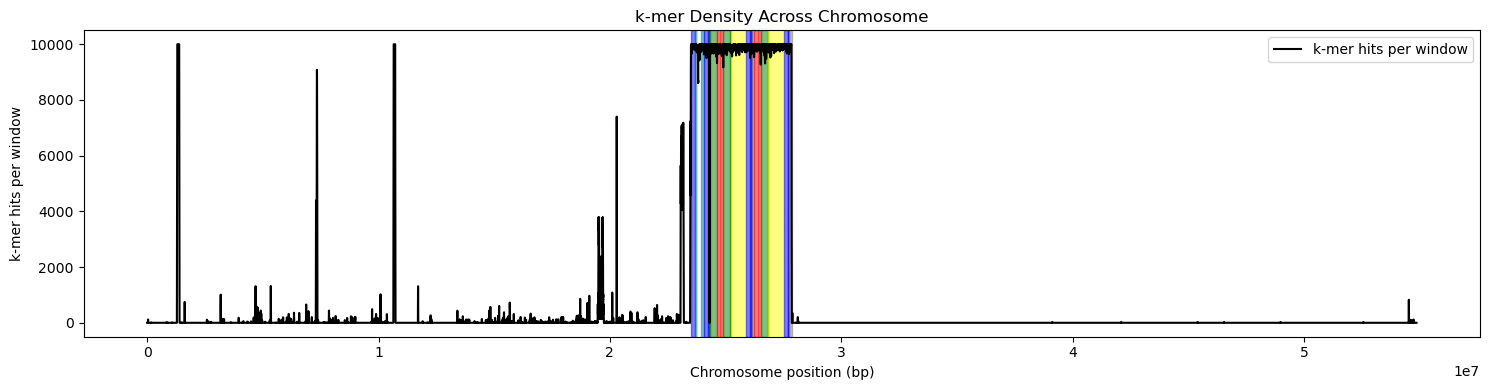

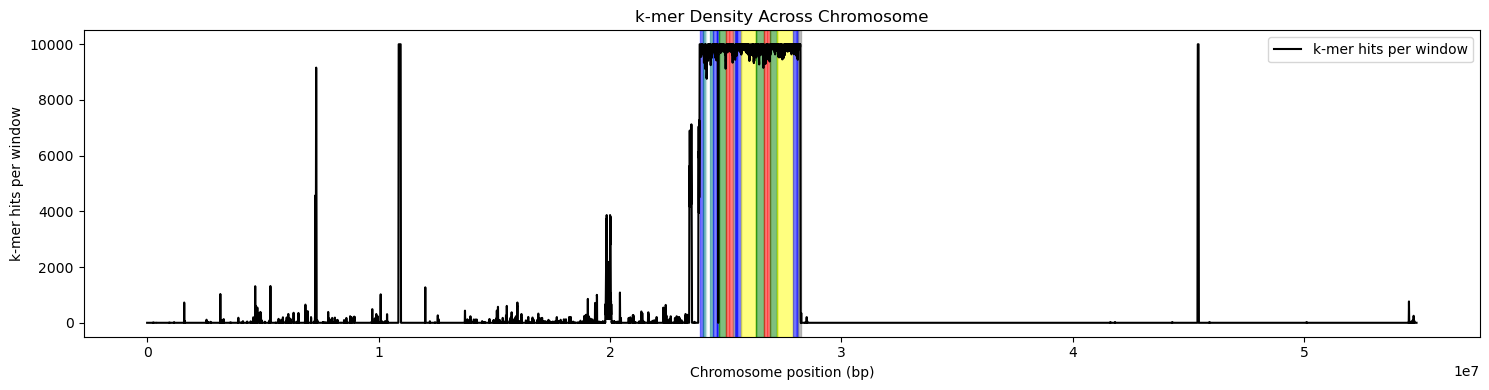

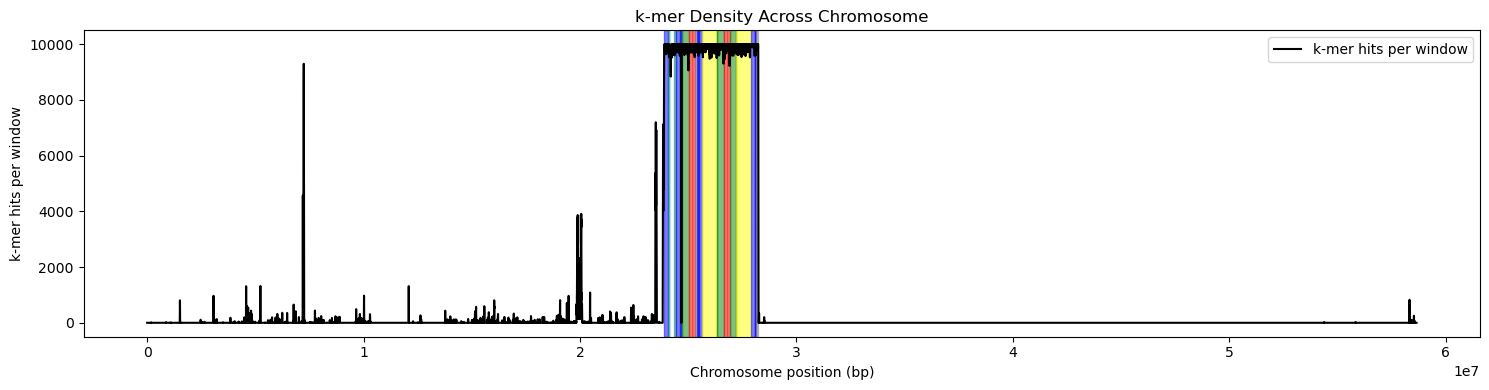

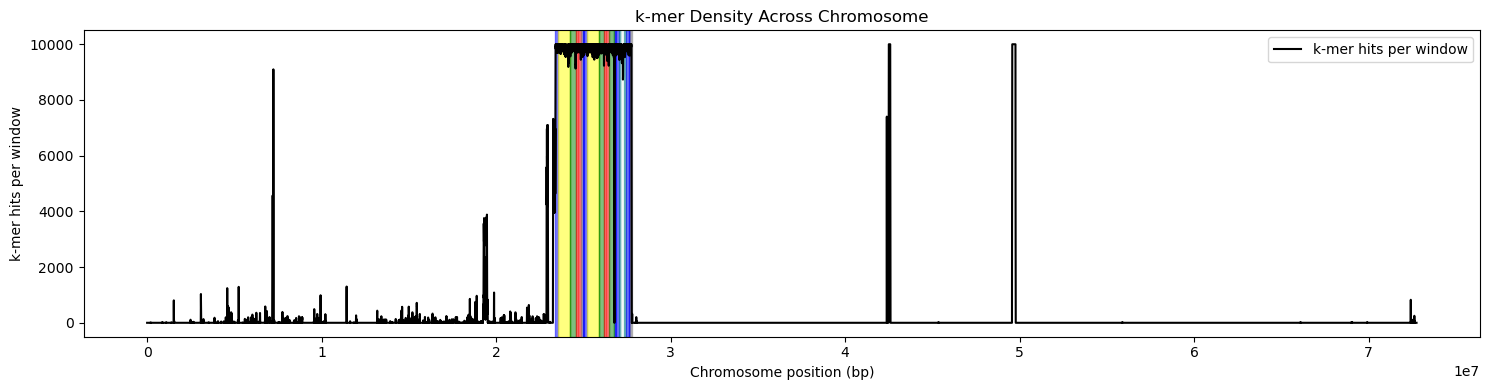

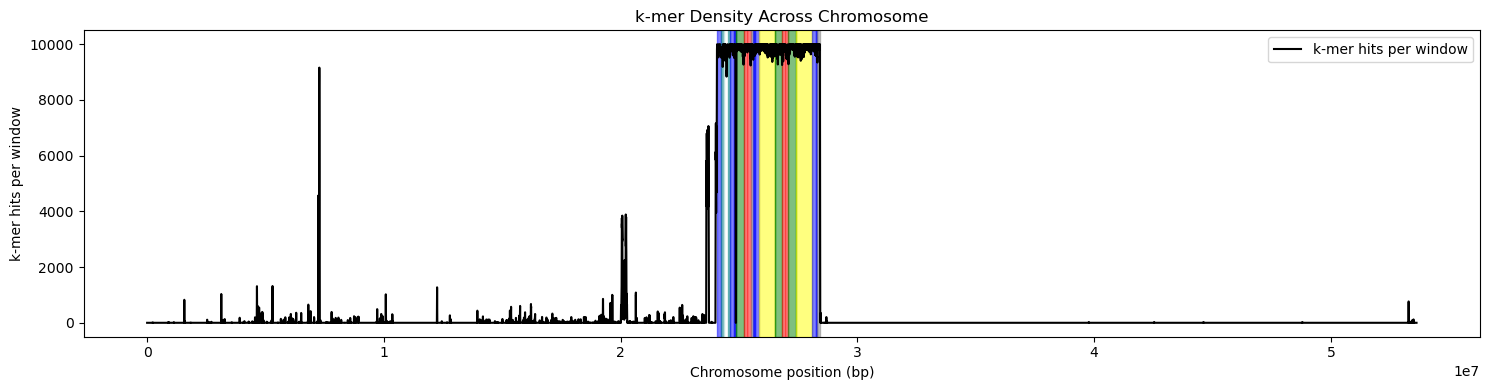

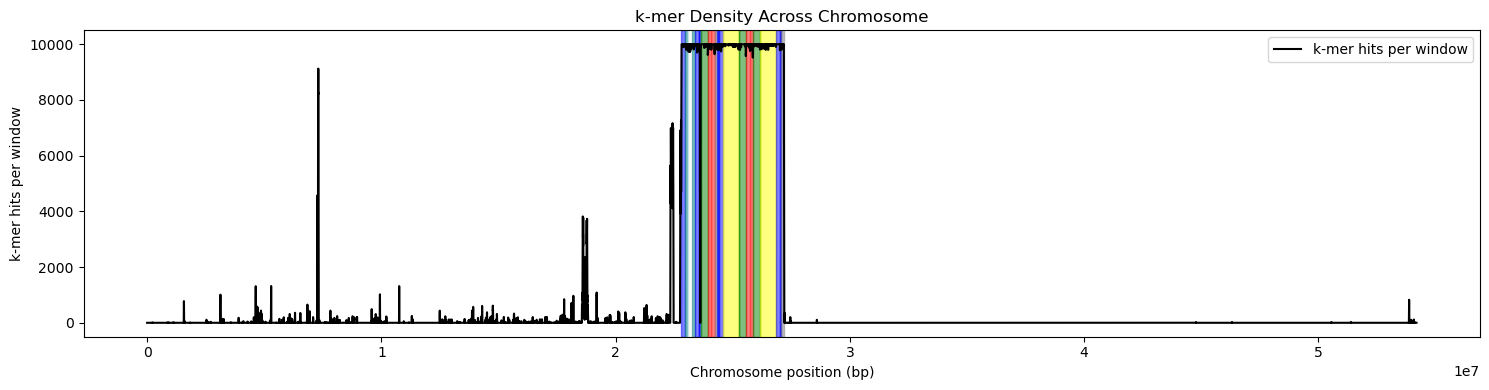

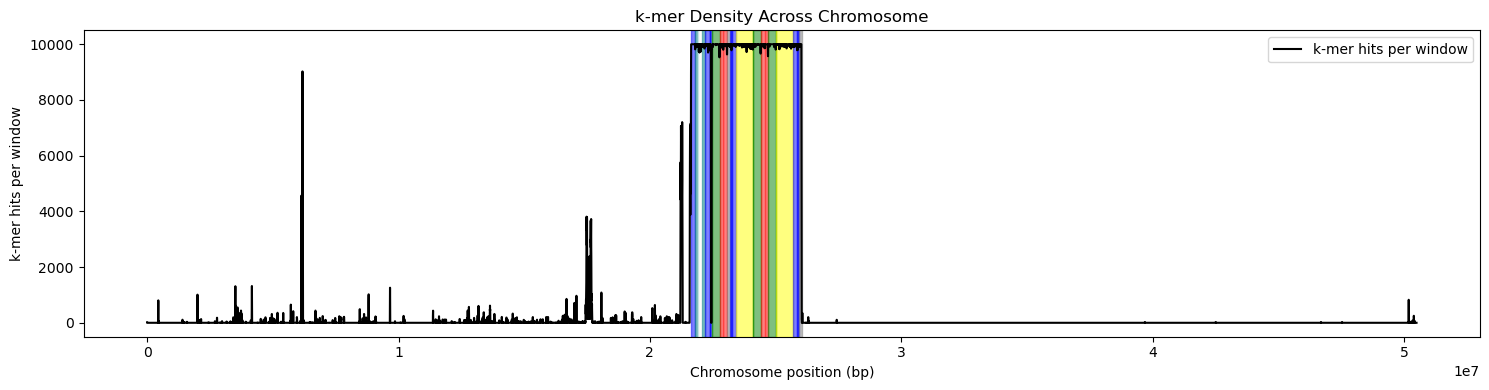

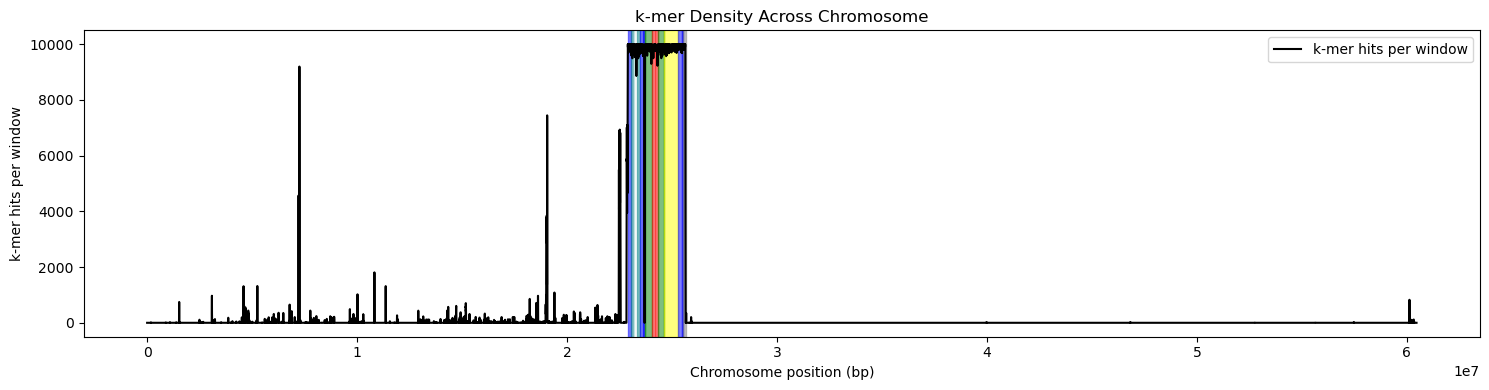

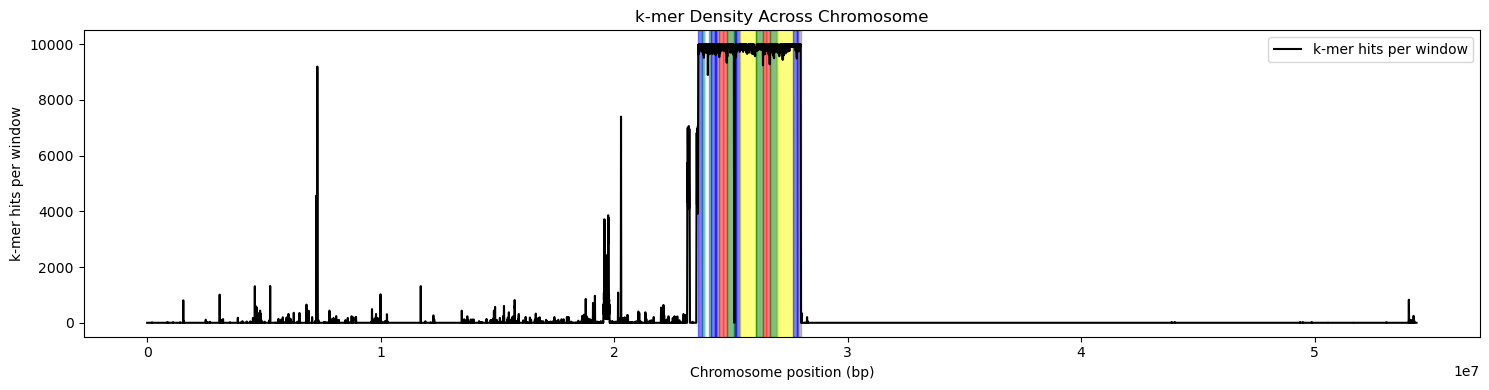

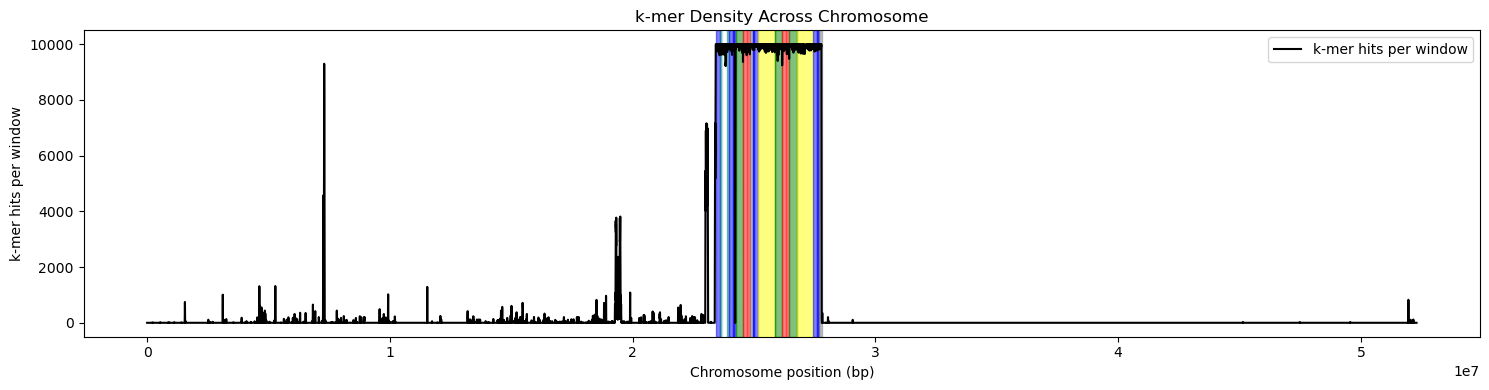

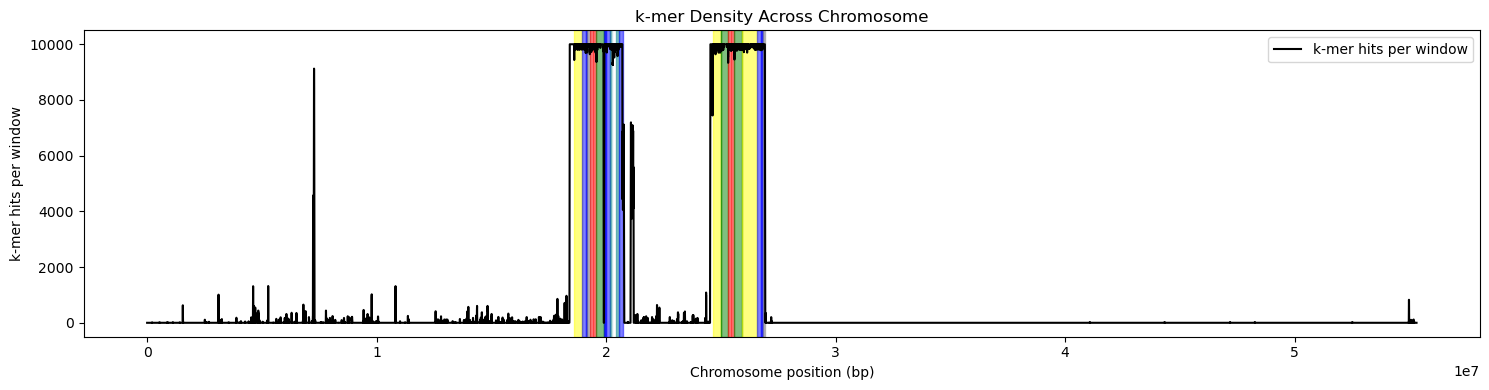

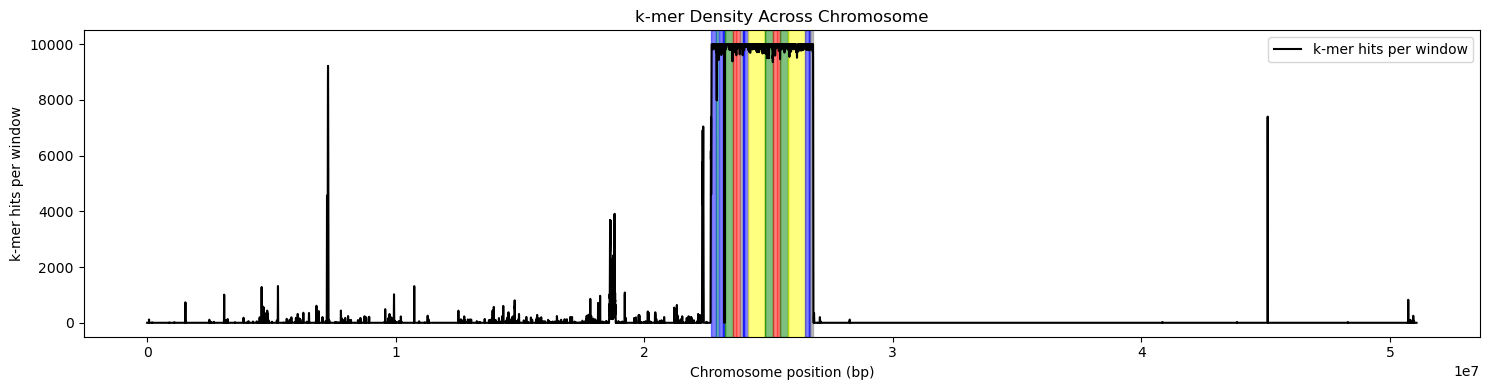

In [40]:
import gzip
from Bio import SeqIO
import os
from tqdm import tqdm

SamplesWithGaps=[]
for sample in tqdm(os.listdir('/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/')):
    if sample.startswith('.') or '.fai' in sample or '.gzi' in sample:
        continue
    else:
        sampleName = str(sample.split("_")[0])

        #For each sample do each haplotype
        with gzip.open('/LeeLab/Assemblies/HPRC_Release2/chrY_assemblies/'+str(sample), "rt") as handle:
            for record in SeqIO.parse(handle, "fasta"):
                if 'random' in record.id:
                    continue
                else:
    
                    haplotype = str(record.id)
                    chrom_seq = str(record.seq)  
                    kmer_dict = Colorkmers
                    k = 100
                    
                    # Run it
                    raw_assignments = assign_regions(chrom_seq, kmer_dict, k, haplotype)
                    
                    density = count_density(assignments=raw_assignments, chrom_len=len(str(record.seq)))
                    high_regions = find_high_density_regions(raw_assignments, len(str(record.seq)), threshold=8000)
                    merged_Highcoords = merge_close_intervals(high_regions)
                    merged_assignments = merge_regions(raw_assignments)
                    
                    myBed1 = pd.DataFrame(data=merged_assignments)
                    mask = pd.Series(False, index=myBed1.index)
                    for coord_start, coord_end in merged_Highcoords:
                        mask |= (myBed1[0] >= coord_start) & (myBed1[1] <= coord_end)
                    
                    myBed2 = myBed1[mask].copy()

                    if 'random' in haplotype or sampleName == 'NA20905':
                        myBed = myBed2.copy()
                    else:
                        myBed = myBed2[myBed2[0]>=10000000].copy()
                    
                    myBed['Color']='many'
                    for row in myBed.index:
                    
                        if 'plus' in str(myBed.at[row,2]) or 'IR1' in str(myBed.at[row,2]):
                            myColors1 = list(set([x for x in myBed.at[row,2].split("_")]))
                            myColors=[]
                            for color in myColors1:
                                if 'bIR1' in color:
                                    myColors.append('bIR1')
                    
                                elif 'gIR1' in color:
                                    myColors.append('gIR1')
                                    
                                elif 'plus' in color:
                                    myColors.append("plus")
                                else:
                                    myColors.append(color[:-1])
                        else:
                            myColors = list(set([x[:-1] for x in myBed.at[row,2].split("_")]))
                    
                        if len(myColors)==1:
                            
                            myBed.at[row,'Color']=myColors[0]
                            
                        else:
                            continue

                    groupDict={}
                    groupNumber=1
                    flag=0
                    tempList=[]
                    for row in myBed.index:
                    
                        if flag==0:
                            groupColor = myBed.at[row,'Color']
                            tempList.append([myBed.at[row,0], myBed.at[row,1], myBed.at[row,2], myBed.at[row,'Color']])
                            flag=1
                    
                        else:
                            
                            if myBed.at[row,'Color'] == groupColor:
                                tempList.append([myBed.at[row,0], myBed.at[row,1], myBed.at[row,2], myBed.at[row,'Color']])
                                
                            elif myBed.at[row,'Color'] == 'many' and groupColor in myBed.at[row,2]:
                    
                                if 'plus' in groupColor or 'IR1' in groupColor:
                                    tempList.append([myBed.at[row,0], myBed.at[row,1], myBed.at[row,2], myBed.at[row,'Color']])
                                
                                else:
                                    
                                    flag2 =0
                                    for element in list(myBed.at[row,2].split("_")):
                                        if groupColor in element and 'plus' not in element and 'IR1' not in element:
                                            flag2+=1
                                        else:
                                            continue 
                    
                                    if flag2>0:
                                        tempList.append([myBed.at[row,0], myBed.at[row,1], myBed.at[row,2], myBed.at[row,'Color']])
                                    else:
                                        groupDict[groupColor+"_"+str(groupNumber)]=tempList
                                        tempList=[]
                                        groupNumber+=1
                                        tempList.append([myBed.at[row,0], myBed.at[row,1], myBed.at[row,2], myBed.at[row,'Color']])
                                        groupColor = myBed.at[row,'Color']
                                
                            else:
                                groupDict[groupColor+"_"+str(groupNumber)]=tempList
                                tempList=[]
                                groupNumber+=1
                                tempList.append([myBed.at[row,0], myBed.at[row,1], myBed.at[row,2], myBed.at[row,'Color']])
                                groupColor = myBed.at[row,'Color']
                    
                    if len(tempList)>0:
                        groupDict[groupColor+"_"+str(groupNumber)]=tempList
                    else:
                        pass
                    
                    newList2=[]
                    for key in groupDict.keys():
                        groupTempDF = pd.DataFrame(data=groupDict[key])
                        length= max(groupTempDF[1]) - min(groupTempDF[0])

                        if length <2000 and key.split("_")[0]!='spacer':
                            continue
                    
                        elif length <200 and key.split("_")[0]=='spacer':
                            continue
                        else:
                            for entry in groupDict[key]:
                                newList2.append(entry)
                    
                    myBed2 = pd.DataFrame(data=newList2)
                    
                    groupDict2={}
                    groupNumber=1
                    flag=0
                    tempList=[]
                    for row in myBed2.index:
                    
                        if flag==0:
                    
                            if myBed2.at[row,3] == 'many':
                    
                                #try to figure out what color it should be
                                ProfileDictTemp = {'bIR1':0,'blue':0,'gIR1':0,'gray':0,'green':0,'plus':0,'red':0,'spacer':0,'teal':0,'yellow':0}       
                                for colorelement in myBed2.at[row,2].split("_"):
                                    if 'IR1' in colorelement:
                                        ProfileDictTemp[colorelement.split("-")[1]]+=1
                    
                                    elif 'plus' in colorelement:
                                        ProfileDictTemp['plus']+=1
                    
                                    elif 'spacer' in colorelement:
                                        ProfileDictTemp['spacer']+=1
                    
                                    else:
                                        ProfileDictTemp[colorelement[:-1]]+=1
                                        
                                myChosenGroup = max(ProfileDictTemp, key=ProfileDictTemp.get)
                                groupColor = myChosenGroup
                            else:
                                groupColor = myBed2.at[row,3]   
                    
                            previousKmerEnd = int(myBed2.at[row,1])
                            tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                            flag=1
                    
                        else:
                    
                            if myBed2.at[row,3] == groupColor and (int(myBed2.at[row,0])-previousKmerEnd)<100000:
                                tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                                previousKmerEnd = int(myBed2.at[row,1])
                    
                            
                            elif myBed2.at[row,3] == 'many' and groupColor in myBed2.at[row,2] and (int(myBed2.at[row,0])-previousKmerEnd)<100000:
                    
                                if 'plus' in groupColor or 'IR1' in groupColor:
                                    tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                                    previousKmerEnd = int(myBed2.at[row,1])
                                
                                else:
                                    
                                    flag2 =0
                                    plusKeepTrack=[]
                                    InvRepeKeepTrack=[]
                                    for element in list(myBed2.at[row,2].split("_")):
                                        if groupColor in element and 'plus' not in element and 'IR1' not in element:
                                            flag2+=1
                                        else:
                                            if 'plus' in element:
                                                plusKeepTrack.append(element)
                                            else:
                                                InvRepeKeepTrack.append(element)
                                             
                                    if flag2>0:
                                        tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                                        previousKmerEnd = int(myBed2.at[row,1])
                    
                                    else:
                                        groupDict2[groupColor+"_"+str(groupNumber)]=tempList
                                        tempList=[]
                                        groupNumber+=1
                                        previousKmerEnd = int(myBed2.at[row,1])
                                        tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                    
                                        if len(plusKeepTrack)>len(InvRepeKeepTrack):
                                            groupColor = 'plus'
                                            
                                        else:
                                            myInvertedRepeats = collections.Counter([x.split("-")[1] for x in InvRepeKeepTrack])
                                            groupColor = max(myInvertedRepeats, key=myInvertedRepeats.get)
                    
                    
                            else:
                    
                                if myBed2.at[row,3] == 'many':
                                    
                                    groupDict2[groupColor+"_"+str(groupNumber)]=tempList
                                    tempList=[]
                                    groupNumber+=1
                                    tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                                    previousKmerEnd = int(myBed2.at[row,1])
                    
                                    ProfileDictTemp = {'bIR1':0,'blue':0,'gIR1':0,'gray':0,'green':0,'plus':0,'red':0,'spacer':0,'teal':0,'yellow':0}
                                    for colorelement in myBed2.at[row,2].split("_"):
                                        if 'IR1' in colorelement:
                                            ProfileDictTemp[colorelement.split("-")[1]]+=1
                    
                                        elif 'plus' in colorelement:
                                            ProfileDictTemp['plus']+=1
                    
                                        elif 'spacer' in colorelement:
                                            ProfileDictTemp['spacer']+=1
                    
                                        else:
                                            ProfileDictTemp[colorelement[:-1]]+=1
                                    
                                    groupColor = max(ProfileDictTemp, key=ProfileDictTemp.get)
                    
                                else:
                                    groupDict2[groupColor+"_"+str(groupNumber)]=tempList
                                    tempList=[]
                                    groupNumber+=1
                                    previousKmerEnd = int(myBed2.at[row,1])
                                    tempList.append([myBed2.at[row,0], myBed2.at[row,1], myBed2.at[row,2], myBed2.at[row,3]])
                                    groupColor = myBed2.at[row,3]
                    
                    if len(tempList)>0:
                        groupDict2[groupColor+"_"+str(groupNumber)]=tempList
                    else:
                        pass


                    preFinalGroupDict={}
                    grpnum=1
                    for group in groupDict2.keys():

                        temporaryDF = pd.DataFrame(data=groupDict2[group])
                        preuniqueList=[]
                        for x in set(temporaryDF[2]):
                            for unique in x.split("_"):
                                if group.split("_")[0] in unique:
                                    preuniqueList.append(unique)
                        uniqueList = list(set(preuniqueList))   
                        premygradingList={x:{y:0 for y in range(min(temporaryDF[0]), max(temporaryDF[1]))} for x in uniqueList}
                        premygradingListUnique={x:{y:0 for y in range(min(temporaryDF[0]), max(temporaryDF[1]))} for x in uniqueList}
                        
                        totalGroupLength = max(temporaryDF[1]) - min(temporaryDF[0])
                    
                        for entry in groupDict2[group]:
                            if len(entry[2].split("_"))==1:
                                for color in entry[2].split("_"):
                                    if group.split("_")[0] in color:
                                        for number in range(int(entry[0]), int(entry[1])):
                                            premygradingList[color][number]=1
                                            premygradingListUnique[color][number]=1
                            else:
                                for color in entry[2].split("_"):
                                    if group.split("_")[0] in color:
                                        for number in range(int(entry[0]), int(entry[1])):
                                            premygradingList[color][number]=1
                    
                        mygradingList = {}
                        mygradingListUnique ={}
                        for color in premygradingListUnique.keys():
                            mygradingList[color] =  sum(premygradingList[color].values())
                            mygradingListUnique[color] = sum(premygradingListUnique[color].values())

                        maxKey = max(mygradingList, key=mygradingList.get)
                        maxKeyUnique = max(mygradingListUnique, key=mygradingListUnique.get)
                        valueDict = collections.Counter(list(mygradingList.values()))
                    
                        if len(mygradingList)>1:
                            temporaryDict2 = dict(mygradingList.copy())
                            temporaryDict2.pop(maxKey)
                            SecondPlaceKey = max(temporaryDict2, key=temporaryDict2.get)
                            preFinalGroupDict[grpnum]={'ID':maxKey, 'UniqueLengthMaxID':maxKeyUnique, 'TotalAnnotatedLength':totalGroupLength, 'RegionLengthAnnotations':mygradingList, 'RegionLengthAnnotationsUnique':mygradingListUnique, 'coordinates':groupDict2[group], 'FirstPlaceLength':mygradingList[maxKey], 'SecondPlace':SecondPlaceKey, 'SecondPlaceLength':temporaryDict2[SecondPlaceKey]}
                            grpnum+=1  
                        else:
                            preFinalGroupDict[grpnum]={'ID':maxKey,'UniqueLengthMaxID':maxKeyUnique, 'TotalAnnotatedLength':totalGroupLength,'RegionLengthAnnotations':mygradingList, 'RegionLengthAnnotationsUnique':mygradingListUnique, 'coordinates':groupDict2[group], 'FirstPlaceLength':mygradingList[maxKey], 'SecondPlace':'NONE', 'SecondPlaceLength':'NONE'}
                            grpnum+=1    

                    FinalGroupDict = preFinalGroupDict.copy()

                    FinalSampleColorRegionList=[]
                    for x in FinalGroupDict:
                        tempDF = pd.DataFrame(data=FinalGroupDict[x]['coordinates'])
                        lengthDict = FinalGroupDict[x]['RegionLengthAnnotations']
                        uniqueLengthDict = FinalGroupDict[x]['RegionLengthAnnotationsUnique']
                    
                        groupLength = lengthDict[FinalGroupDict[x]['ID']]
                        uniqueLengthMaxID = FinalGroupDict[x]['UniqueLengthMaxID']
                        totalLength = FinalGroupDict[x]['TotalAnnotatedLength']
                        
                        FinalSampleColorRegionList.append([FinalGroupDict[x]['ID'],uniqueLengthMaxID, groupLength/totalLength, totalLength, record.id, min(tempDF[0]), max(tempDF[1]), FinalGroupDict[x]['RegionLengthAnnotations'],FinalGroupDict[x]['RegionLengthAnnotationsUnique'], FinalGroupDict[x]['coordinates']])
                    
                    FinalSampleColorRegionDF1 = pd.DataFrame(data=FinalSampleColorRegionList, columns=['Pipeline_Annotation','UniqueLengthMaxID', 'PercentLength','ColorBlockRegionLength','Haplotype','StartCoordinate','EndCoordinate','KmerProfileHitsLength', 'UniqueKmerProfileHitsLength', 'IndividualKmerBlockHitCoordinates'])
                    for row in FinalSampleColorRegionDF1.index:
                        if FinalSampleColorRegionDF1.at[row,'Pipeline_Annotation']=='NGAP1':
                            SamplesWithGaps.append([sampleName, FinalSampleColorRegionDF1.at[row,'ColorBlockRegionLength'], FinalSampleColorRegionDF1.at[row,'StartCoordinate'], FinalSampleColorRegionDF1.at[row,'EndCoordinate']])
                        else:
                            continue
                    
                    FinalSampleColorRegionDF = FinalSampleColorRegionDF1[(FinalSampleColorRegionDF1['PercentLength']>.50) & (FinalSampleColorRegionDF1['Pipeline_Annotation']!='NGAP1')].copy()
                    FinalSampleColorRegionDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/ColorBlockDataframes/allInfo/"+str(sampleName)+"_"+str(haplotype)+"_"+str(haplogroups[sampleName])+"_ColorBlockRegions.pipeline.csv")
                    FinalSampleColorRegionDF[['Pipeline_Annotation','UniqueLengthMaxID', 'PercentLength','ColorBlockRegionLength','Haplotype','StartCoordinate','EndCoordinate','KmerProfileHitsLength','UniqueKmerProfileHitsLength']].to_csv("/LeeLab/HPRC/chromosomeY/Data/ColorBlockDataframes/lessInfo/"+str(sampleName)+"_"+str(haplotype)+"_"+str(haplogroups[sampleName])+"_ColorBlockRegions.lessInfo.pipeline.csv")
                    plot_HighlightedBlocks(haplogroups, FinalSampleColorRegionDF, sampleName, haplotype, density, high_regions, chrom_len=len(str(record.seq)))

In [41]:
badSampleDF = pd.DataFrame(data=SamplesWithGaps)
badSampleDF

,0,1,2,3
0,HG01109,200000,44130276,44330276
1,HG03942,7500,26841737,26849237
2,HG03942,200000,38550624,38750624
3,HG00280,7500,23672368,23679868
4,HG00280,41778,24126123,24167901
...,...,...,...,...
143,NA18612,100000,42497304,42597304
144,NA18612,200000,49575654,49775654
145,HG02602,200000,18412923,18612923
146,HG02602,100000,24539187,24639187


In [45]:
#badSampleDF.to_csv("/LeeLab/HPRC/chromosomeY/Data/Assemblies_wGaps_InColorRegions.csv")

In [43]:
len(set(badSampleDF[0]))

65

In [44]:
min(badSampleDF[1])

7500